# Engenharia de Características para a Aprendizagem Computacional
## Trabalho Prático 1
Trabalho realizado por:
- Beatriz Fernandes 2023215703
- Bernardo Mendes 2023195718
- Diana Martins 2023218119

### Dataset
O Dataset utilizado é o FORTH-TRACE benchmark. O mesmo contém dados recolhidos de 5 sensores, incluindo sensores de aceleração, velocidade angular e variação do campo magnético, quer da parte superior, quer da parte inferior, do corpo.

### Bibliotecas Utilizadas

In [25]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
import numpy as np
from scipy.stats import kstest, shapiro, f_oneway, kruskal
from scipy import stats
from scipy.integrate import cumulative_trapezoid
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skrebate import ReliefF
from skfeature.function.similarity_based import fisher_score


### Exercício 2
#### 1. Carregamento dos dados
Os dados foram carregados a partir dos ficheiros CSV disponibilizados no dataset. À medida que os dados foram sendo adicionados a um array auxiliar, foi também adicionada uma coluna com o ID do participante, de forma a manter essa informação para os passos seguintes.

In [2]:
def load_data():
    dataset_root='../FORTH_TRACE_DATASET'
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    # add participant ID
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)

    return data


#fiz isto só p ver como estavam os dados
data= load_data()
print(data[:5])  


[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]


### Exercício 3
Análise e tratamento de outliers: o objetivo será identificar e tratar outliers usando diferentes abordagens univariável e multivariável. Para o efeito iremos utilizar os módulos dos vectores aceleração, giroscópio e magnetómetro. Seja
$$ \vec{t} = (tx, ty, tz) $$
o vector aceleração, giroscópio e magnetómetro. O respetivo módulo é determinado recorrendo:
$$ ||\vec{t}|| = \sqrt{tx^2 + ty^2 + tz^2} $$

### Exercício 3.1
Elabore uma rotina que apresente simultaneamente o boxplot de cada atividade (coluna 12 – eixo horizontal) relativo a todos os sujeitos e a uma das seguintes variáveis transformadas: módulos dos vectores de aceleração, giroscópio e magnetómetro. Sugere-se o uso da biblioteca matplotlib, por exemplo, a classe matplotlib.pyplot.boxplot.

In [13]:
def module_boxplots(data, sensor):
    if sensor == 1:
        c = (2,3,4)
        label = 'Acceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2, or 3")
    
    # módulo = sqrt(x^2 + y^2 + z^2)
    mod = np.sqrt((data[:, c] ** 2).sum(axis=1))
    
    #extrai as informações 
    device = data[:, 1].astype(int)
    activities = data[:, 12].astype(int)
    unique_activities = np.unique(activities)
    unique_devices = np.unique(device)
    
    # Cria um gráfico por dispositivo
    for dev in unique_devices:
        plt.figure(figsize=(10, 5))
        boxplot_data = []
        
        # Para cada atividade, vê os módulos correspondentes a este dispositivo
        for act in unique_activities:
            mask = (device == dev) & (activities == act)
            mods_from_act = mod[mask]
            boxplot_data.append(mods_from_act)
        
        plt.boxplot(boxplot_data, tick_labels=[f"A{a}" for a in unique_activities], showfliers=False)
        plt.xlabel('Activity')
        plt.ylabel(f'{label} Module')
        plt.title(f'{label} Module by Activity — Device {dev}')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


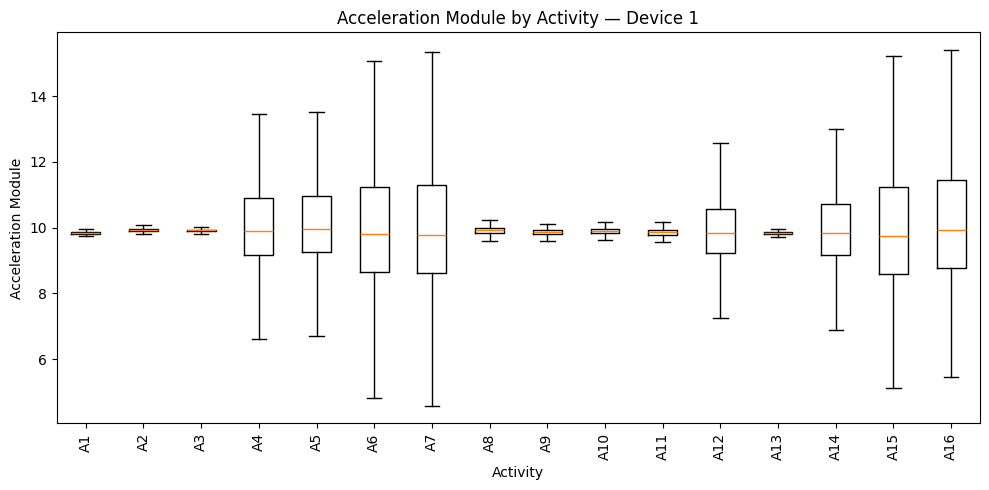

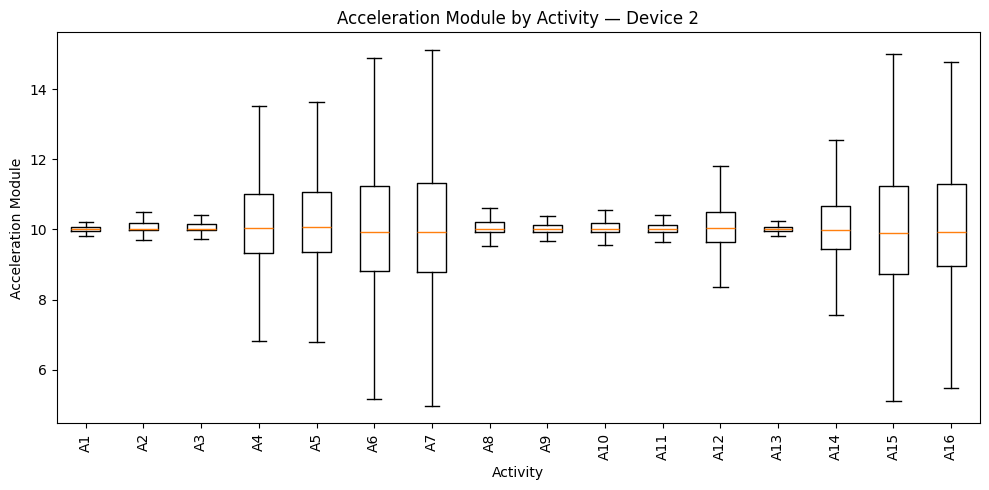

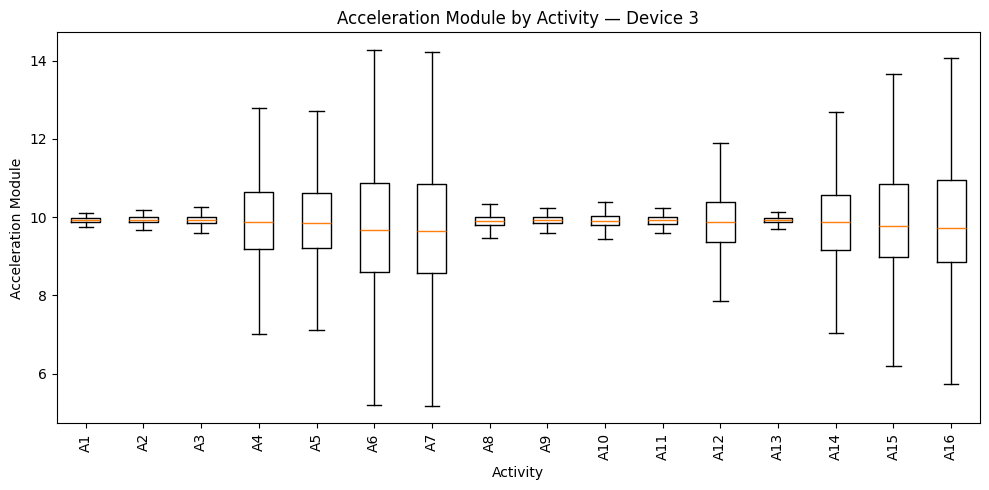

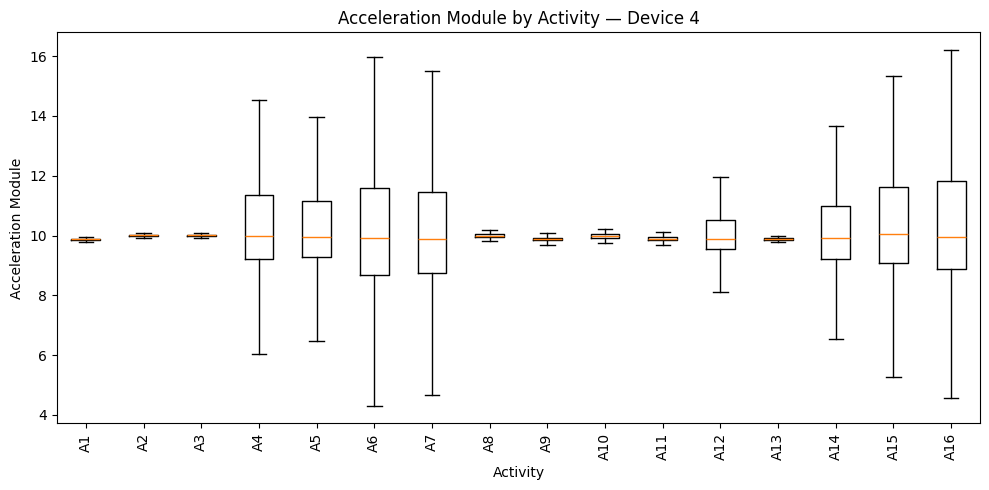

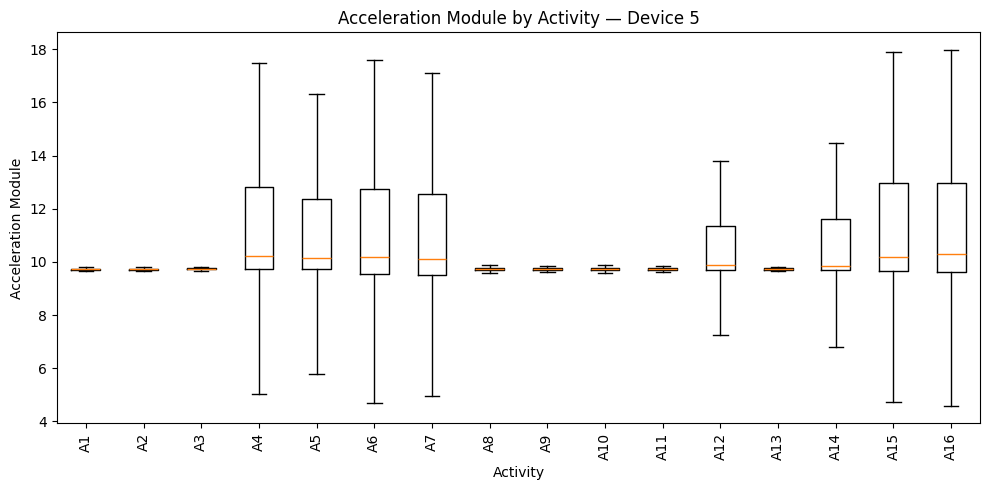

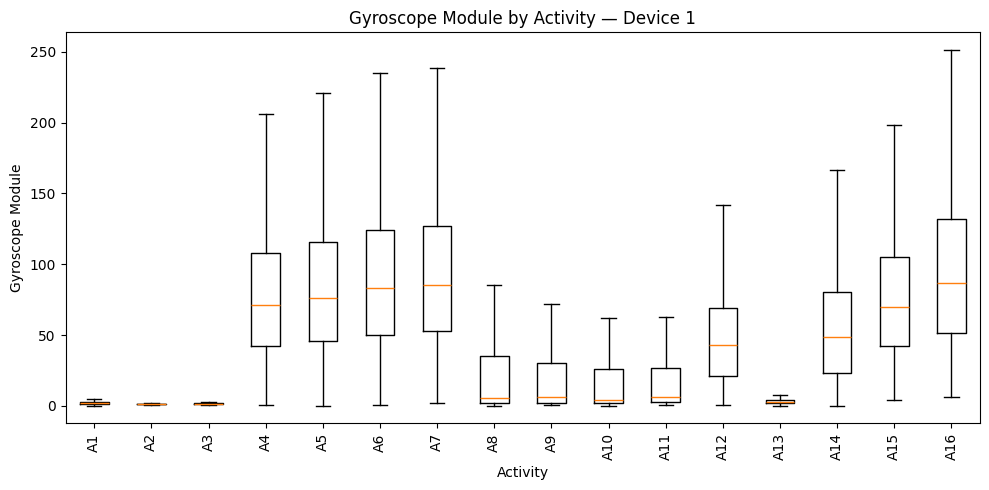

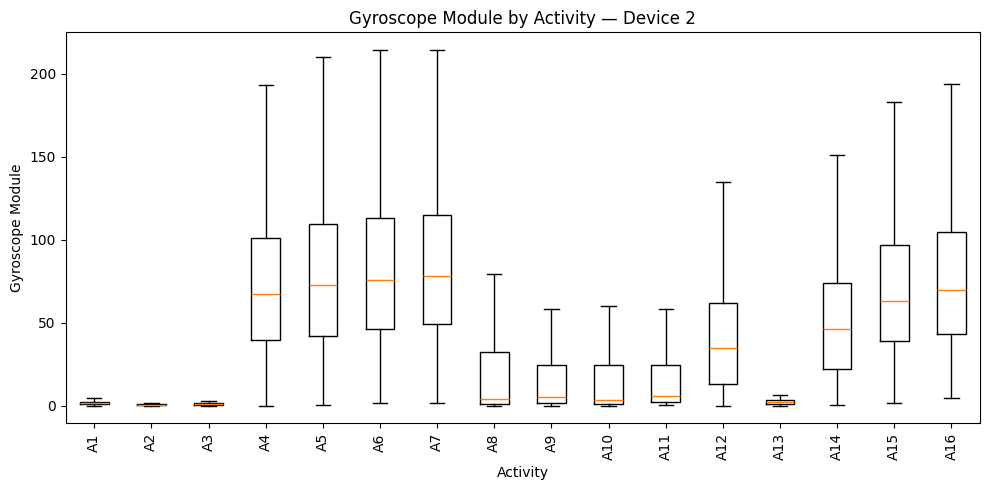

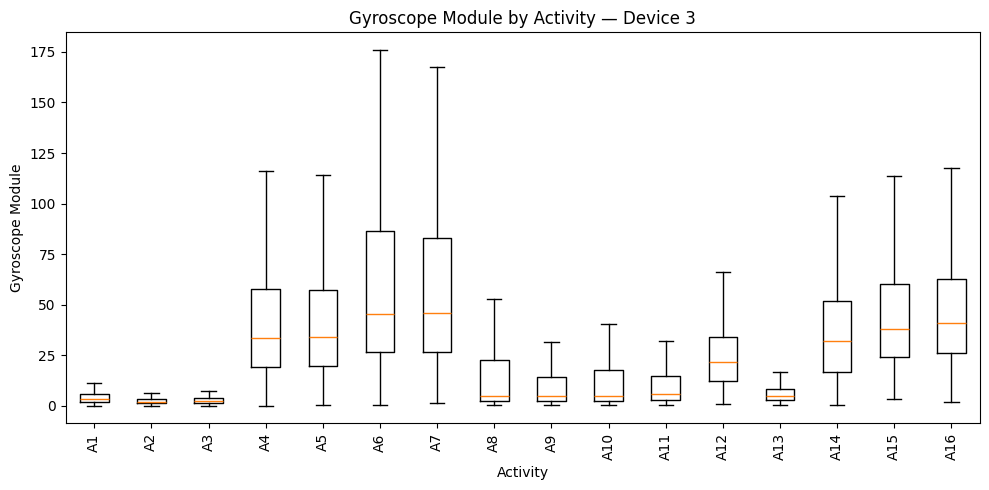

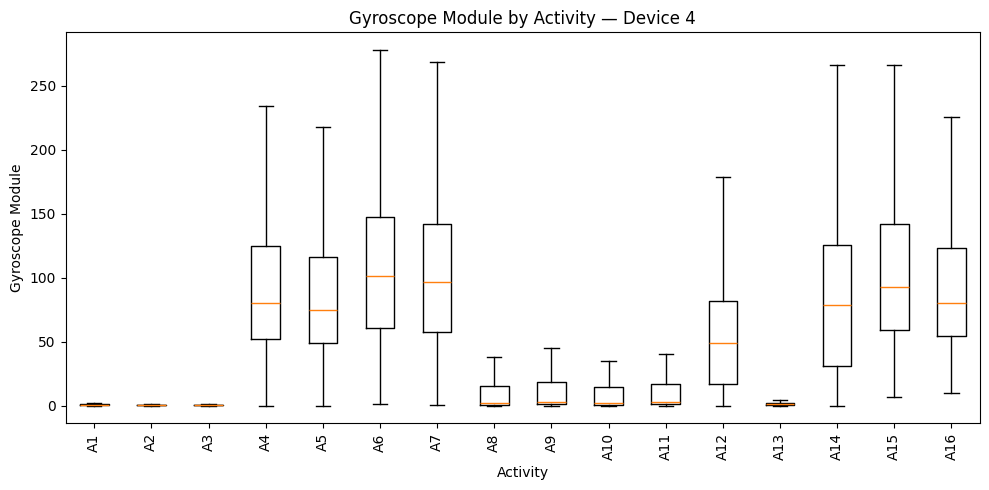

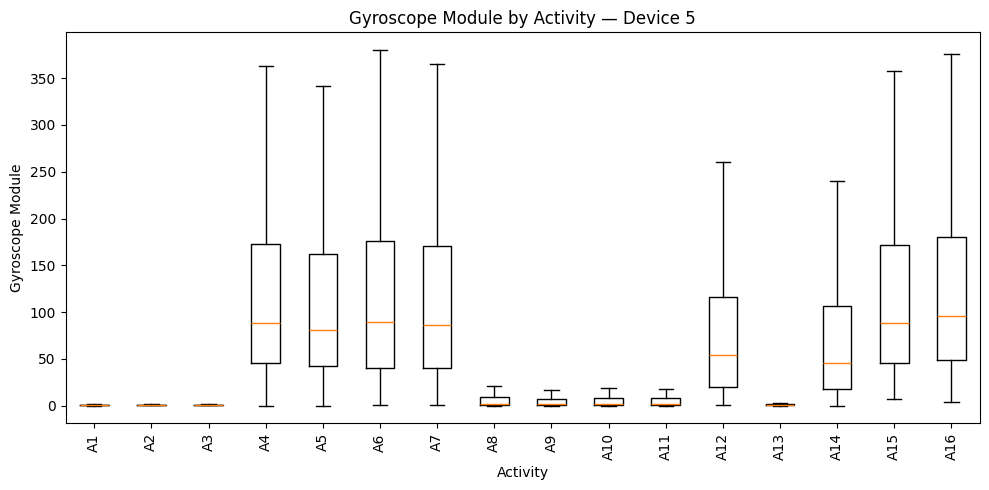

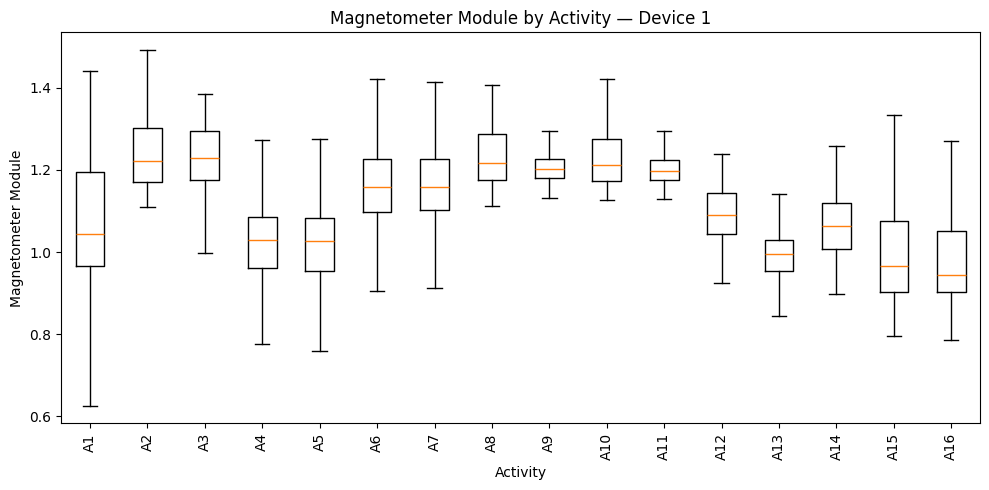

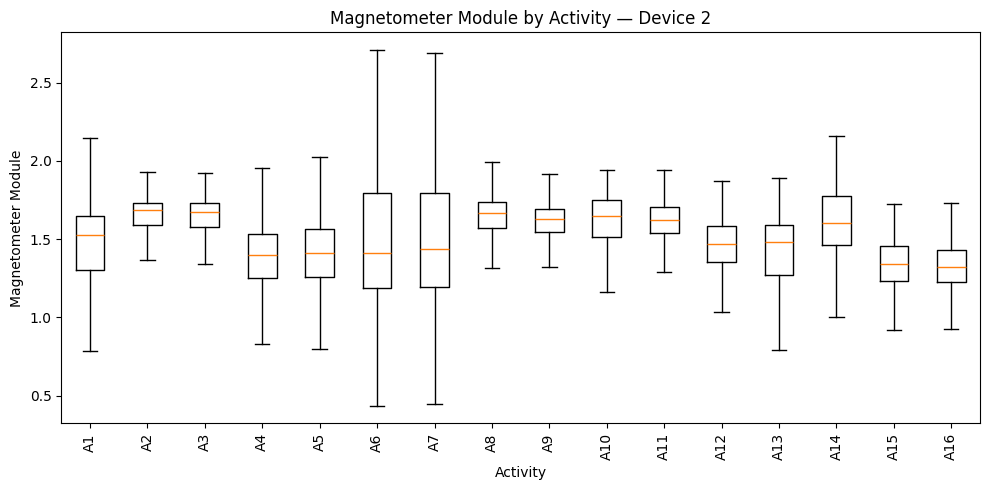

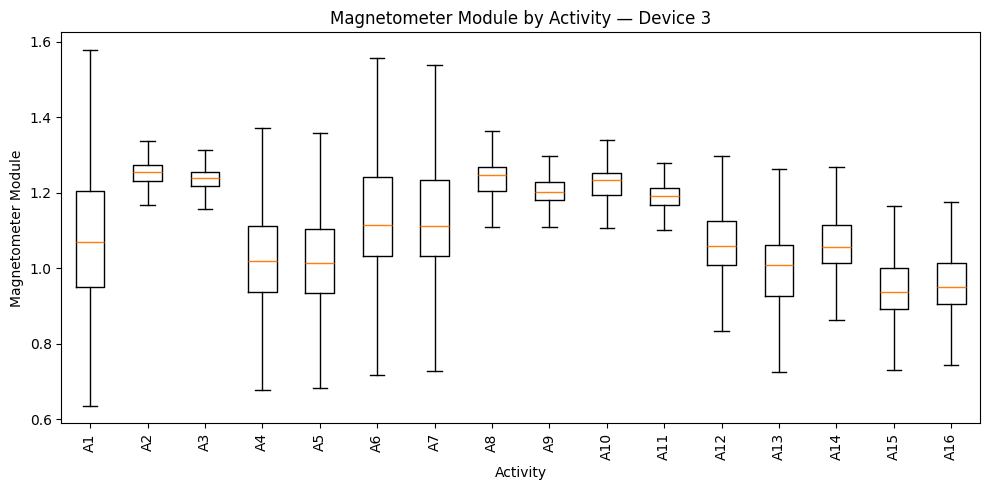

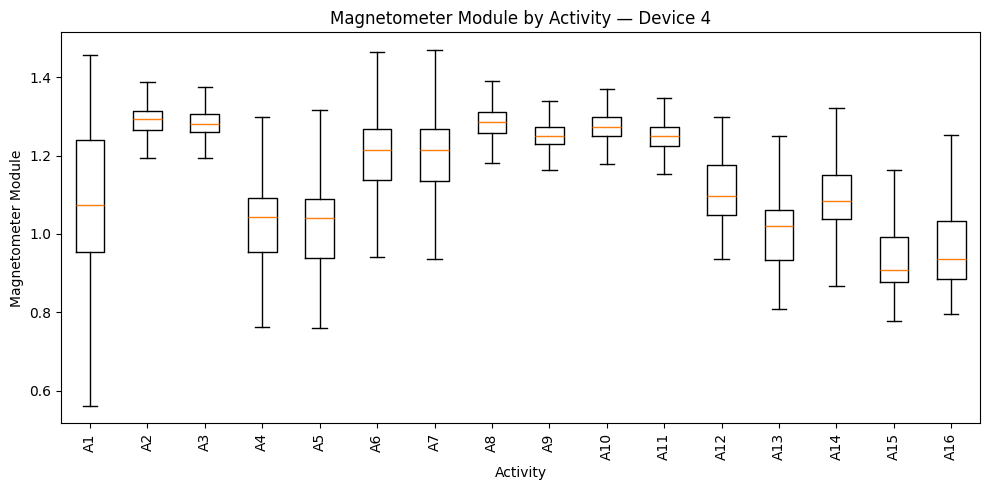

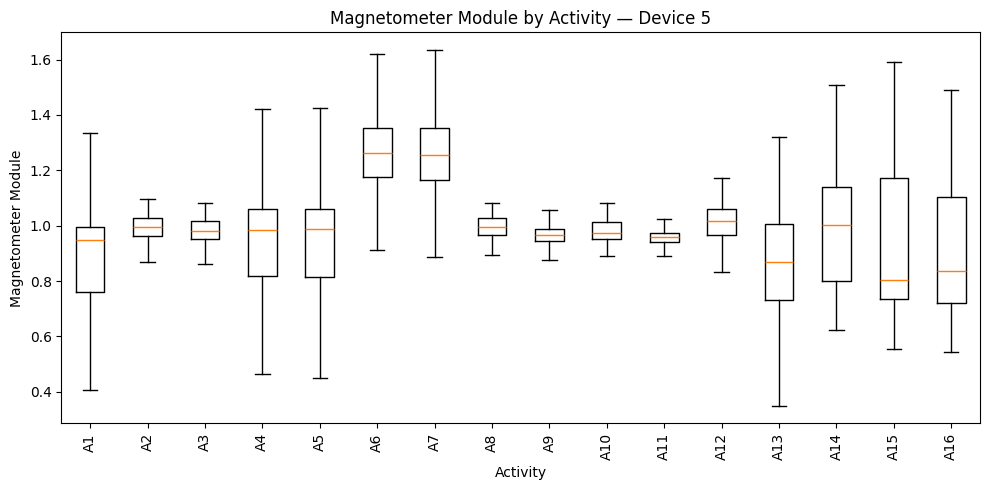

In [14]:
module_boxplots(data, 1)
module_boxplots(data, 2)
module_boxplots(data, 3)

  ## Observações:
  ### Geral:
  Existe uma grande presença de outliers em todos os sensores, o que é visível em praticamente todas as atividades. Sugere que os movimentos humanos contêm variações extremas? É necessário aprofundar a análise para perceber se estes outliers são de facto variações extremas ou se são erros de medição.
  ### Aceleração:
  #### Módulo Aceleração:
  - As atividades estáticas (1, 2, 3) apresentam uma mediana próxima de 10, que correspondem, aproximadamente, à aceleração da gravidade (~9.81 m/s²), com uma variabilidade muito reduzida. Isto indica que o corpo está maioritariamente em repouso.
  
  - As atividades dinâmicas (4,5,6,7) apresentam maior dispersão. Isto reflete a constante variação de aceleração inerente a estas atividades.
  
  - DISPOSITIVO 1: atividades como a 1,2 e 3 mostram valores baixos, indicando ausência de movimento significativo. Por outro lado, atividades como 4, 5, 6 e 7 apresentam maior dispersão e com mais outliers refletindo a irregularidade do movimento do corpo. Destacam-se especialmente as atividades 6 e 7 por serem típicos de subir e descer escadas daí as suas amplitudes. As atividades 14 a 16 apresentam as maiores variações surgerindo maior esforço.
  
  - DISPOSITIVO 2: Padrão similar ao pulso esquerdo.
  
  - DISPOSITIVO 3: Apresenta comportamentos consistentes com o movimento do corpo. As atividades de 1 a 3 mostram baixa variabilidade o que reflete a estabilidade do corpo. Já as atividades de 4 a 7 e 14 a 16 exibem uma grande dispersão e outliers significativos, o que é esperado dado que o peito acompanha os movimentos do corpo. Em geral, este sensor consegue distinguir muito bem entre as atividades mais calmas e com mais movimento.
  
  - DISPOSITIVO 4: Atividades como a 6,7,14 e 16 mostram os maiores valores evidenciando o envolvimento da perna durante estas atividades.
  
  - DISPOSITIVO 5: Semelhante ao dispositivo anterior, este sensor evidencia grande sensibilidade às atividades que exigem mais esforço, captando de forma eficaz a aceleração associada ao movimento das pernas.
  #### Conclusão:
  - Os resultados são os esperados. O módulo da aceleração parece ser uma característica útil para distinguir entre atividades estáticas e dinâmicas.
  
  - A aceleração é mais pronunciada em membros em movimento (atividades 6,7,4,5,15 e 16) durante atividades dinâmicas uma vez que exigem mais esforço e variação de velocidade. O peito apresenta os valores mais estáveis e baixos, indicando ser uma região com menos variação de movimento. Já as transições são claramente identificadas pelos picos de aceleração.

  ### Giroscópio:
  #### Módulo Giroscópio:
  - Nas atividades estáticas, a mediana está praticamente a zero e a caixa é quase inexistente, indicando pouca ou nenhuma rotação. Sem movimento, não existe velocidade angular.
  
  - Nas atividades dinâmicas os valores de módulo e a dispersão são significativamente maiores, com outliers evidentes.
  
  - DISPOSITIVO 1: Atividades como a 4,5,6,7 e 14 a 16 destacam-se por apresentarem muitos outliers, o que é consistente com movimentos mais bruscos e irregulares.
  
  - DISPOSITIVO 2: Padrão similar ao pulso esquerdo, com algumas variações possivelmente relacionadas à dominância manual.
  
  - DISPOSITIVO 3: Valores moderados e é menos sensível a movimentos de extremidades. Atividades onde existe maior movimento de tronco exibem medianas mais elevadas, evidenciando o esforço do peito em ajustar o equilíbrio durante estas ações. Nota-se também a presença de outliers em várias dessas atividades o que é coerente com movimentos menos previsíveis.
  
  - DISPOSITIVO 4: valores muito baixos nas atividades 1 a 3 e medianas altas em atividades como 4 a 7 e 14 a 16. Era de esperar uma vez que regista mais movimentos nestas atividades porque a penas realiza passagens amplas e rápidas. Com isto explica os outliers e os IQR maiores nessas atividades.
  
  - DISPOSITIVO 5: Atividades de locomoção geram os maiores valores de rotação. Valores mais elevados de todos os dispositivos.

  #### Conclusão:  
  - O giroscópio apresenta a distanção mais clara entre os dois tipos de atividade.
  
  - As atividades com maior rotação destacam-se novamente com as medianas e limites superiores mais elevados.
  
  - O giroscópio é particularmente sensível a movimentos rotacionais durante transições entre posturas. Dispositivos nas pernas capturam melhor a rotação durante atividades de locomoção. Além disso, na atividade 5 e 7 (onde se observa um ligeiro aumento na rotação mediana em comparação com as atividades 4 e 6) sugere que o ato de falar possivelmente combinado com mais alguma coisa introduz uma componente rotacional ao movimento.

  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - Existe uma enorme quantidade de outliers nas atividades 6 (Climb Stair) e 7 (Climb Stair and talk). Esse fenómeno provavelmente não se deve ao movimento em si, mas sim ao facto de escadas conterem frequentemente estruturas metálicas (corrimões, vigas, etc.) que podem interferir com o sensor magnético.
  
  - DISPOSITIVO 1: Variações moderadas entre atividades, com padrões menos definidos que aceleração/giroscópio.
  
  - DISPOSITIVO 2: Comportamento similar ao pulso esquerdo.
  
  - DISPOSITIVO 3: Valores geralmente mais estáveis. É menos afetado por interferências localizadas.
  
  - DISPOSITIVO 4: Maior variação durante atividades que envolvem movimento significativo das pernas.
  
  - DISPOSITIVO 5: Padrões similares à perna superior, mas com algumas diferenças específicas por atividade.

  #### Conclusão:
  - Ao contrário dos outros sensores, o magnetómetro não mostra uma distinção tão óbvia entre a maioria das atividades estáticas e dinâmicas. As medianas e os intervalos interquartis são relativamente semelhantes entre muitas das atividades.
  
  - Para a maioria das atividades, as caixas são relativamente compactas e as medianas não variam drasticamente, tornando o magnetómetro menos útil para distinguir atividades dinâmicas e estáticas.
  ### Conclusão Geral:
  - A análise confirma que a parte do corpo onde o sensor é colocado influencia drasticamente os dados. Sensores em extremidades (pulsos, pernas) capturam uma amplitude de movimento muito maior e mais variável, enquanto sensores no peito fornecem um sinal mais estável e consistente.
  
  - A omnipresença de outliers em todos os sensores e atividades, mas concentrada em contextos específicos (escadas para o magnetómetro; atividades dinâmicas para aceleração e giroscópio), sugere que a maioria destes pontos são, de facto, variações extremas genuínas do movimento humano e não simples erros de medição. Isto é particularmente evidente no dispositivo 5 (perna), onde a natureza do movimento gera naturalmente picos(ex: um passo mais brusco).
  
  - Os resultados estão de acordo com a intuição biomecânica. Atividades mais exigentes como subir escadas geram os sinais mais intensos. As transições são marcadas por picos e maior variabilidade. A fala acrescenta uma camada subtil de complexidade ao movimento, detetável nos dados do giroscópio.
  
  - Em relação aos dispositivos conseguimos perceber que o pulsos são membros muito ativos, o peito uma vez que é uma região central e estável do corpo dá dados menos ruidosos, mas sensível a mudanças de postura. Já as pernas, quando se trata da parte superior é bom para atividades de locomoção, e a parte inferior é caracterizada por picos intensos devido à zona ser muito sensível.



### Exercício 3.2
Analise e comente a densidade de outliers existentes no dataset transformado, isto é, nos módulos dos vetores aceleração, giroscópio e magnetómetro para cada atividade (use somente os sensores do pulso direito). Observe que a densidade é determinada recorrendo:
$$ d = \frac{no}{nr} * 100 $$
em que no é o número de pontos classificados como outliers e nr é o número total de pontos.

In [15]:
def outliers_density(data, sensor):
    device_id = 2 #pulso direito
    device_data = data[data[:,1] == device_id]

    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    
    
    sensor_data= device_data[:, c]
    magnitude= np.linalg.norm(sensor_data, axis=1)
    
    activities= device_data[:,12]
    unique= np.unique(activities)
    results= {}
    outlier_counts=[]
    
    print(f"\n=== {label} – Device {device_id} ===\n")
    
    for a in unique: 
        mag = magnitude[activities==a]
    
        #calcular os quartis para os outliers
        Q1= np.percentile (mag, 25)
        Q3= np.percentile (mag, 75)
        IQR= Q3-Q1
        lower_limit= Q1-1.5*IQR
        upper_limit= Q3+1.5*IQR
        
        #identificar outliers
        outliers = (mag < lower_limit) | (mag > upper_limit)
        
        #contar total de pontos e o número de outliers
        nr= len(mag)
        no= np.sum(outliers)
        
        #calcular a densidade de outliers 
        if nr > 0:
            density = (no / nr) * 100
        else:
            density = 0
        
        
        results[a] = {
            'density': density,
            'total_points': nr,
            'outliers_count': no
        }
        outlier_counts.append(no)
        
        #mostrar os resultados em percentagem
        print(f"Atividade {int(a)}: densidade = {density:.2f}% " f"({int(no)}/{int(nr)} pontos)")
        
    plt.figure(figsize=(10,5))
    plt.bar(unique, outlier_counts)
    plt.ylabel('Number of Outliers')
    plt.title(f'Number of Outliers – {label} (Device 2)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()


=== Aceleration – Device 2 ===

Atividade 1: densidade = 4.20% (6624/157882 pontos)
Atividade 2: densidade = 0.22% (181/83968 pontos)
Atividade 3: densidade = 0.51% (417/81152 pontos)
Atividade 4: densidade = 3.53% (4941/139934 pontos)
Atividade 5: densidade = 3.48% (4951/142366 pontos)
Atividade 6: densidade = 5.17% (4616/89359 pontos)
Atividade 7: densidade = 4.51% (1977/43791 pontos)
Atividade 8: densidade = 15.44% (1028/6656 pontos)
Atividade 9: densidade = 19.80% (1115/5632 pontos)
Atividade 10: densidade = 15.32% (1020/6656 pontos)
Atividade 11: densidade = 18.32% (985/5376 pontos)
Atividade 12: densidade = 10.92% (416/3810 pontos)
Atividade 13: densidade = 4.79% (365/7620 pontos)
Atividade 14: densidade = 14.17% (540/3810 pontos)
Atividade 15: densidade = 4.93% (94/1905 pontos)
Atividade 16: densidade = 4.99% (95/1905 pontos)


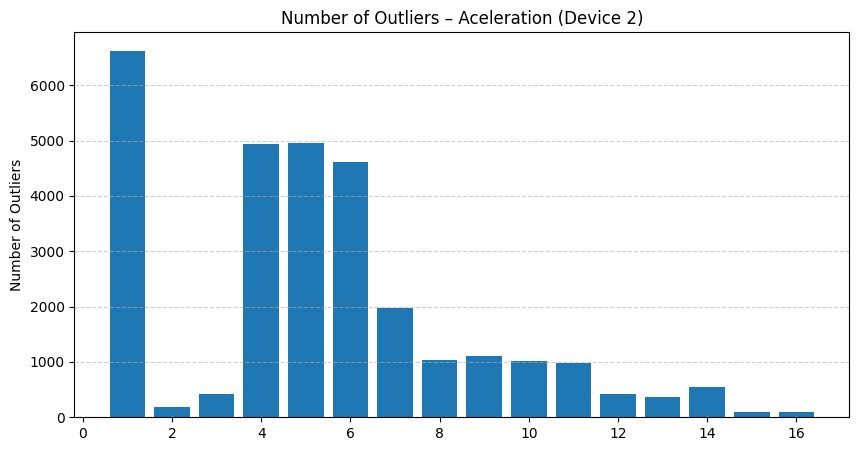


=== Gyroscope – Device 2 ===

Atividade 1: densidade = 9.48% (14975/157882 pontos)
Atividade 2: densidade = 6.65% (5581/83968 pontos)
Atividade 3: densidade = 9.12% (7399/81152 pontos)
Atividade 4: densidade = 1.62% (2268/139934 pontos)
Atividade 5: densidade = 1.43% (2033/142366 pontos)
Atividade 6: densidade = 1.50% (1339/89359 pontos)
Atividade 7: densidade = 2.07% (908/43791 pontos)
Atividade 8: densidade = 7.47% (497/6656 pontos)
Atividade 9: densidade = 10.78% (607/5632 pontos)
Atividade 10: densidade = 10.34% (688/6656 pontos)
Atividade 11: densidade = 11.87% (638/5376 pontos)
Atividade 12: densidade = 3.31% (126/3810 pontos)
Atividade 13: densidade = 8.25% (629/7620 pontos)
Atividade 14: densidade = 2.36% (90/3810 pontos)
Atividade 15: densidade = 2.36% (45/1905 pontos)
Atividade 16: densidade = 2.05% (39/1905 pontos)


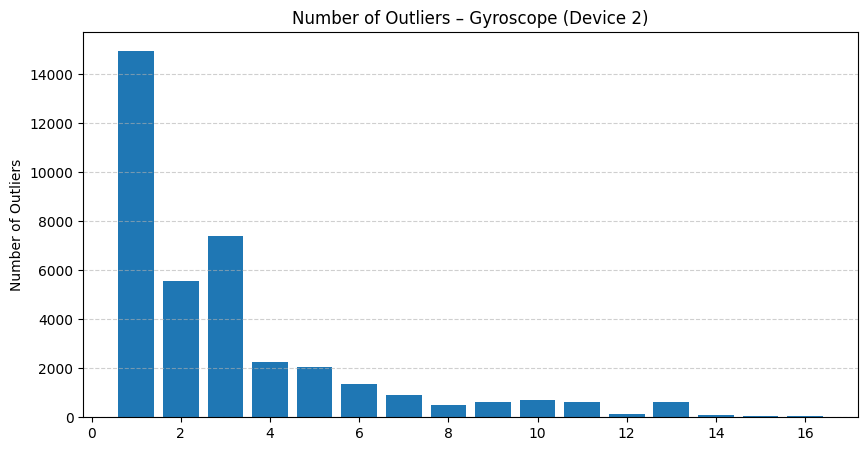


=== Magnetometer – Device 2 ===

Atividade 1: densidade = 0.00% (0/157882 pontos)
Atividade 2: densidade = 6.67% (5603/83968 pontos)
Atividade 3: densidade = 4.77% (3868/81152 pontos)
Atividade 4: densidade = 1.45% (2030/139934 pontos)
Atividade 5: densidade = 1.34% (1906/142366 pontos)
Atividade 6: densidade = 0.39% (349/89359 pontos)
Atividade 7: densidade = 0.22% (97/43791 pontos)
Atividade 8: densidade = 3.49% (232/6656 pontos)
Atividade 9: densidade = 7.35% (414/5632 pontos)
Atividade 10: densidade = 0.84% (56/6656 pontos)
Atividade 11: densidade = 6.83% (367/5376 pontos)
Atividade 12: densidade = 0.03% (1/3810 pontos)
Atividade 13: densidade = 0.00% (0/7620 pontos)
Atividade 14: densidade = 6.67% (254/3810 pontos)
Atividade 15: densidade = 6.67% (127/1905 pontos)
Atividade 16: densidade = 1.57% (30/1905 pontos)


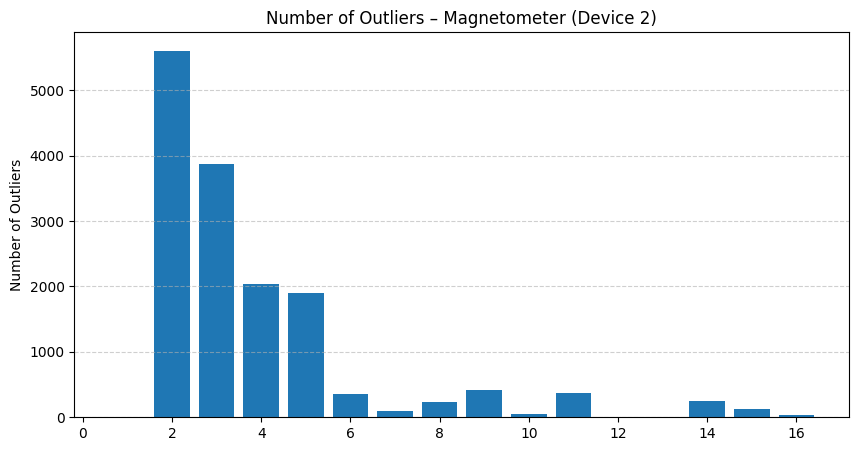

In [17]:
outliers_density(data, 1) # Aceleration
outliers_density(data, 2) # Gyroscope
outliers_density(data, 3) # Magnetometer

## Observações:
### Geral:
- A densidade de outliers varia significativamente entre os diferentes tipos de sensores e entre as diversas atividades, demonstrando que cada sensor capta diferentes aspetos do movimento do pulso direito.
  
- No dia a dia, esperariamos que atividades que envolvem movimentos como subir escadas, caminhas e por vezes até mesmo falar gerassem mais outliers. Mas será que os movimentos menos previssíveis, e não necessariamente os mais amplos, são os que geram mais valores atípicos?
  
- A análise dos gráficos requer algum cuidado na interpretação, pois as alturas das barras podem induzir em erro. Por exemplo, uma barra visualmente pode parecer que contém uma densidade maior de outliers, mas quando analisada a percentagem real, verifica-se que outra atividade tem na verdade maior densidade de outliers.
 
### Aceleração:
- As baixas densidades de outliers durante atividades estáticas e de deslocamento contínuo justificam-se pela natureza regular e previsível destes movimentos, que geram padrões de aceleração consistentes.
  
- Na atividades 8 a 11 e 14 observa-se uma densidade muito elevada de outliers. Estas atividades podem envolver mudanças bruscas com rápidas alterações de direção e intensidade do movimento que geram valores atípicos no sinal
  
- Nas atividades 15 e 16, apesar de serem também atividades de transição ( o que achamos que vai afetar muito), os valores são menos elevados. Isto pode dever-se ao facto destas transições ocorrerem entre atividades já dinâmicas, onde o corpo ja está habituado ao movimento e as transições são portanto mais suaves e menos bruscas.
#### Conclusão:
- Este sensor é particularmente sensível a transições e atividades que envolvem mudanças de aceleração.

### Giroscópio:
- A densidade de outliers no giroscópio apresenta um padrão distinto, com a atividade 9 a mostrar uma redução face ao outro sensor, mas mantendo-se elevada. A variação entre sensores deve-se à diferente natureza física que cada um mede, uma vez que nesta atividade não rodamos muita vez o pulso.
  
- A maioria das atividades apresenta densidades mais elevadas neste sensor relativamente ao acelerómetro provavelmente causado pela maior sensibilidade do giroscópio a movimentos do corpo e a ajustes posturais.
  
- As atividades 1, 3, 9, 10 e 11 são as que apresentam percentagens mais elevadas. Isto justifica-se pelo facto de envolverem movimentos já estabilizados, onde o pulso mantém uma postura relativamente regular.
  
- Curiosamente, as atividades que à partida esperariamos que mais influenciassem o giroscópio seriam as 16, 7 e 14 na nossa perspetiva. No entanto, ao analisarmos percebemos que não apresentam as densidades mais elevadas. Isto justifica-se pelo facto destas atividades envolverem já uma estabilidade.
#### Conclusão:
- O giroscópio, sendo mais sensível ao movimento de rotação do pulso, regista uma maior densidade de outliers em situações que envolvem manter o corpo estável. 

### Magnetómetro:
- As atividades que esperaríamos que mais influenciassem o magnetómetro (14, 15 e 16) não apresentam as densidades mais elevadas.
- atividades como a 1, 6, 7, 10, 12, 13 têm densidades nulas ou muito baixas, possivelmente por repetirem gestos muitos previsíveis que não alteram significativamente a orientação do sensor.
- Este é o sensor com as menores densidades de outliers, indicando que é menos afetado por variações de movimento. 
- Atividade com maior valor é a 9, possivelmente devido a mudanças inesperadas de orientação do pulso durante a transição de estar sentado.
- Atividade 2 e 3 aumentaram consideravelmente em relação aos outros sensores, o que pode dever-se a ajustes de posição por desconforto durante períodos prolongados sentado 
#### Conclusão:
- O magnetómetro apresenta um padrão de outliers menos relacionado com a dinâmica do movimento e mais com variações contextuais.

### Exercício 3.3
Escreva uma rotina que receba um Array de amostras de uma variável e identifique os outliers usando o teste Z-Score para um k variável (parâmetro de entrada).

In [ ]:
from scipy import stats
# zscore = (valor - média) / desvio_padrão
def detect_outliers_zscore (samples, k):
    z_scores = stats.zscore(samples, nan_policy='omit')
    return np.abs(z_scores) > k


#### Explicação da rotina:
- Inicialmente implementamos uma versão manual para este exercício através do cálculo: z_scores = np.abs((samples - mean) / std), onde qualquer valor com z_score absoluto superior ao limiar k era considerado outlier. No entanto, após pesquisarmos alternativas mais robustas, optámos pela versão utilizando a biblioteca SciPy. Esta decisão deveu-se a várias vantagens:
1. robustez e segurança.
2. configuramos o parâmetro nan_policy=omit para lidar adequadamente com valores não numéricos. Esta escolha é importante porque trabalhamos com dados de sensores, Ao utilizar omit, garantimos que qualquer valor não válido é excluído do cálculo do z-score.

- Escolhemos especificamente a opção omit em alternativa a propagate ou raise, pois desta maneira mantemos a execução do código mesmo na presença de dados incompletos, ao mesmo tempo que asseguramos que os cálculos são baseados apenas em valores válidos. 
- No final vai retornar um array boolenao onde True indica que é outlier

### Exercício 3.4
Usando o Z-score implementado, assinale todos as amostras consideradas outliers nos módulos dos vetores de aceleração, giroscópio e magnetómetro.
Apresente plots em que estes pontos surgem a vermelho, enquanto os restantes surgem a azul. Use k=3, 3.5 e 4.

In [19]:
def plot_zscore_outliers(data, sensor, k_values=[3.0, 3.5, 4.0]):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    # módulo = sqrt(x² + y² + z²)
    mod = np.sqrt((data[:, c] ** 2).sum(axis=1))

    #informações 
    activities = data[:, 12].astype(int)
    devices = data[:, 1].astype(int)
    unique_activities = np.unique(activities)
    unique_devices = np.unique(devices)

    # Loop para cada valor de k
    for k in k_values:
        # Loop por cada dispositivo
        for dev in unique_devices:
            #cria figura para cada dispositivo e para cada k
            plt.figure(figsize=(10, 5))
            plt.title(f'{label} - Device {dev} | Outliers Z-Score (k={k})')
            
            
            for i, act in enumerate(unique_activities):
                mask = (devices == dev) & (activities == act)
                mod_act = mod[mask]
                
                if len(mod_act) == 0:
                    continue  # pular se não há dados
                
                out = detect_outliers_zscore(mod_act, k)
                
                # Pontos normais em azul
                normais = mod_act[~out]
                plt.scatter([i+1]*len(normais), normais, color='blue', s=20)
                # Outliers em vermelho
                outliers = mod_act[out]
                plt.scatter([i+1]*len(outliers), outliers, color='red', s=40)
            
            plt.xlabel('Activity')
            plt.ylabel(f'{label} Module')
            plt.xticks(range(1, len(unique_activities)+1), [f"A{a}" for a in unique_activities], rotation=90)
            plt.tight_layout()
            plt.show()


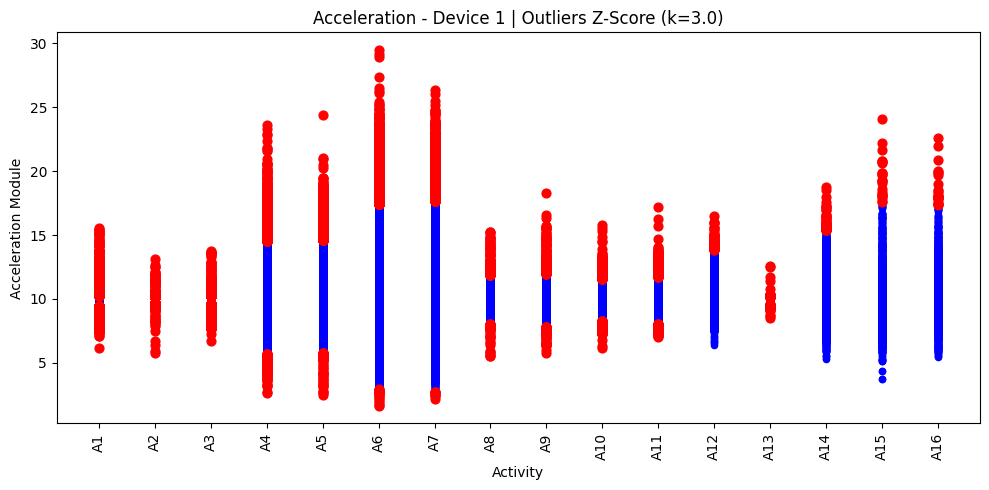

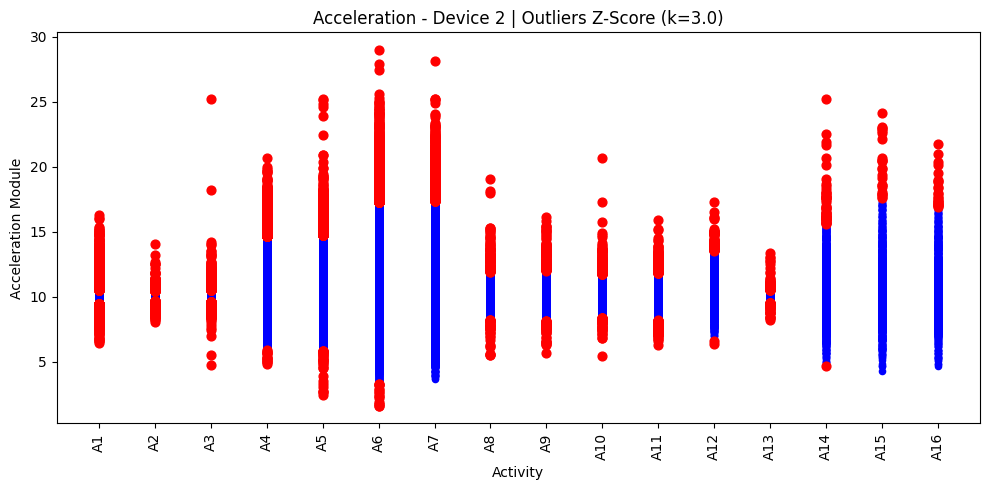

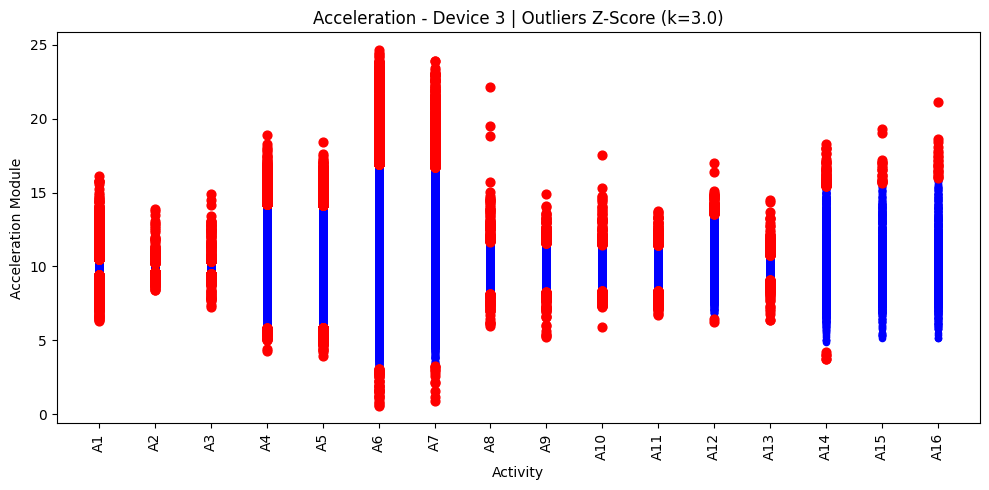

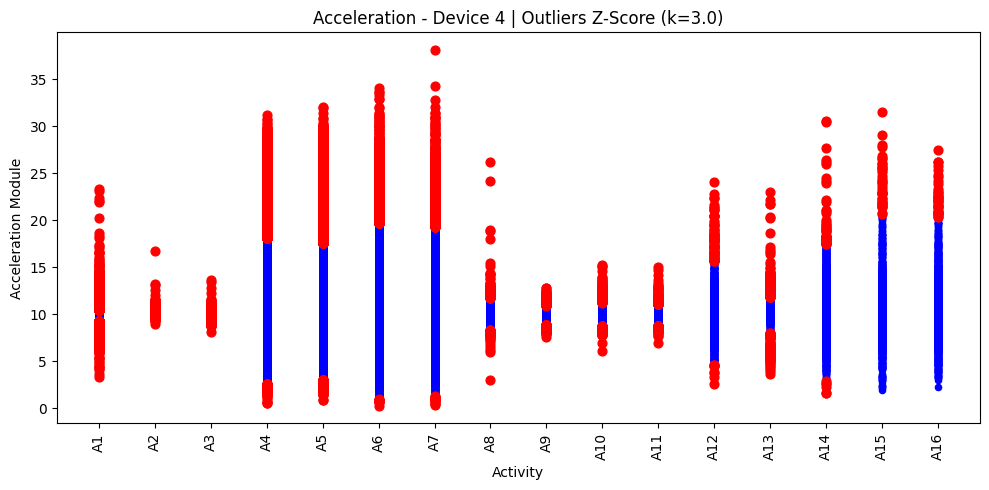

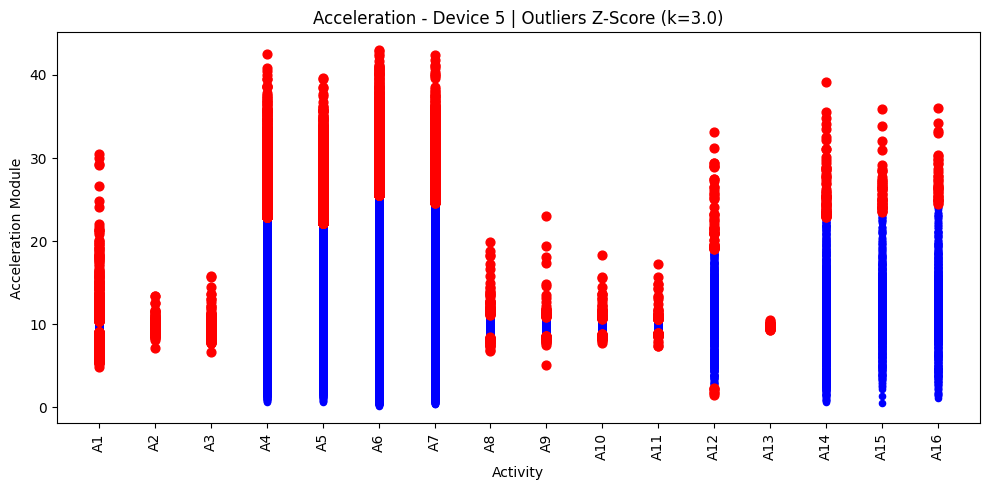

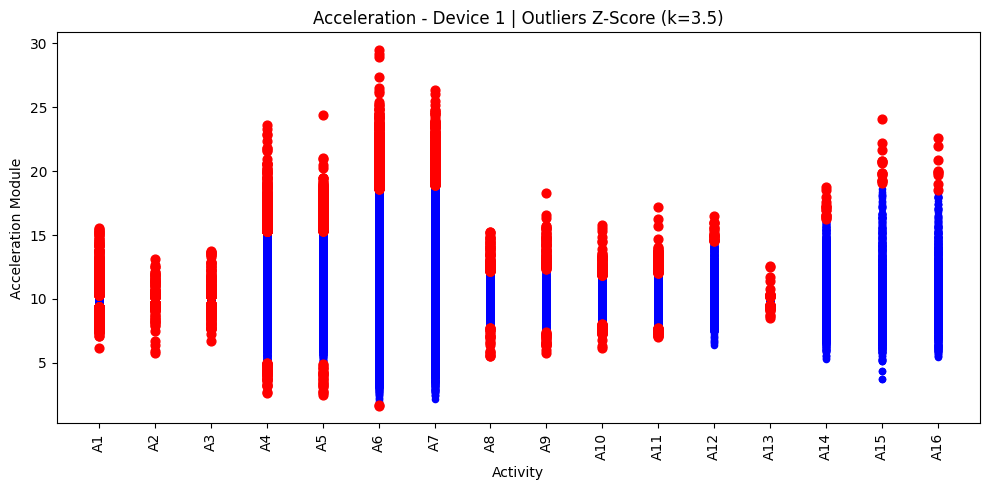

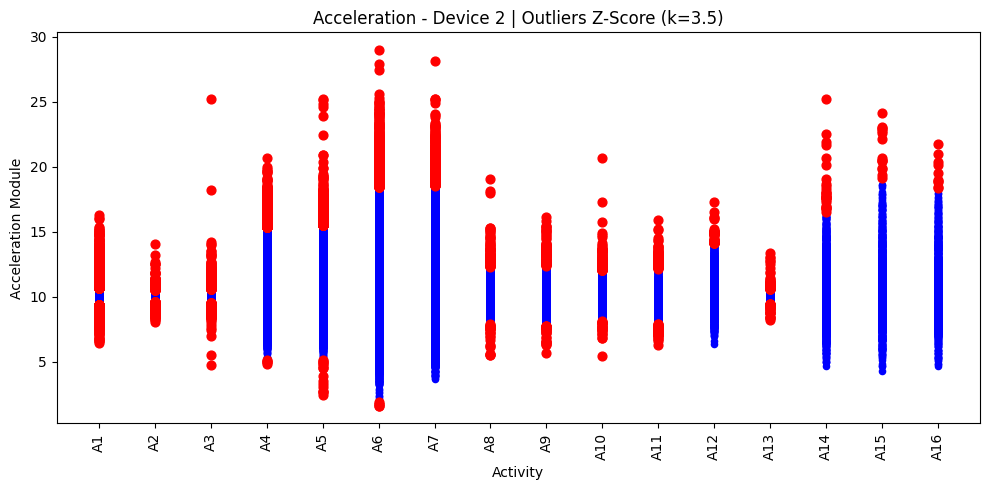

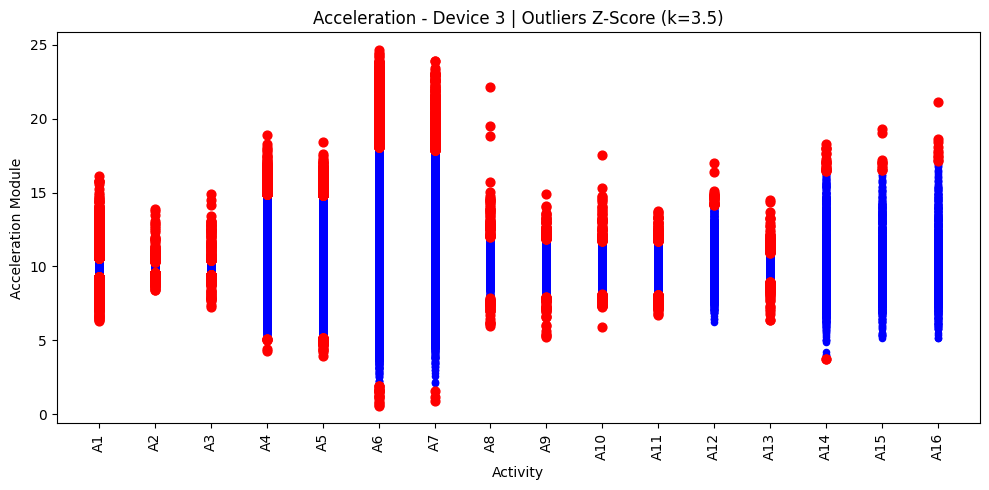

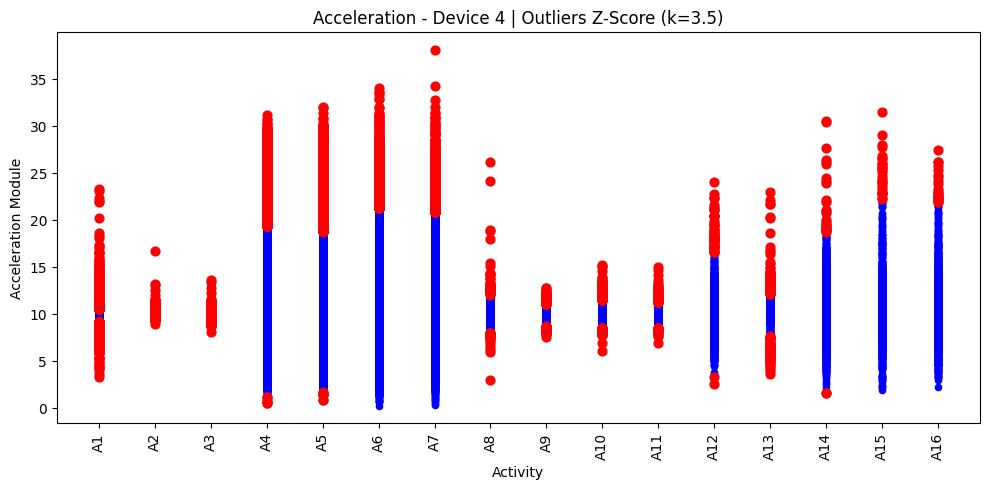

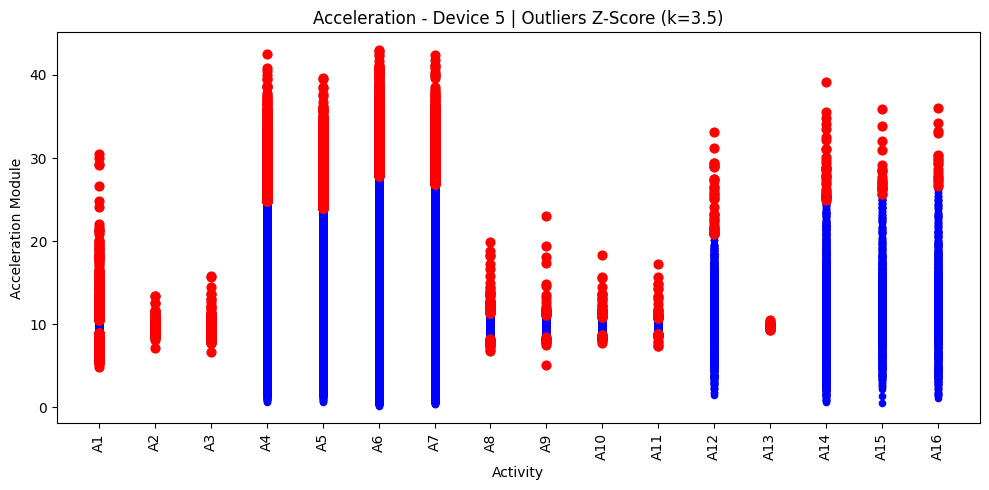

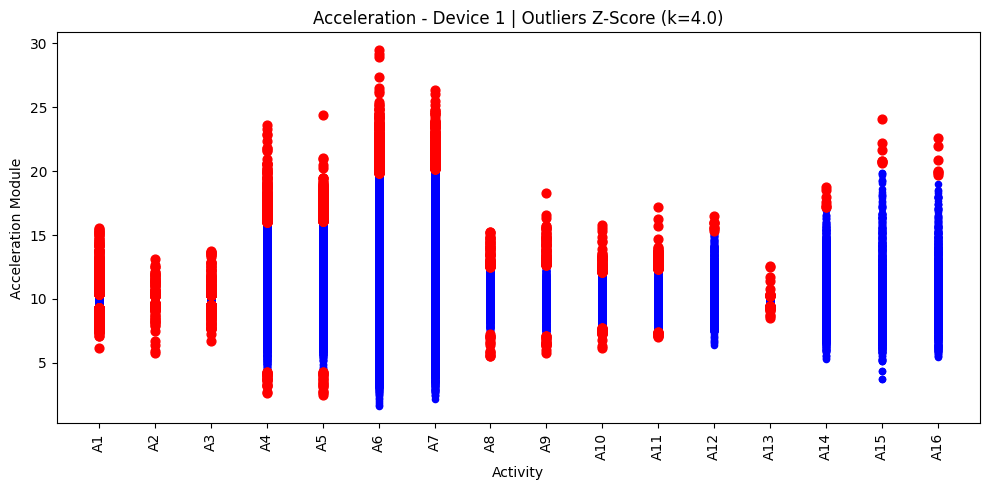

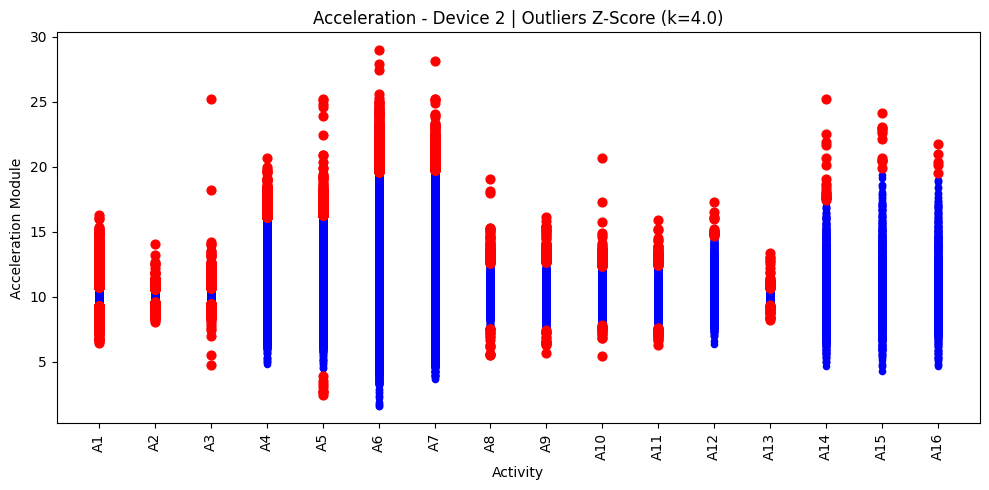

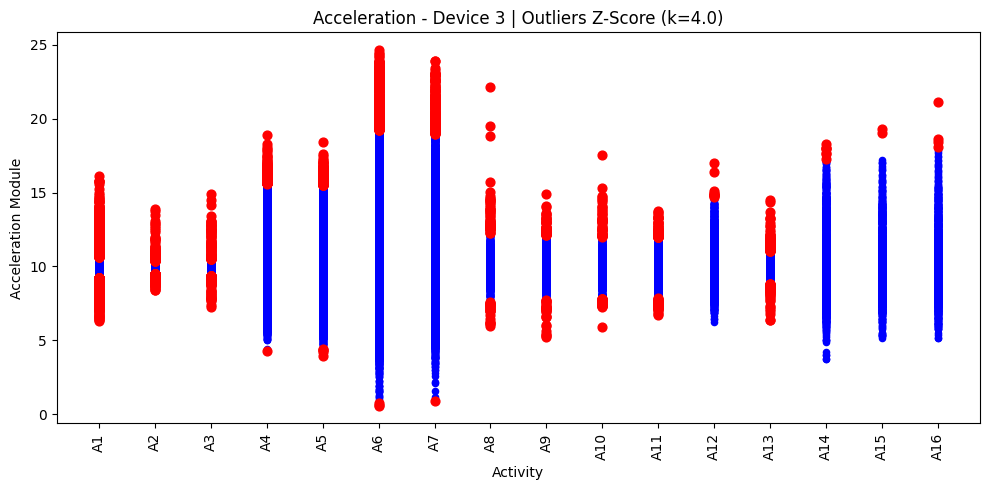

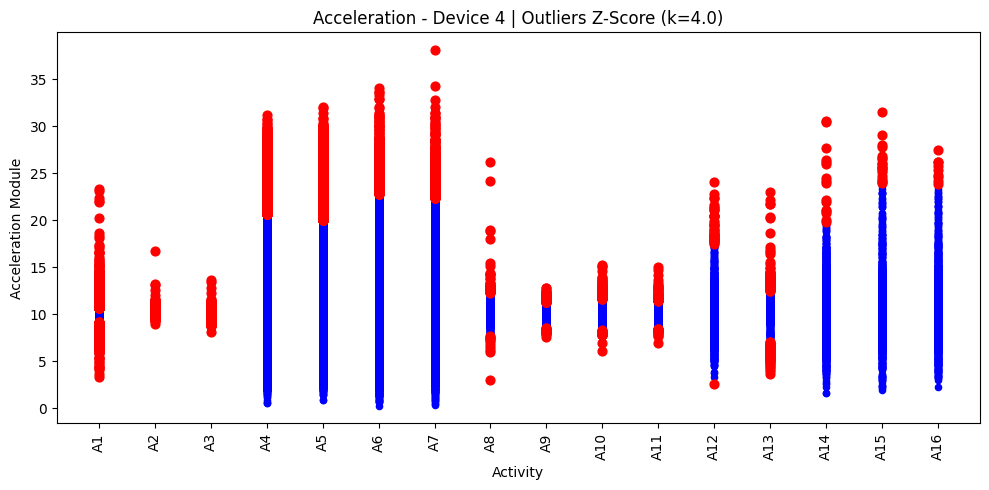

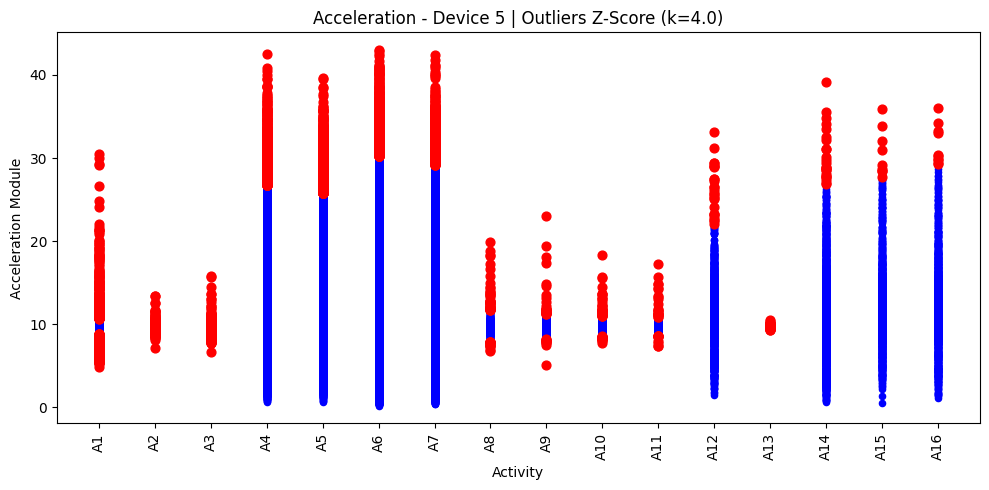

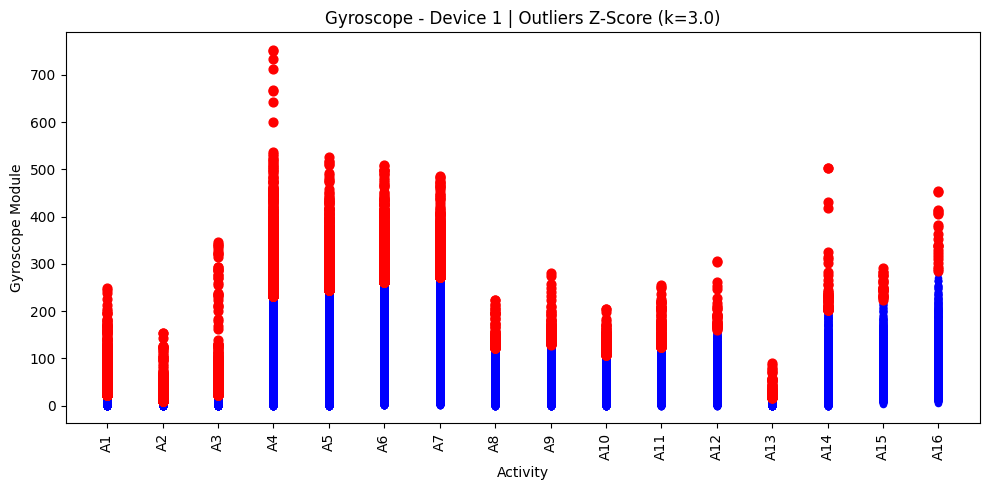

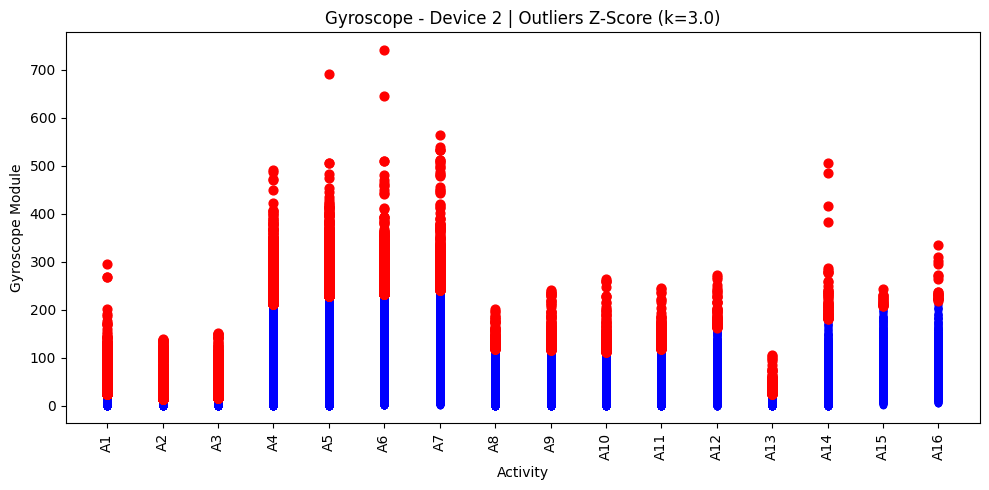

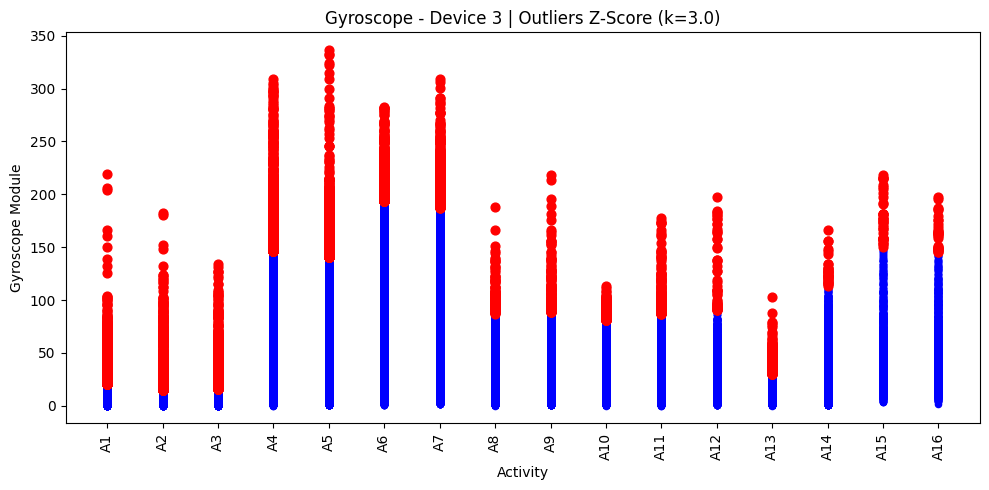

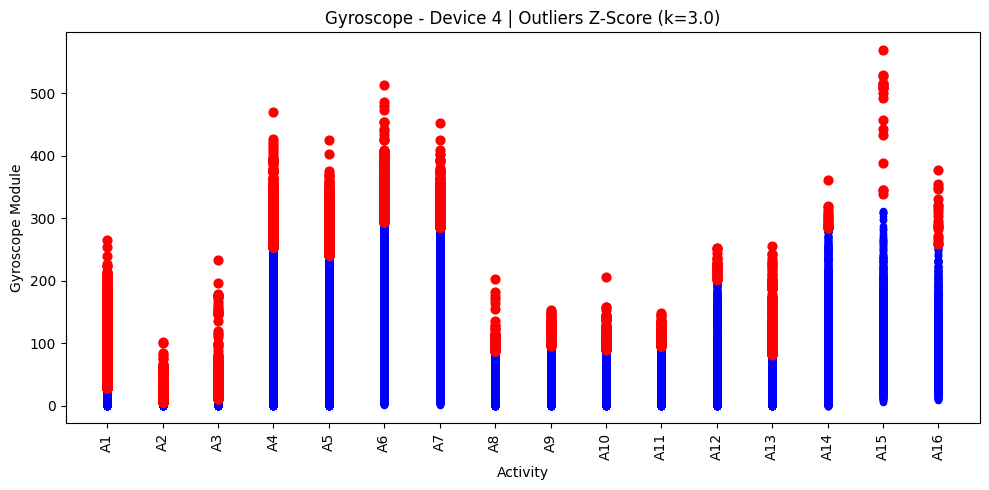

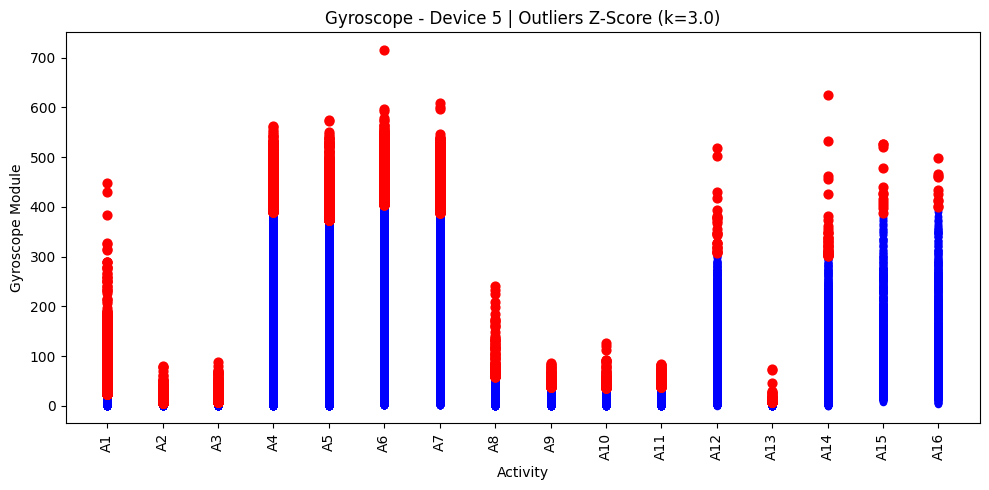

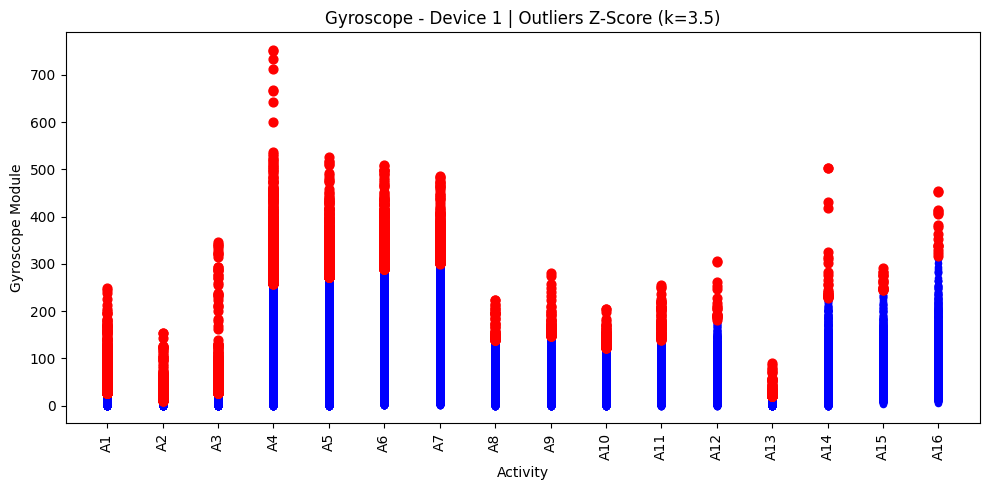

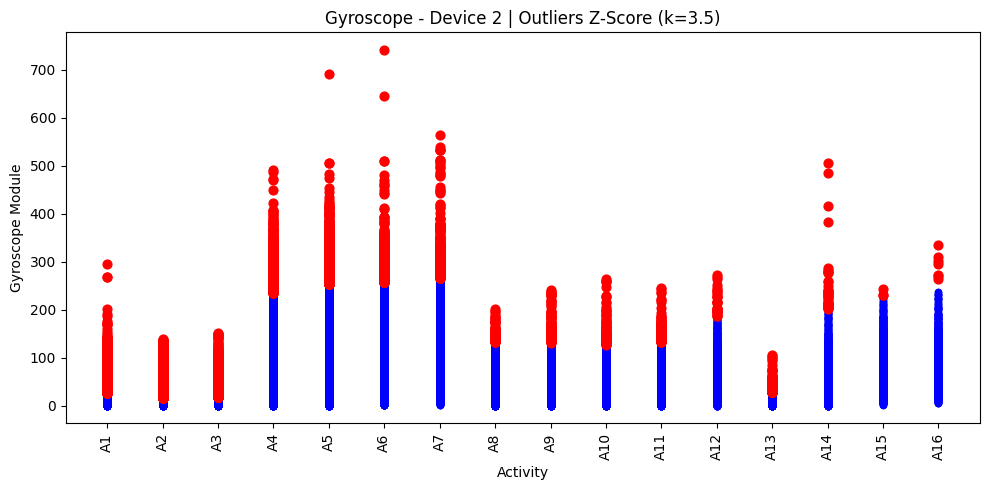

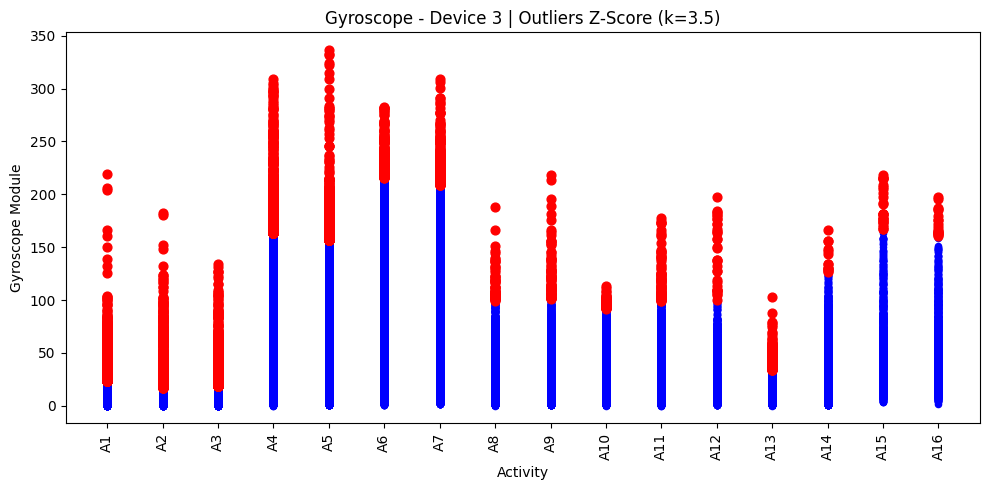

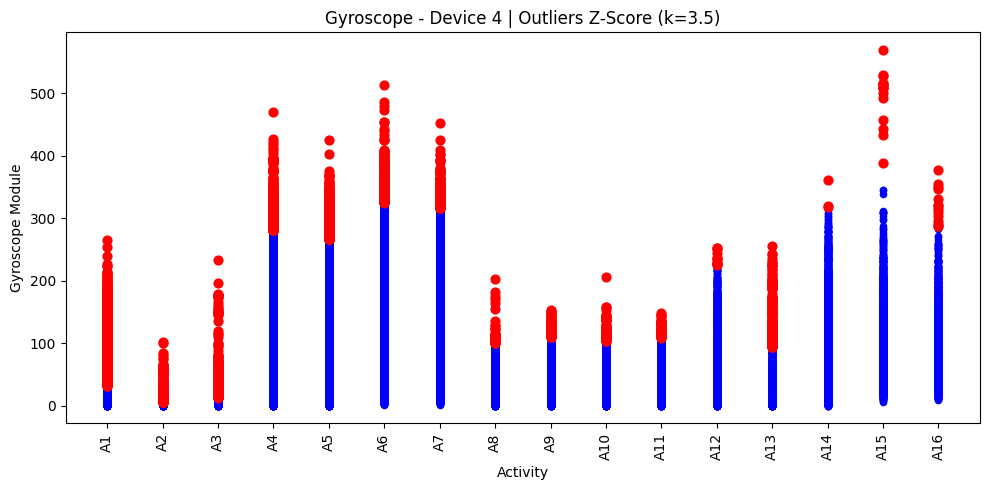

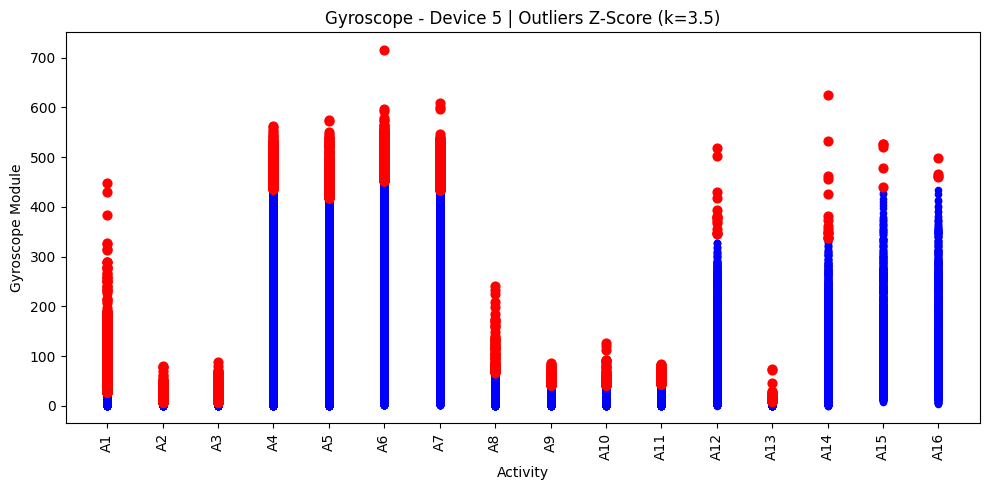

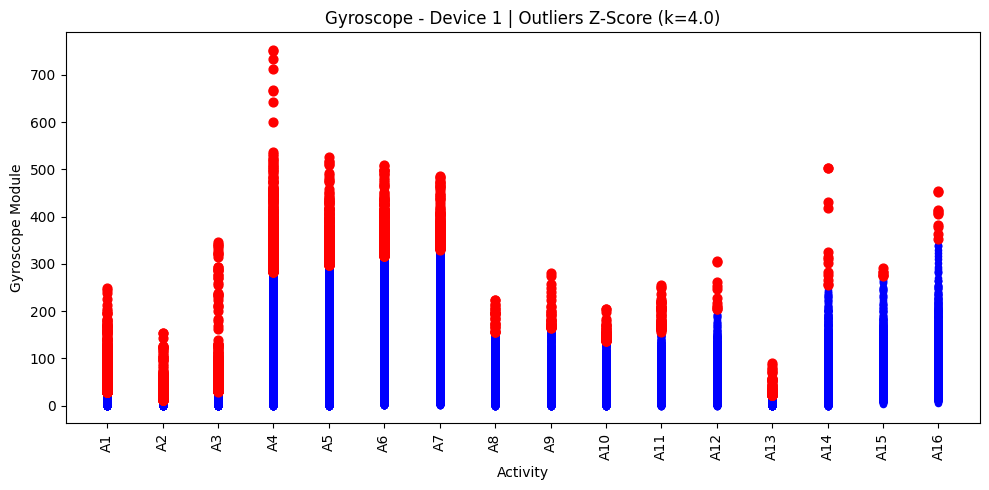

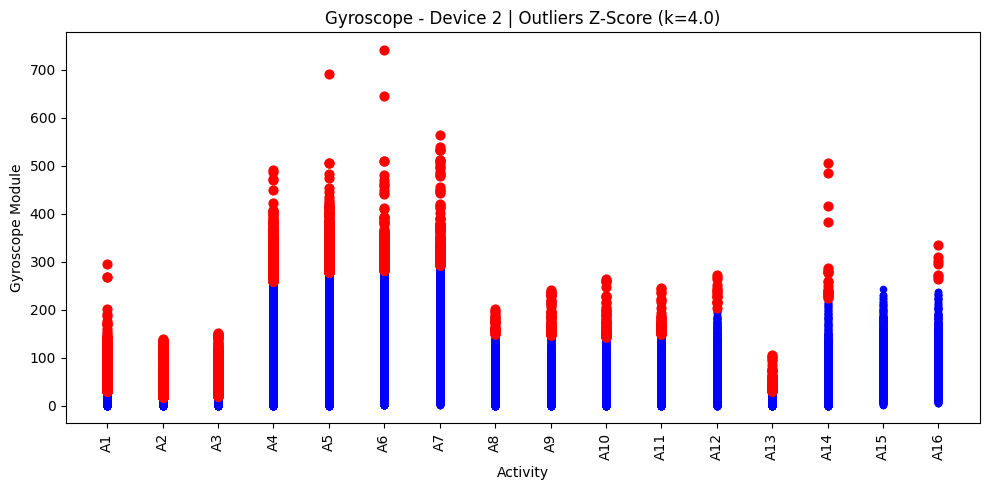

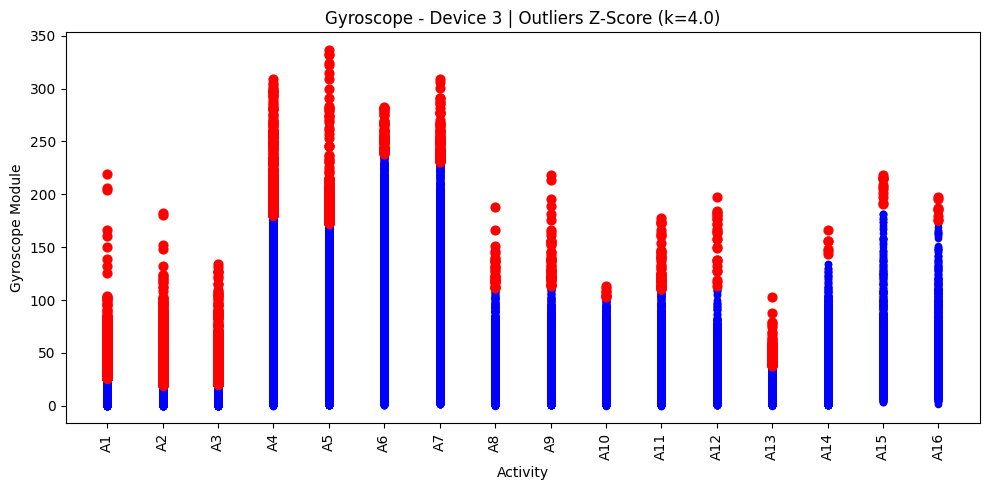

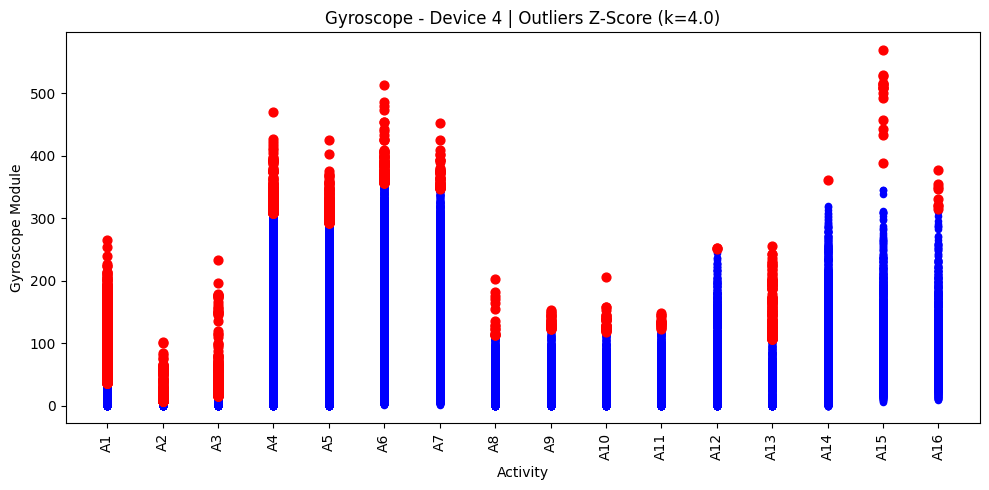

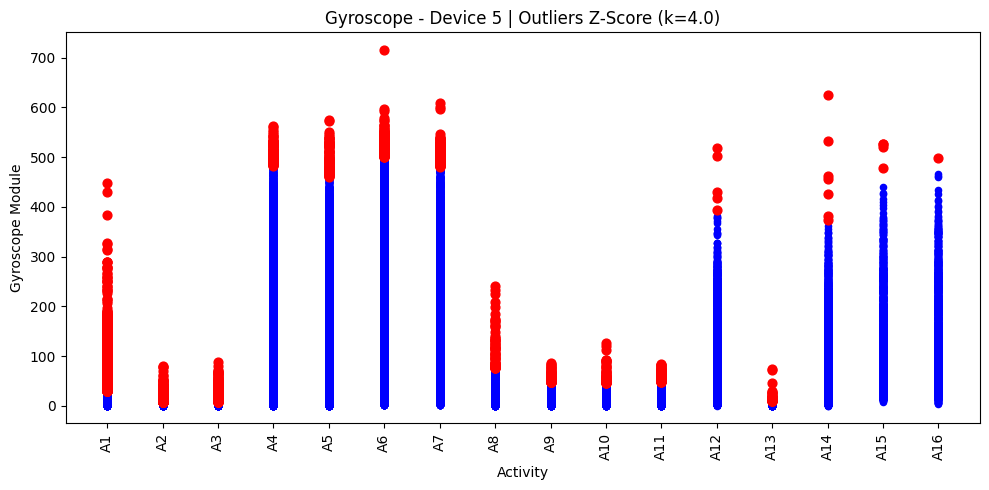

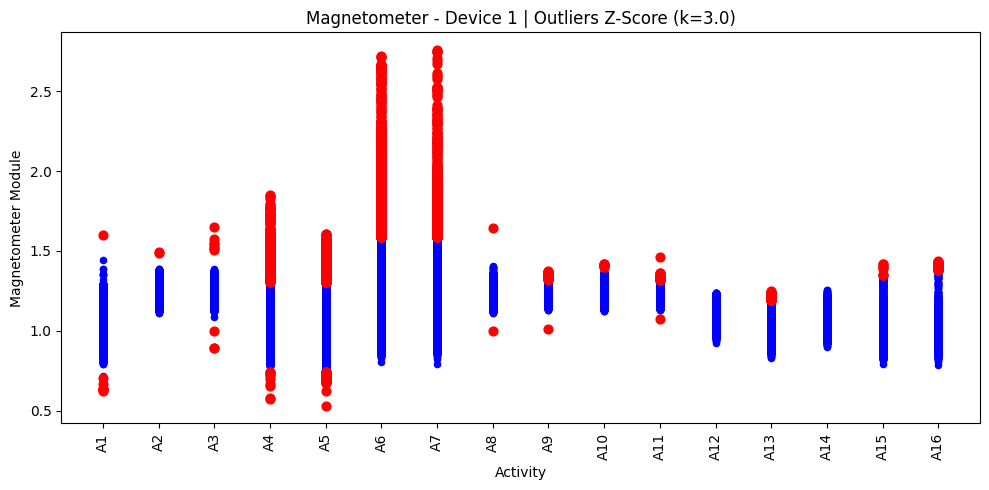

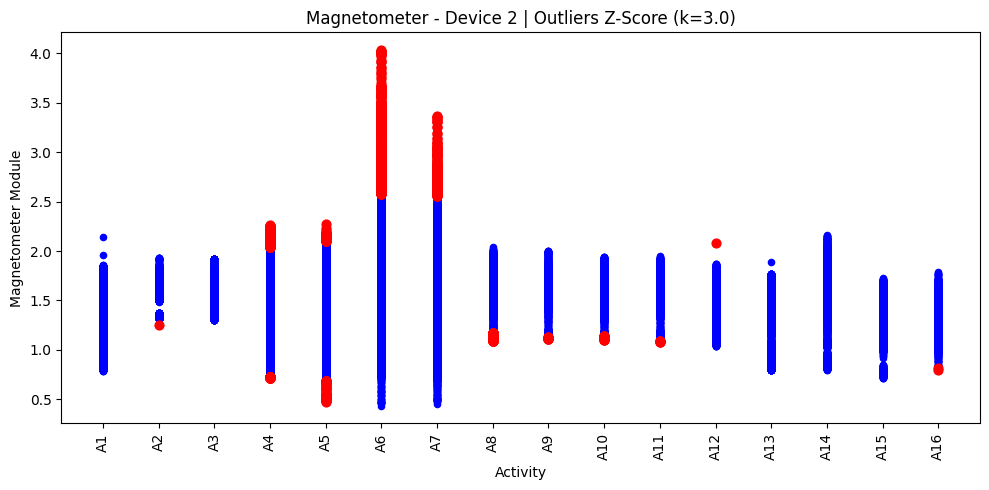

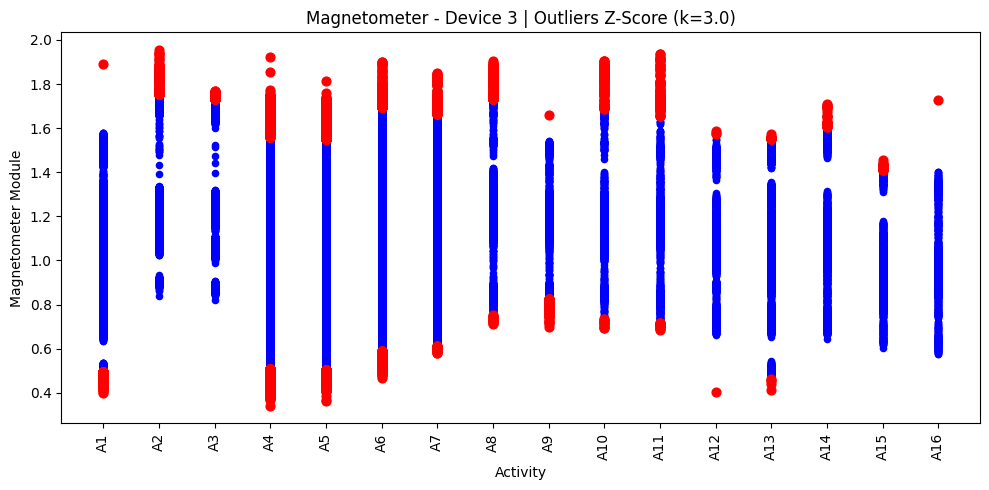

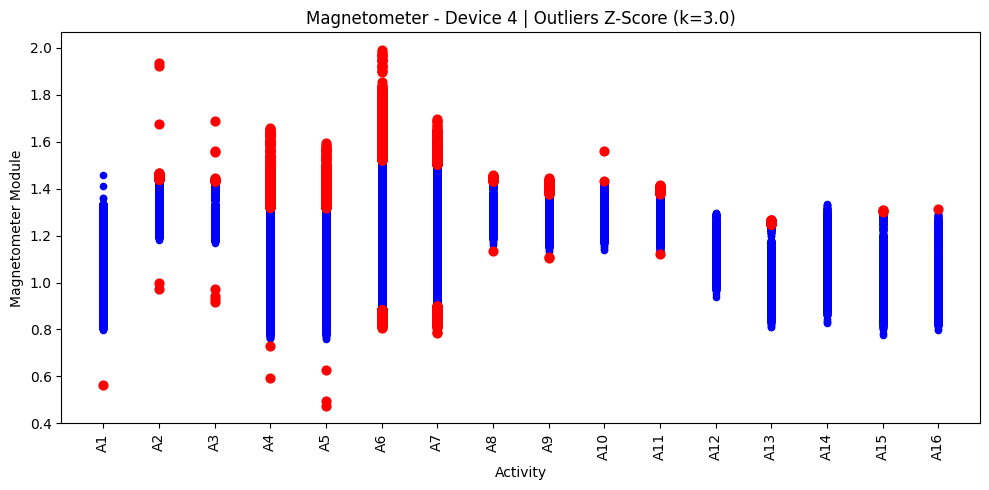

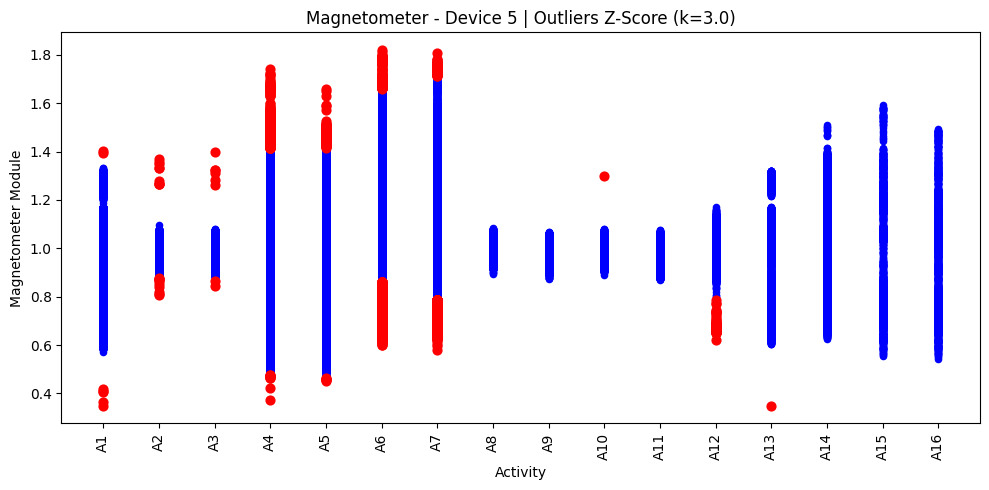

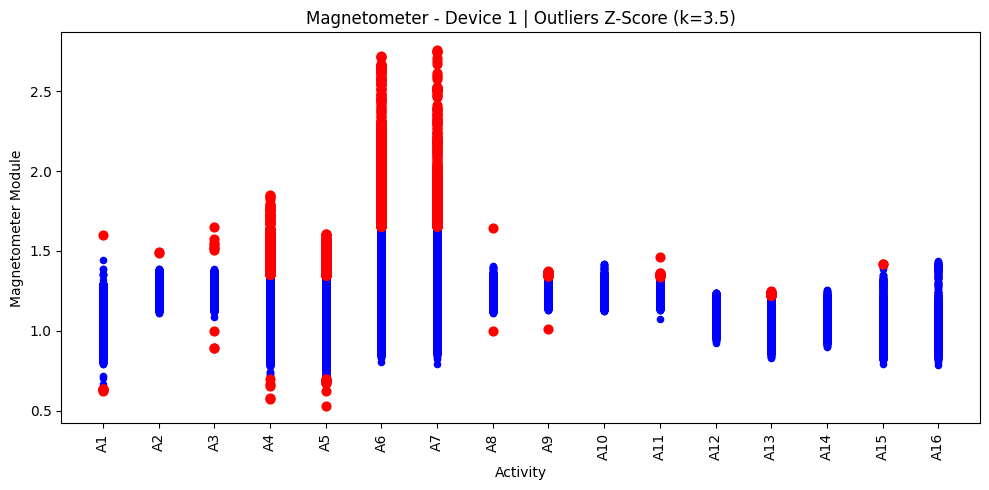

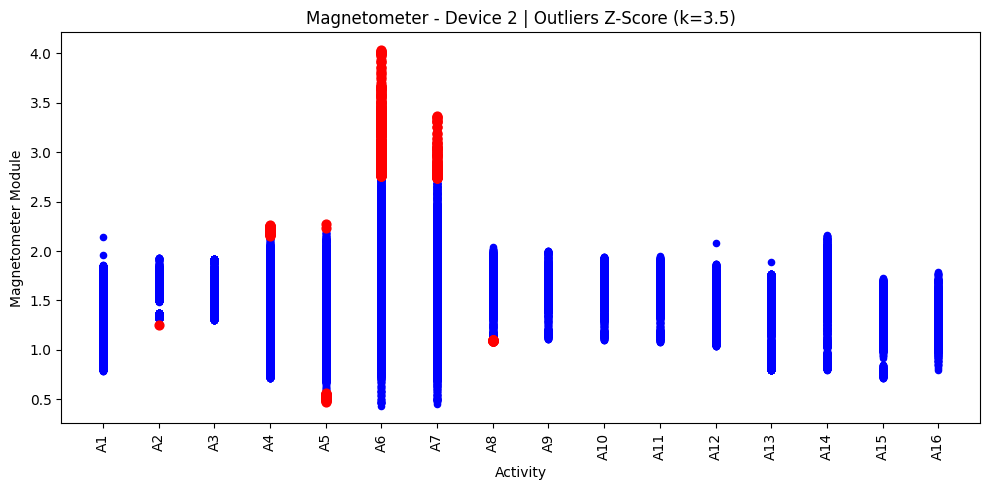

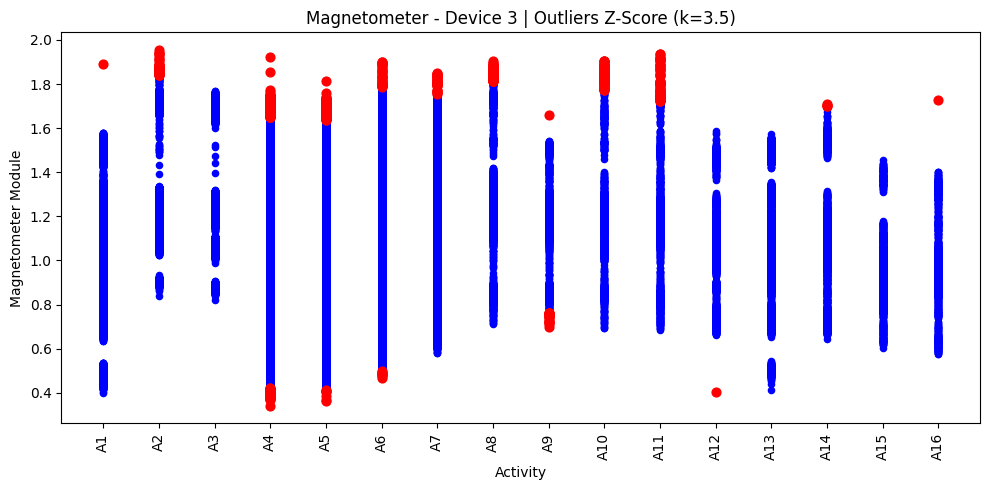

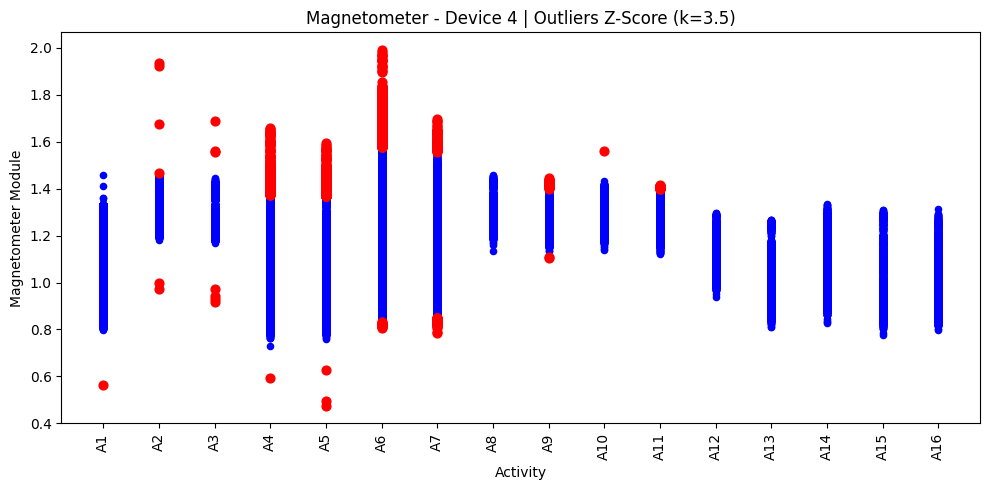

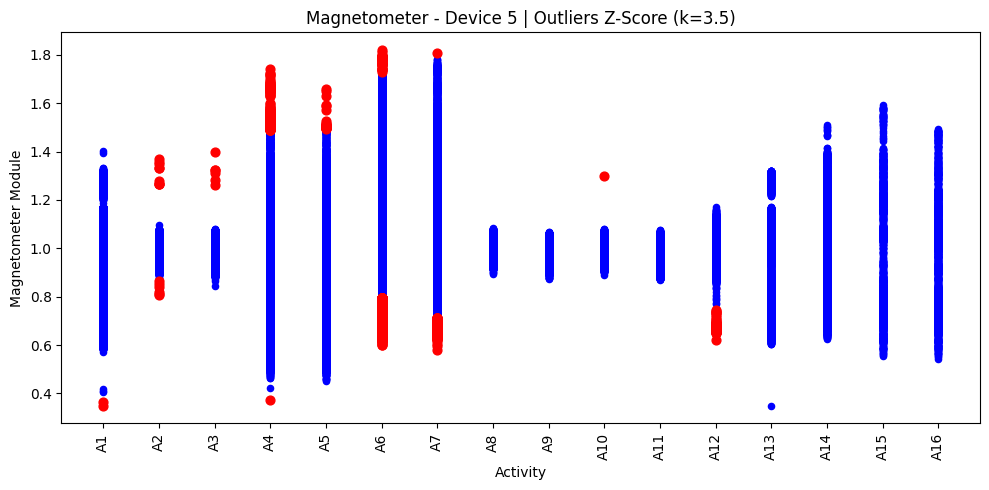

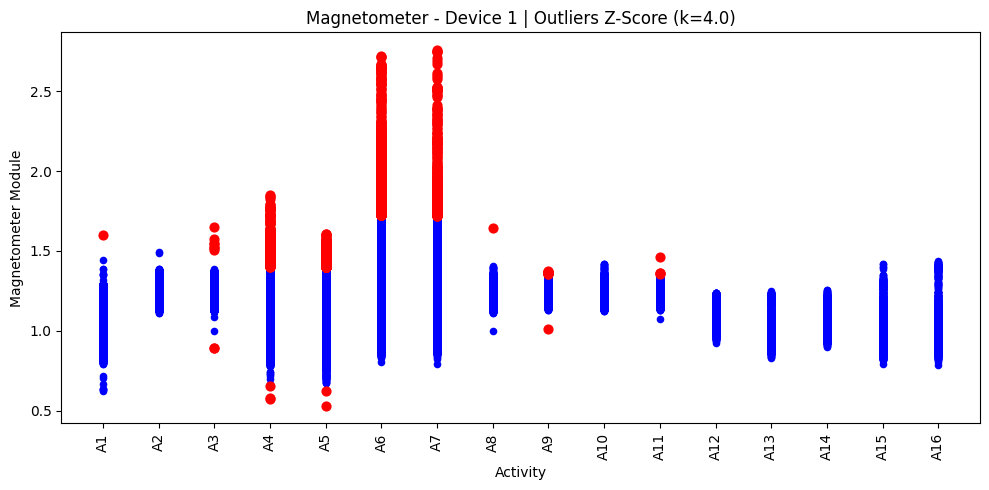

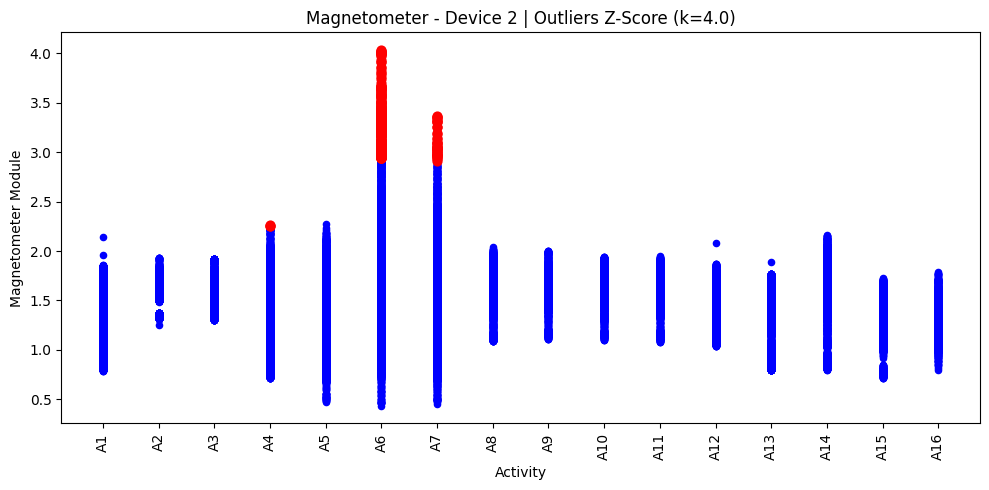

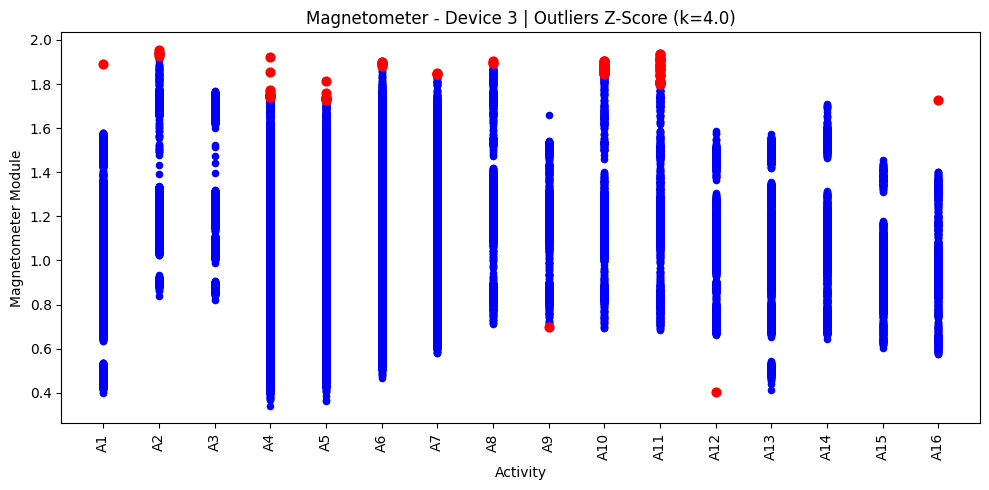

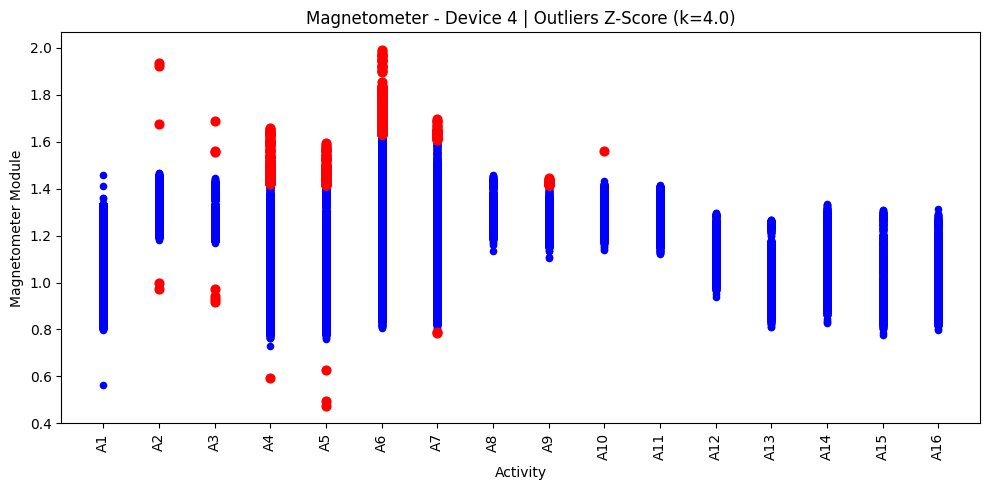

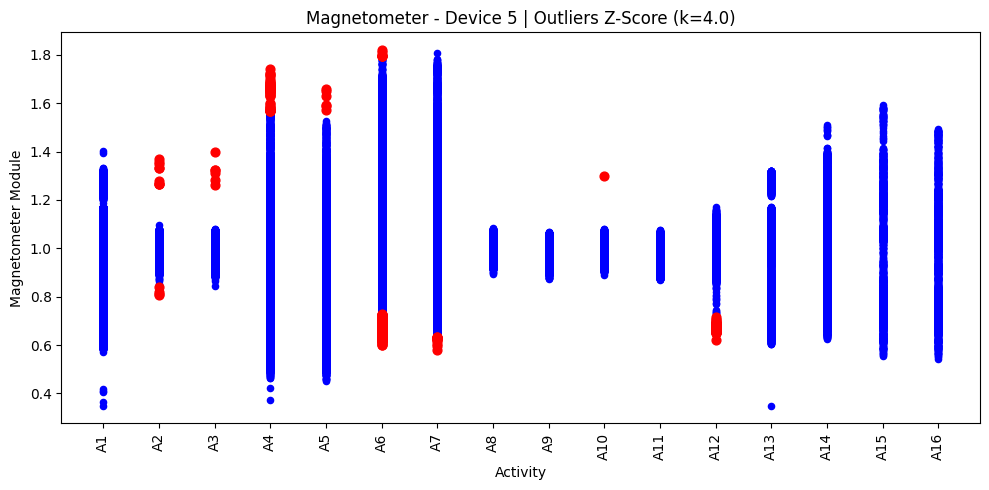

In [20]:
plot_zscore_outliers(data, sensor=1)  # Aceleração
plot_zscore_outliers(data, sensor=2)  # Giroscópio
plot_zscore_outliers(data, sensor=3)  # Magnetômetro

### Observações
#### Análise dos Gráficos Z-Score
Os gráficos 2D do Z-Score mostram os outliers (a vermelho) identificados em cada atividade, com base no módulo de cada sensor (aceleração, giroscópio e magnetómetro)
##### Observação do k:
Como se pode observar nos gráficos, o valor de k funciona como um limiar de tolerância.
- Com k = 3.0 (tolerância baixa), o método é muito rigoroso e marca uma grande quantidade de pontos como outliers, especialmente em atividades dinâmicas.

- Com k = 3.5 (tolerância média), o número de outliers detetados diminui, mas ainda é considerável, refletindo a variabilidade natural dos movimentos humanos.

- Com k = 4.0 (tolerância alta), o número de outliers detetados diminui significativamente, pois o limiar para considerar um ponto anómalo é mais elevado.
##### Limitações do Z-Score:
O Z-Score baseia-se na média e no desvio-padrão de toda a atividade. Em movimentos humanos, que têm naturalmente uma alta variabilidade, muitos pontos que são picos normais do movimento acabam por ser marcados como outliers. Ele apenas vê a magnitude sem considerar o contexto.

### Aceleração:
- DISPOSITIVO 1: Com o aumento do limiar k de 3.0 para 3.5, observa-se uma redução de outliers. As atividades 4, 5 e 6 apresentam as maiores reduções, o que indica que estas captam movimentos naturais do pulso durante mudanças de posição e deslocamento que podem ser erradamente classificados como anomalias com limiares mais restritivos. A atividade 1 manteve muitos outliers mesmo com k=3.5, sugerindo a presença de movimentos atípicos durante períodos de repouso. Quando o k aumenta para 4.0, observa-se uma redução ainda mais acentuada nos outliers totais, com as atividades 4, 5, 6 mostrando as quedas mais pronunciadas. Ainda assim, a atividade 1 mantém uma proporção relativamente maior de outliers, reforçando a hipótese de comportamentos atípicos. A localização do sensor no pulso esquerdo mostrou-se particularmente sensível à variabilidade natural e movimento.
  
- DISPOSITIVO 2: Comportamento semelhante ao pulso esquerdo. Ambos os pulsos exibem reduções acentuadas nas atividades dinâmicas com o aumento do k, mas o pulso direito mostra um maior número de outliers na atividade 1 e quedas mais visíveis nas atividades 4 a 6.

- DISPOSITIVO 3: O que se destaca mais é a atividade 13. Com um k mais baixo, existe um maior numero de outliers devido a constantes variações de movimento e equilíbrio registadas no peito. As atividades 4 e 6 também revelam muitos outliers, refletindo a alta variabilidade de aceleração no peito durante estes movimentos.
  
- DISPOSITIVO 4: Verifica-se uma redução progressiva de outliers com o aumento de k, especialmente nas atividades dinâmicas como a 4 e 6. Contudo, mesmo com um limiar mais restritivo, as atividades estáticas como a 1 ou 2 mantêm quantidades relativamente elevadas de outliers, possivelmente devido à localização do sensor na perna, parte que está sujeita a movimentos naturais e ajustes posturais mesmo durante o repouso.

- DISPOSITIVO 5: Em todos os valores de k, as atividades 4 e a 5 são consistentemente as que apresentam mais outliers o que é justificável, pois o sensor na perna está diretamente envolvido no movimento, gerando sinais de aceleração mais variáveis.
#### Conclusão:
- Independente do limiar, observa-se uma concentração significativa de outliers nas atividades 4, 5, 6 e 7. Isso sugere que movimentos dinâmicos e combinados com fala geram maior variabilidade nos sinais de aceleração.
  
### Giroscópio :
  - DISPOSITIVO 1 e 2: A atividade com mais outliers é a 1, possivelmente porque qualquer movimento mínimo ou involuntário é considerado uma variação extrema.
  
  - DISPOSITIVO 2: Na atividade 14 não existe outliers em k=4 isto pode ser ao facto de serem bastante homogéneos,o que faz com que nenhum ponto se destaque significativamente dos restantes.
  
  - DISPOSITIVO 3: As atividades como 4 e 5 em relação aos outros dispositivos é o que tem o maior número de outliers porque no peito é onde se consegue capturar todos os movimentos corporais da parte de cima enquanto outros sensores medem apenas movimentos mais restritivos
  
  - DISPOSITIVO 4: A atividade com mais outliers é a 1, o que é interessante uma vez que ficar em pé é considerada por não ter muitos movimentos. Isto pode ser explicado através dos ajustes que o corpo faz para manter o equilibrio.
  
  - DISPOSITIVO 5: Os maiores números de outliers ocorrem durante as atividades 1, 2, 4 e 6 que são atividades com forte movimento da perna. A localização do sensor na perna inferior esquerda parece influenciar estes resultados uma vez que atividades dinâmicas como a 4 ou a 7, onde o movimento da perna é mais previsível e contínuo, tendem a ter menos outliers em comparação com posturas estáticas.
  #### Conclusão:
  - O giroscópio mostra maior sensibilidade a pequenos movimentos e a ajustes de corpo especialmente em atividades estáticas. Já nas outras atividades os outliers tendem a ser menos.

### Magnetómetro:
  - DISPOSITIVO 1 e 2: Valores de outliers mais baixos nestes dispositivos provavelmente devido à sua localização menos exposta ao campo magnético. No entanto as atividades 4 a 7 ainda exibem valores mais altos, indicando que o movimento do braço pode interferir variações no campo magnético.
  
  - DISPOSITIVO 3: A atividade 1 destaca-se, onde para k= 3.0 existem muitos outliers, mas para k=3.5 e 4.0 os outliers tornam-se quase nulos. As outras atividades não apresentam variações tão drástica.
  
  - DISPOSITIVO 4: A atividade 6 é a que mais se destaca.
  
  - DISPOSITIVO 5: As atividades 2,3,4,5,6,7 e 12 apresentam outliers em todos os limiares de k porque envolvem os principais movimentos da perna. As restantes atividades não registam outliers por não existir um movimento significativo da perna e sem picos significativos.
  #### Conclusão:
  - É o sensor que tem menos outliers independente do valor de k. Isto ocorre porque as variações no campo magnético são geralmente mais estáveis e menos afetadas, tornando este sensor menos sensível à variabilidade dos movimentos humanos.

### Observações
#### Análise dos Gráficos Z-Score (Exercício 3.4)
Os gráficos 2D do Z-Score mostram os outliers (a vermelho) identificados em cada atividade, com base no módulo de cada sensor (aceleração, giroscópio e magnetómetro)
##### Observação do k:
Como se pode observar nos gráficos, o valor de k funciona como um limiar de tolerância.
- Com k = 3.0 (tolerância baixa), o método é muito rigoroso e marca uma grande quantidade de pontos como outliers, especialmente em atividades dinâmicas.
- Com k = 3.5 (tolerância média), o número de outliers detetados diminui, mas ainda é considerável, refletindo a variabilidade natural dos movimentos humanos.
- Com k = 4.0 (tolerância alta), o número de outliers detetados diminui significativamente, pois o limiar para considerar um ponto anómalo é mais elevado.
##### Limitações do Z-Score:
O Z-Score baseia-se na média e no desvio-padrão de toda a atividade. Em movimentos humanos, que têm naturalmente uma alta variabilidade, muitos pontos que são picos normais do movimento acabam por ser marcados como outliers. Ele apenas vê a magnitude sem considerar o contexto.

### Exercício 3.5
#### Compare e discuta os resultados obtidos em 3.1 e 3.4. 

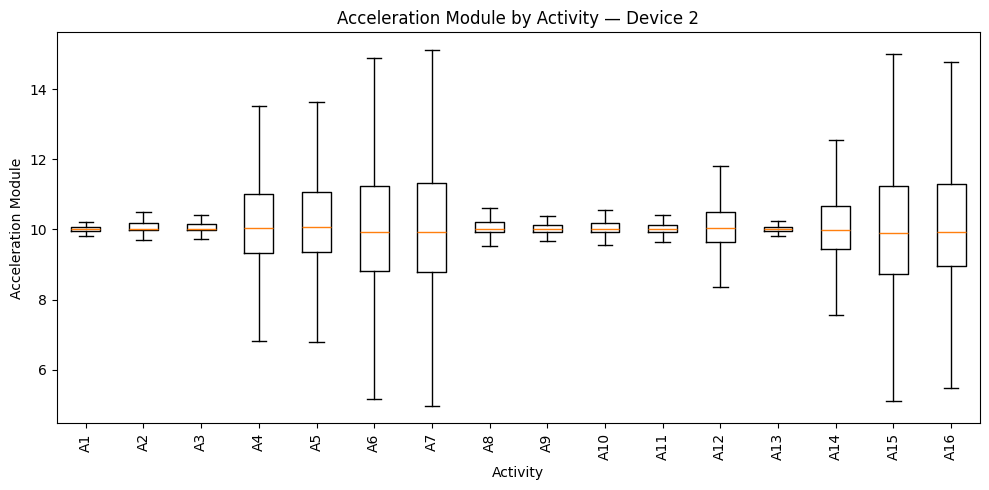

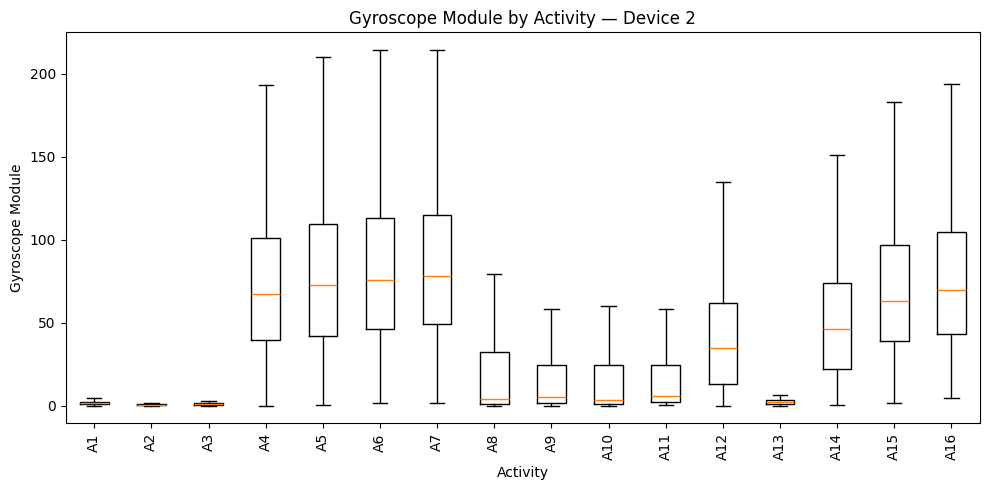

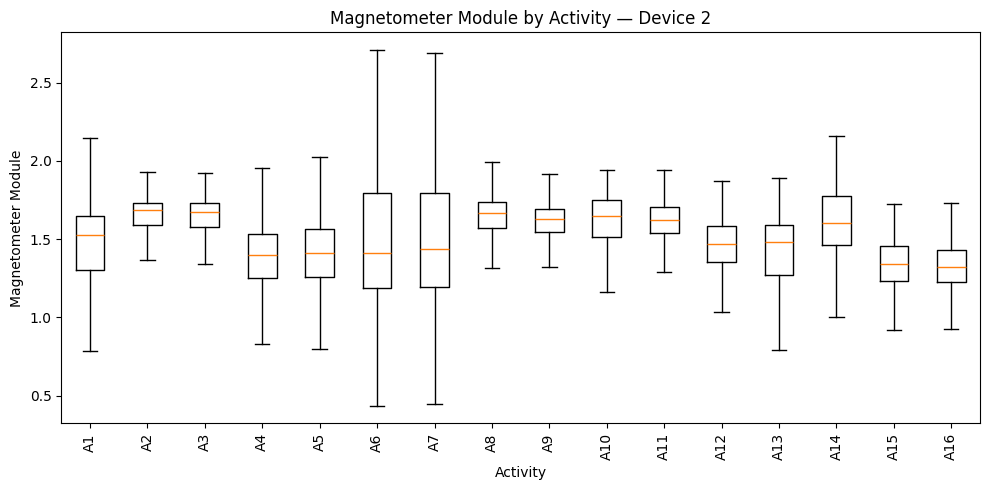

=== Outliers Z-Score - Pulso Direito (Device 2) ===


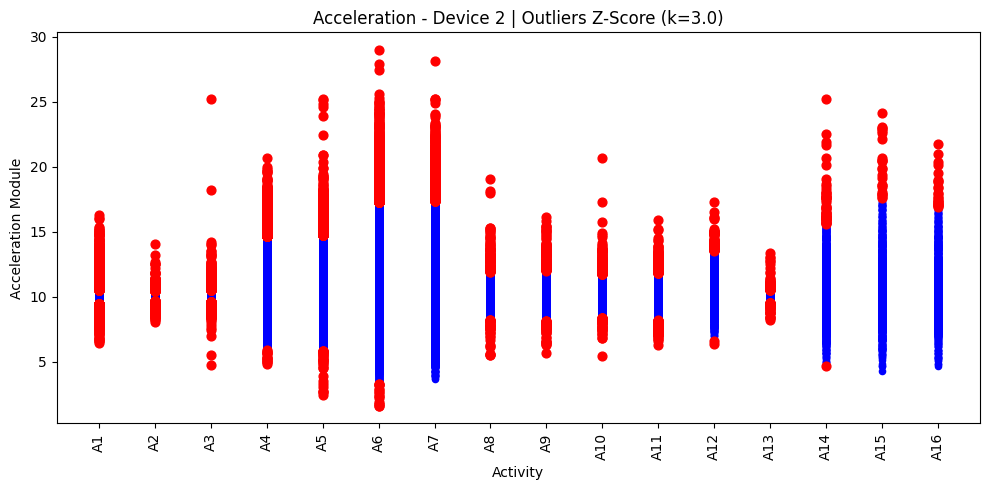

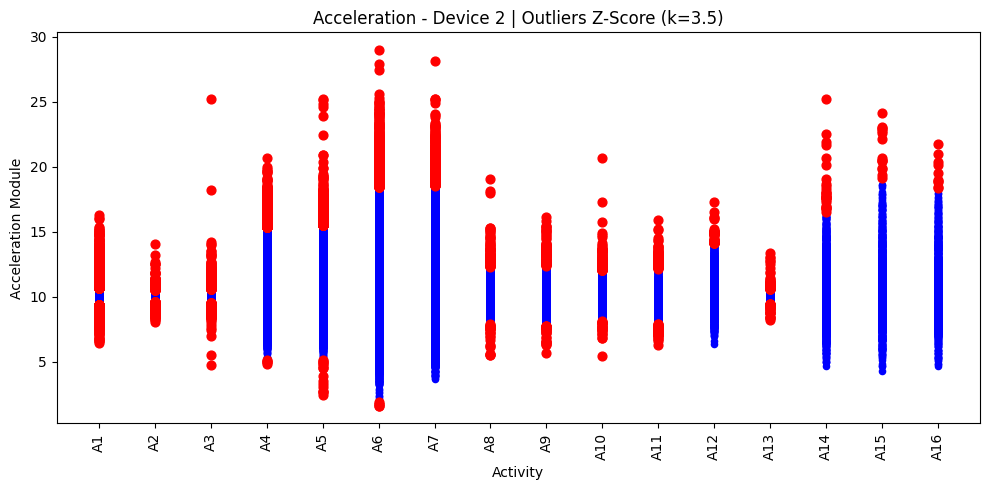

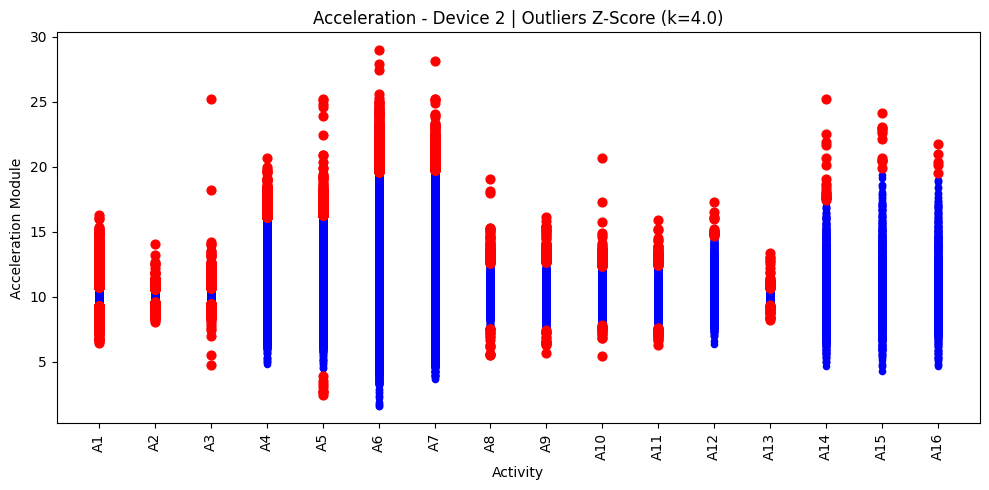

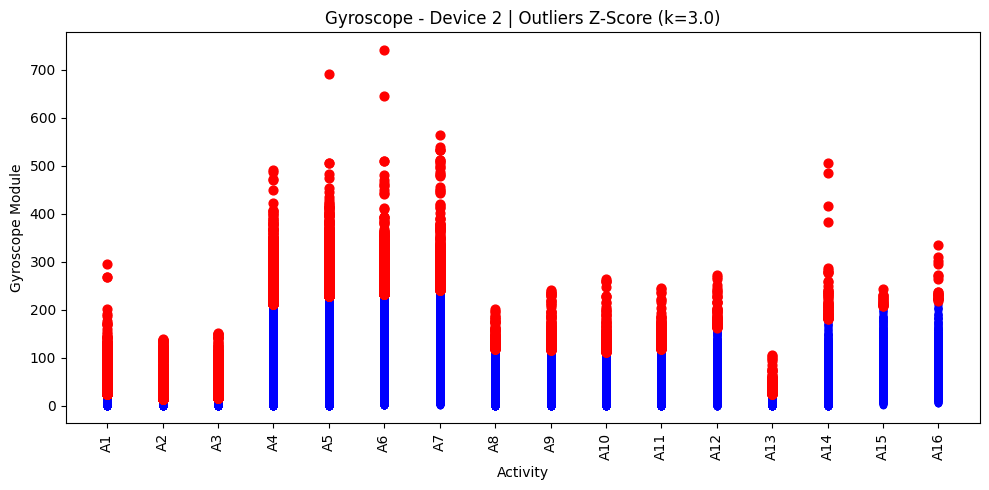

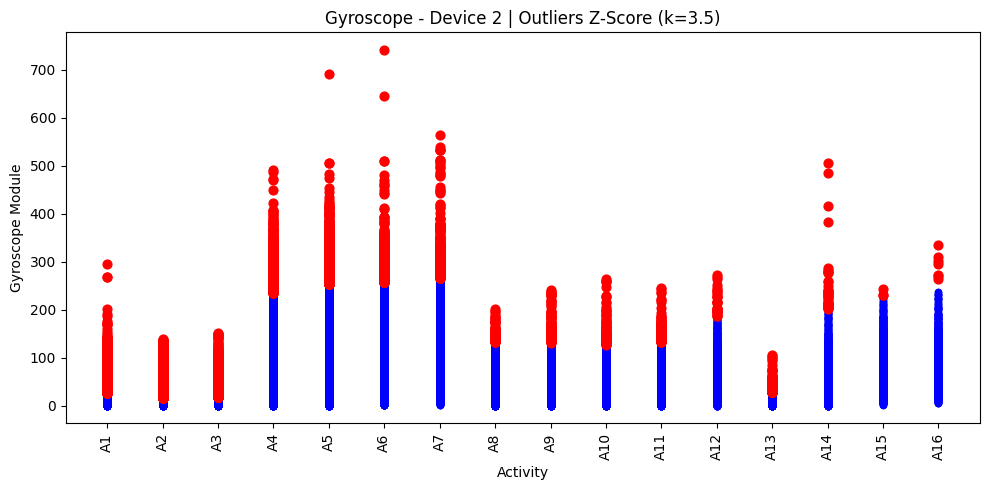

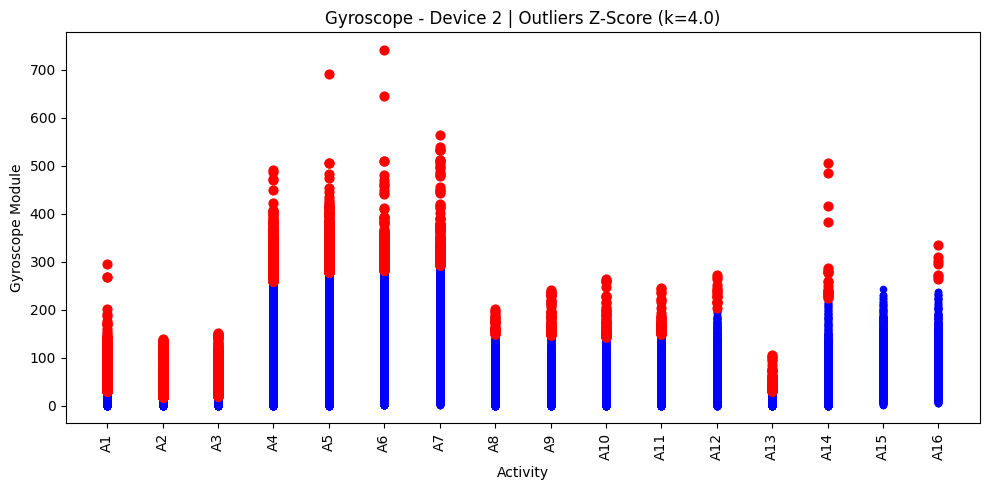

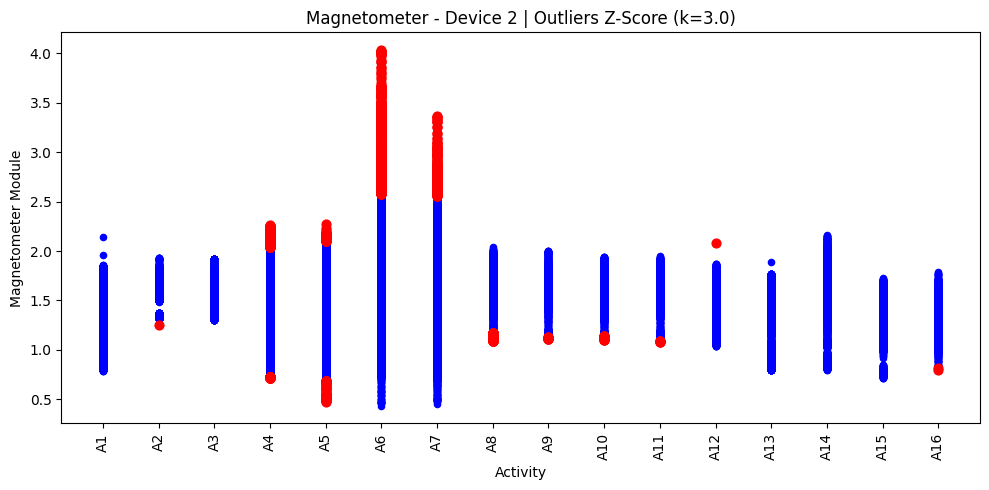

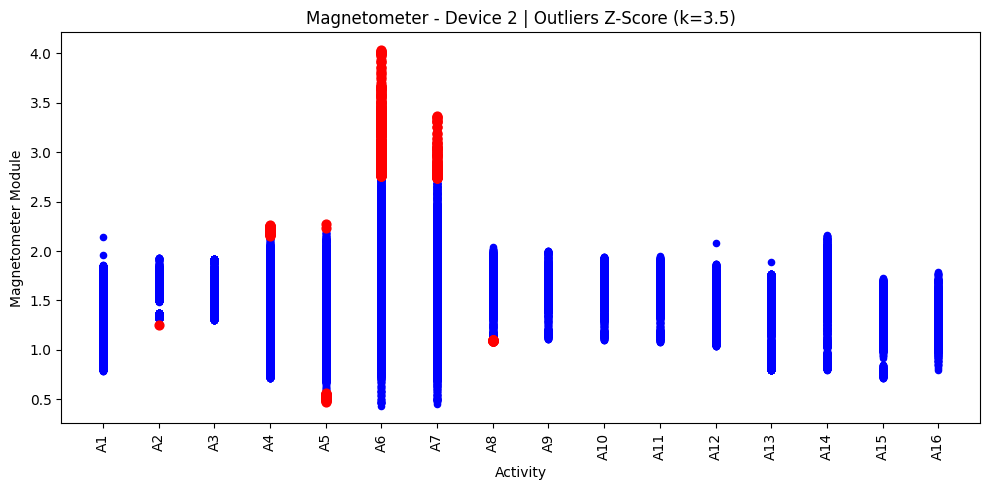

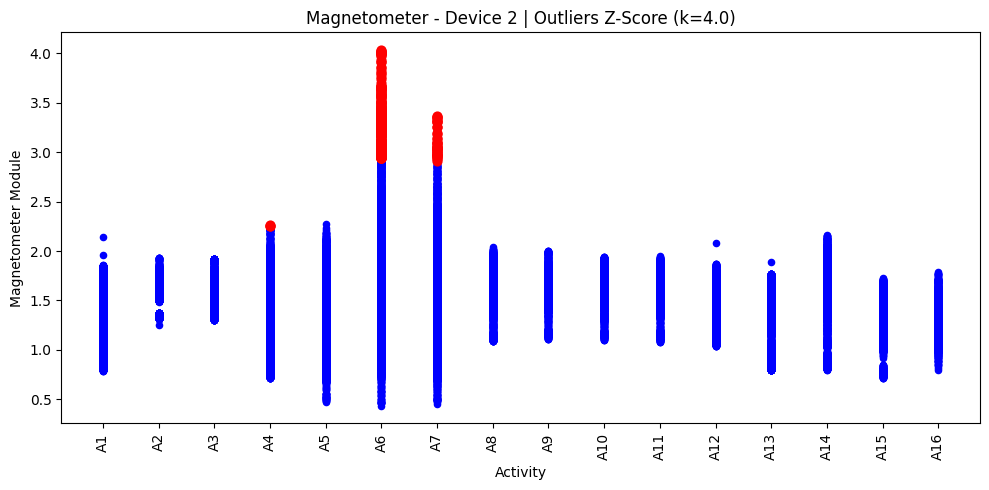

In [21]:
device_target = 2  # pulso direito
mask_device = data[:, 1].astype(int) == device_target
data_right_wrist = data[mask_device]

module_boxplots(data_right_wrist, sensor=1)  # Aceleração
module_boxplots(data_right_wrist, sensor=2)  # Giroscópio
module_boxplots(data_right_wrist, sensor=3)  # Magnetômetro

print("=== Outliers Z-Score - Pulso Direito (Device 2) ===")
plot_zscore_outliers(data_right_wrist, sensor=1, k_values=[3.0, 3.5, 4.0])
plot_zscore_outliers(data_right_wrist, sensor=2, k_values=[3.0, 3.5, 4.0])
plot_zscore_outliers(data_right_wrist, sensor=3, k_values=[3.0, 3.5, 4.0])

## Observações:
  ### Geral:
- A comparação revela que atividades com maior variabilidade visual nos gráficos 3.1 correspondem a maior número de outliers nas análises 3.4.
  
- O método Z-Score é eficaz para identificar desvios extremos, mas pode ser excessivamente sensível para dados de movimento humano

- Há medida que o k aumenta, menos filtra os outliers
  ### Aceleração:
  #### Módulo Aceleração:
  - Atividades com maior variabilidade na 3.1 (como 8, 9, 10, 11, 12) mostram dispersão significativa entre dispositivos nos valores do módulo, o que se reflete em mais outliers na 3.4
  
  - Atividades com menor variabilidade na 3.1 (como 1, 2, 3, 4), apresentam padrões mais consistentes entre dispositivos e menor amplitude de variação, resultando em menos outliers na 3.4
  
  - Dispositivos como o 3 e o 4 mostram padrões consistentemente diferentes dos outros em múltiplas atividades nas 3.1, contribuindo para os outliers nas 3.4
  #### Conclusão:
  - A análise 3.4 com Z-Score valida quantitativamente as observações qualitativas das figuras 3.1
  
  - Atividades que visualmente mostram maior inconsistência entre dispositivos nas 3.1 são corretamente identificadas como tendo mais outliers na 3.4
  ### Giroscópio:
  #### Módulo Giroscópio:
  - 6 a 12 apresentam picos extremos de outliers na 3.4 indicando movimentos rotacionais intensos e complexos;
  
  - 1 a 5 mostram baixíssima contagem de outliers (0-100), refletindo movimentos rotacionais básicos ou quase inexistentes;
  
  - A transição abrupta entre 5 e 6 revela uma mudança drástica no padrão de movimento, passando de estabilidade para rotatividade intensa;
  
  - 3 e 4 demonstram inconsistências marcantes nas atividades de maior intensidade rotacional (6-12), com trajetórias claramente divergentes dos outros dispositivos
  
  - A atividade 8 destaca-se pela ausência de dados do módulo na 3.1, sugerindo possíveis falhas de medição que se refletem na análise de outliers.
  #### Conclusão:
  - O giroscópio gera muito mais outliers que outros sensores devido à natureza dos movimentos rotacionais
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - A consistência visual observada nas figuras 3.1, onde todos os dispositivos mostram trajetórias sobrepostas e padrões uniformes, reflete-se diretamente nos valores mínimos de outliers nas análises 3.4
  - 1 a 16 apresentam valores consistentemente baixos de outliers nas análises 3.4, com todos os valores abaixo de 0.5, indicando alta estabilidade nas medições
  - Não se observam picos significativos de outliers em nenhuma atividade específica, ao contrário do verificado nos outros sensores
  #### Conclusão:
  - O magnetómetro estabelece um padrão de referência para qualidade de dados, contra o qual podem ser comparados o desempenho do giroscópio e acelerómetro



### Exercício 3.6
Elabore uma rotina que implemente o algoritmo k-means para n (valor de entrada) clusters.
#### Explicação da rotina implementada:
A rotina implementada para o algoritmo k-means segue os passos:
1. Inicialização: São selecionados `n_clusters` centróides iniciais aleatoriamente a partir dos dados.
   
2. Atribuição: Cada ponto no dataset data é iterativamente comparado com todos os centróides atuais. A distância Euclidiana (np.linalg.norm) é calculada entre o ponto e cada centróide. O ponto é então atribuído ao cluster cujo centróide se encontra mais próximo (menor distância).

3. Atualização: Os centróides são recalculados como a média dos pontos atribuídos a cada cluster. Para evitar erros, se um cluster ficar temporariamente vazio (nenhum ponto atribuído), o seu centróide é re-inicializado aleatoriamente a partir do dataset original.

4. Convergência: Os passos de atribuição e atualização são repetidos. O algoritmo termina quando:
   - A mudança na posição de todos os centróides entre uma iteração e a seguinte é muito pequena (inferior a uma tolerância `tol`).
   - O número de repetições atinge o limite `max_iter`.

In [38]:
def kmeans (data, n_clusters, max_iter=100, tol=1e-4):
    centroids= data[np.random.choice(data.shape[0], n_clusters, replace=False)]
    
    for i in range(max_iter):
        labels = np.zeros(data.shape[0], dtype=int)
        
        # Passo 1: atribui cada ponto ao cluster mais próximo
        for m, point in enumerate(data):
            min_dist = float('inf')
            for k in range(n_clusters):
                dist = np.linalg.norm(point - centroids[k])
                if dist < min_dist:
                    min_dist = dist
                    labels[m] = k
                    
        # Passo 2: atualiza centróides
        new_centroids = np.zeros_like(centroids)
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Se algum cluster ficar vazio, reposiciona aleatoriamente
                new_centroids[k] = data[np.random.choice(data.shape[0])]
        
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            break
        
        centroids = new_centroids
    
    return labels, centroids
            

## Exercício 3.7
Determine os outliers no dataset transformado usando o k-means. Experimente diferentes números de clusters e compare com os resultados obtidos em 3.4. Ilustre graficamente os resultados usando gráficos 3D para cada vetor
### Explicação da rotina implementada:
A função foi desenhada para aplicar o K-Means aos dados 3D de todos os sensores, uma atividade e device específico. Com o objetivo de identificar outliers com base na estrutura dos clusters formados e plotar os resultados em gráficos 3D.
A rotina segue os seguintes passos:
1. Filtragem dos dados: Começa por isolar os dados relevantes, filtrando o dataset pelo ID do dispositivo e, opcionalmente, por uma atividade específica.
   
2. Aplicação do K-Means: Para cada sensor (aceleração, giroscópio, magnetómetro), a função `kmeans` é chamada sobre os dados 3D para os agrupar em k_clusters.
   
3. Identificação de outliers:Para cada cluster, a função calcula o intervalo interquartil (IQR) do conjunto das suas distâncias. Um ponto é classificado como outlier se a asua distnância ao centróide for superior ao limite superior de Tukey (Q3 + 1.5 * IQR). Este método permite identificar pontos que estão significativamente afastados do centro do cluster.
   
4. Plotagem dos resultados: Finalmente, a função cria gráficos 3D para cada sensor, com clusters representados por cores diferentes para melhor visualizar os dados. Sendo que cada outlier é uma cruz da cor do cluster a que pertence e as centróides são representadas por estrelas pretas.


--- K-Means com k=3 clusters - Activity 7 - Device 2 ---


C:\Users\didia\AppData\Local\Temp\ipykernel_4312\3782777515.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', k_clusters)


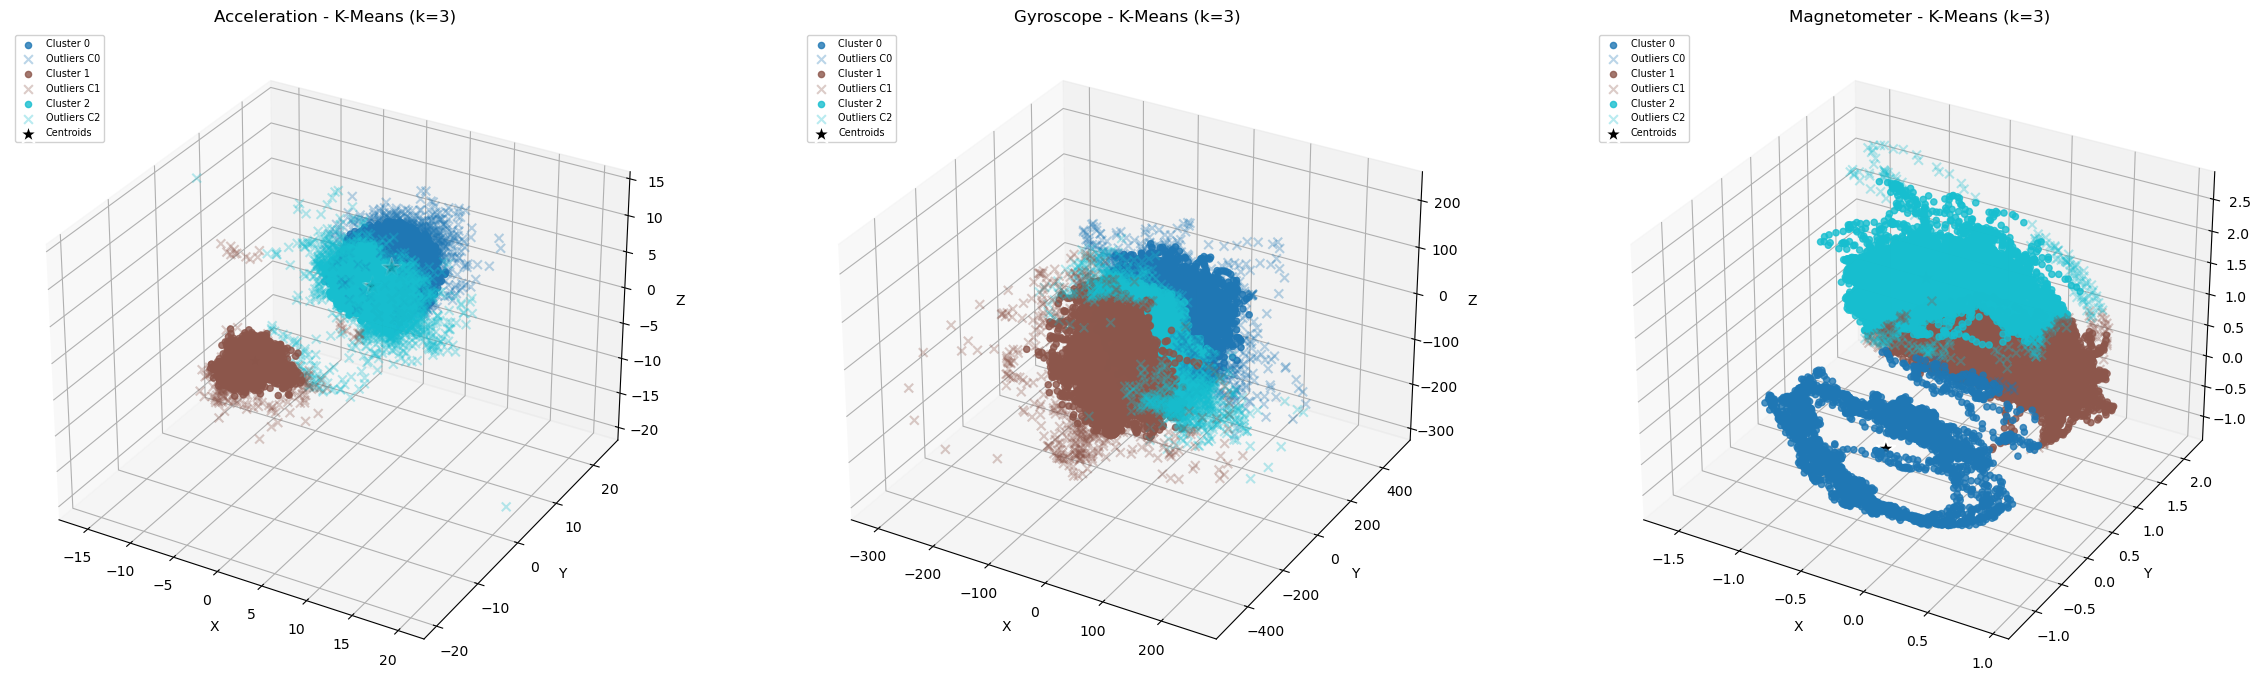


--- K-Means com k=3 clusters - Activity 2 - Device 2 ---


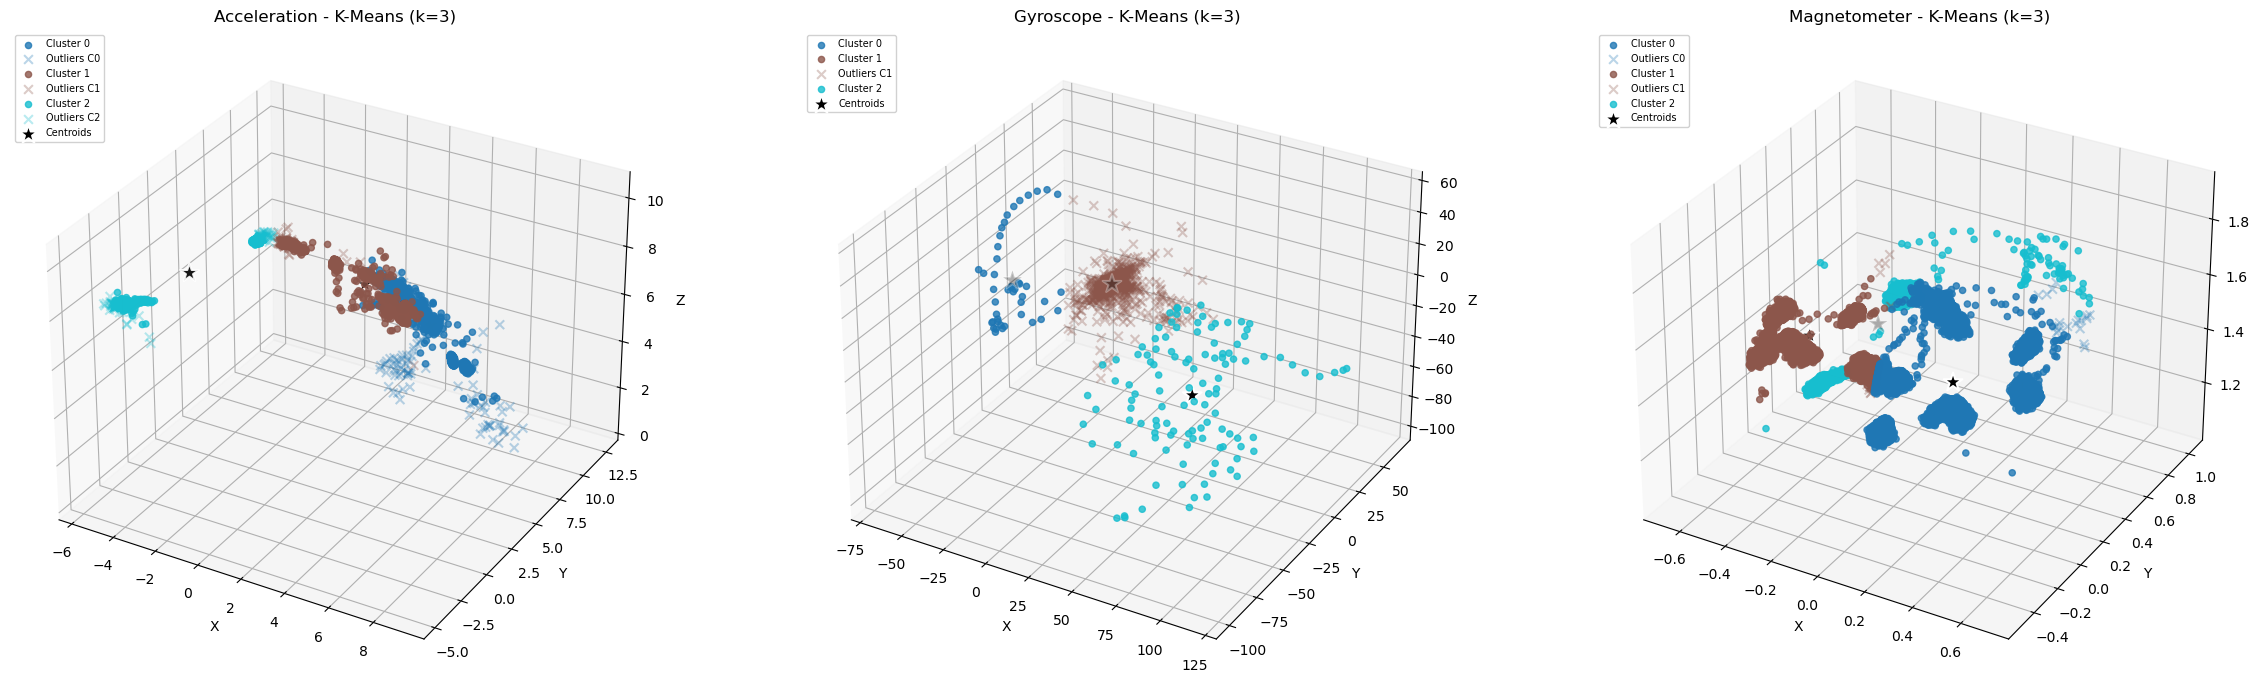


--- K-Means com k=3 clusters - Activity 7 - Device 5 ---


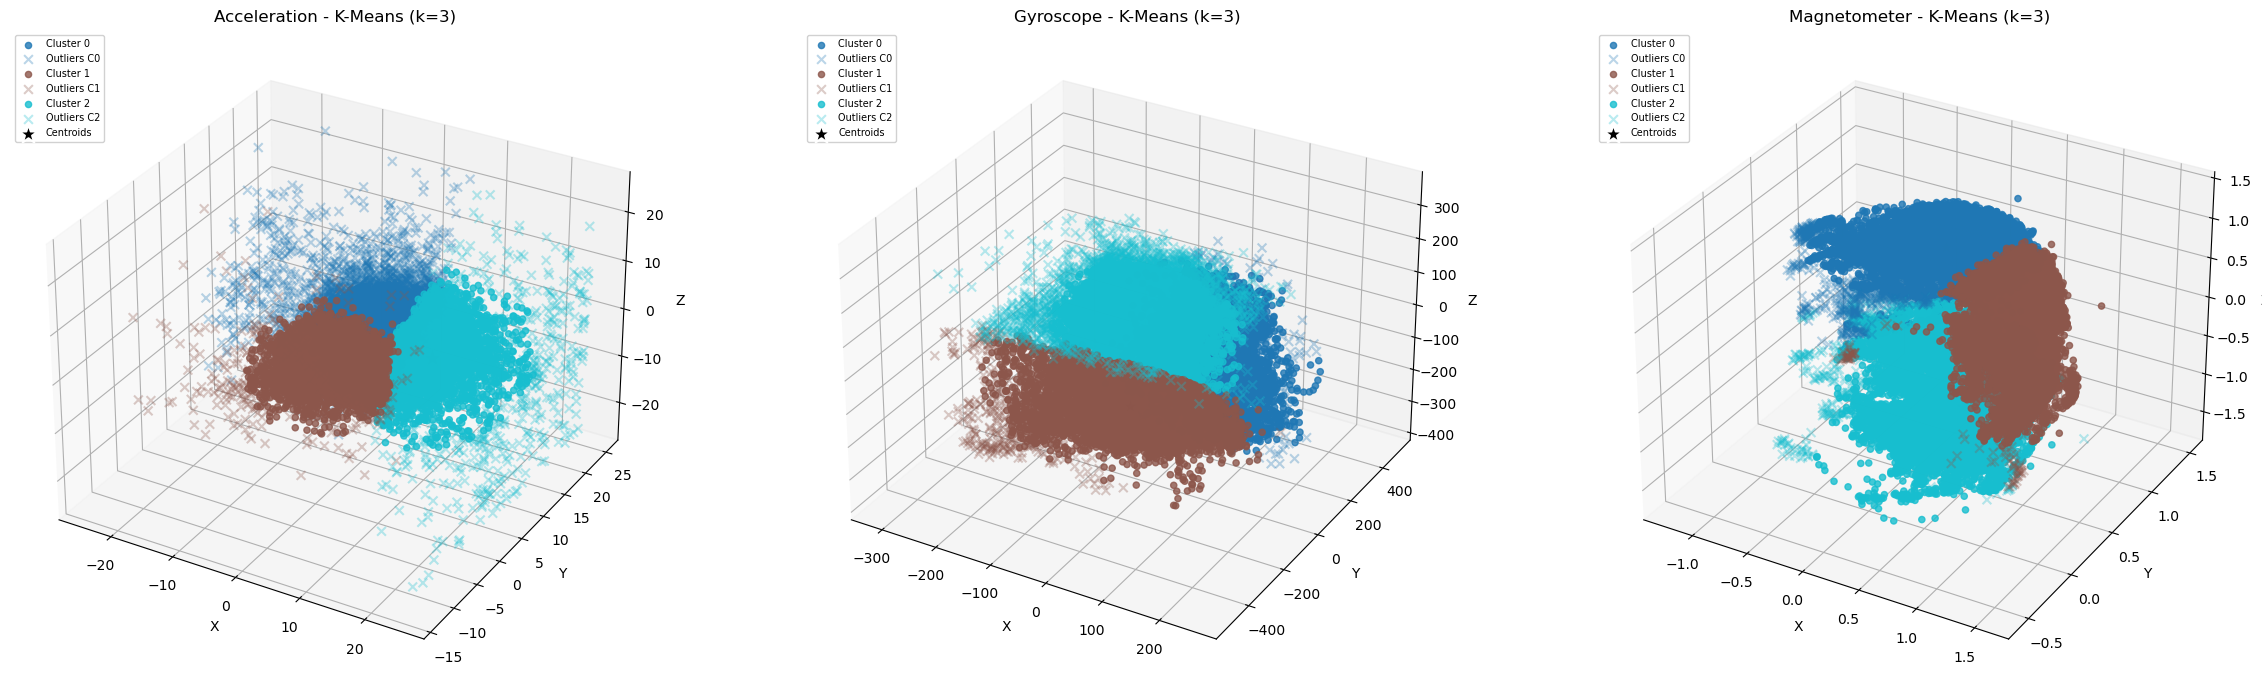

In [ ]:
def kmeans_outliers_3d_horizontal(data, k_clusters, device_id, activity_filter):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    # Cria figura com 1 linha, 3 colunas
    fig = plt.figure(figsize=(24, 7))
    
    for idx, sensor in enumerate(sensors):
        ax = fig.add_subplot(1, 3, idx+1, projection='3d')
        
        label = labels_map[sensor]
        c = cols_map[sensor]
        
        # Filtra por device
        device_data = data[data[:, 1] == device_id]
        
        device_data = device_data[device_data[:, 12] == activity_filter]
        
        sensor_data = device_data[:, c]
        
        # Aplica o k-means
        labels_kmeans, centroids = kmeans(sensor_data, k_clusters)
        colors = plt.cm.get_cmap('tab10', k_clusters)
        
        title = f'{label} - K-Means (k={k_clusters})'
        
        ax.set_title(title)
        
        # Plota cada cluster
        for cluster_id in range(k_clusters):
            cluster_points_idx = np.where(labels_kmeans == cluster_id)[0]
            if len(cluster_points_idx) == 0:
                continue
            
            cluster_points = sensor_data[cluster_points_idx]
            distances = np.linalg.norm(cluster_points - centroids[cluster_id], axis=1)
            
            Q1 = np.percentile(distances, 25)
            Q3 = np.percentile(distances, 75)
            IQR = Q3 - Q1
            upper_limit = Q3 + 1.5 * IQR
            
            
            outlier_mask = distances > upper_limit
            
            # Usar o bitwise NOT para obter os pontos normais através dos outliers
            normal_mask = ~outlier_mask
            
            normal_idx_local = cluster_points_idx[normal_mask]
            outlier_idx_local = cluster_points_idx[outlier_mask]
            
            cluster_color = colors(cluster_id)
            
            # Pontos normais
            if len(normal_idx_local) > 0:
                ax.scatter(sensor_data[normal_idx_local, 0],
                           sensor_data[normal_idx_local, 1],
                           sensor_data[normal_idx_local, 2],
                           color=cluster_color, s=20, alpha=0.8,
                           label=f'Cluster {cluster_id}')
            
            # Outliers
            if len(outlier_idx_local) > 0:
                ax.scatter(sensor_data[outlier_idx_local, 0],
                           sensor_data[outlier_idx_local, 1],
                           sensor_data[outlier_idx_local, 2],
                           color=cluster_color, s=40, alpha=0.3, marker='x',
                           label=f'Outliers C{cluster_id}')
        
        # Centróides
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   color='black', s=200, marker='*', edgecolors='white', linewidths=1.5,
                   label='Centroids', zorder=10)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Execução
k_val = 3

print(f"\n--- K-Means com k={k_val} clusters - Activity 7 - Device 2 ---")
kmeans_outliers_3d_horizontal(data, k_clusters=k_val, device_id=2, activity_filter=7)
print(f"\n--- K-Means com k={k_val} clusters - Activity 2 - Device 2 ---")
kmeans_outliers_3d_horizontal(data, k_clusters=k_val, device_id=2, activity_filter=2)
print(f"\n--- K-Means com k={k_val} clusters - Activity 7 - Device 5 ---")
kmeans_outliers_3d_horizontal(data, k_clusters=k_val, device_id=5, activity_filter=7)

### Observações
Para analisar os resultados do K-Means optámos por analisar três exemplos. Para todos os casos, utilizámos k = 3 clusters, um valor que melhor parece capturar a estrutura natural dos dados na generalidade.
#### Análise do primeiro exemplo: Atividade 7 (Climb Stair (up/down) and talk) e Dispositivo 2 (Pulso Direito)
##### Tendência Geral
Este caso demonstra a capacidade do K-Means de encontrar estrutura em movimentos complexos.
##### Padrões Observados
- **Aceleração**: O gráfico mostra três clusters de dados muito distintos, o que significa que o k-means conseguiu segmentar estes três sub-movimentos de forma eficaz. Isto sugere que o movimento do pulso durante esta atividade é composto por, pelo menos, três fases ou sub-movimentos distintos.
  
- **Giroscópio**: O padrão é mais caótico. Os três clusters estão muito sobrepostos, formando uma única nuvem de dados central. Isto indica que, embora tenham sido encontras 3 tendências centrais, o movimento rotacional do pulso é mais contínuo e menos segmentado que o da aceleração.
  
- **Magnetómetro**: Este sensor revela o padrão mais interessante. Os dados formam três arcos distintos. Isto pode sugerir que o pulso segue 3 trajetórias específicas no campo magnético.

#### Análise do segundo exemplo: Atividade 2 (Sit) e Dispositivo 2 (Pulso Direito)
##### Tendência Geral
Este caso serve como contraste direto ao primeiro exemplo, ilustrando como o K-Means lida com movimentos estáticos. No entanto, mesmo sendo estático o algoritmo foi capaz de detetar micro-movimentos e posições subtis.
##### Padrões Observados
Neste exemplo, o K-Means demonstrou ser capaz de identificar padrões mesmo nos dados mais subtis. Para uma atividade estática como estar sentado, ele não agrupa movimentos, mas sim micro-posições.
- **Aceleração**: É possível observar uma clara falta de variância. Os dados formam uma única nuvem de pontos muito compacta. A proximidade dos três centróides confirma que estão, na prática, a descrever o mesmo ponto central de repouso, refletindo a natureza estática da atividade.
  
- **Giroscópio**: Neste sensor, é possível observar uma maior variância. O cluster C0 é uma nuvem pequena e única, com muitos outliers. Isto pode sugerir que o pulso está maior parte do tempo nessa posição de repouso e que um pequeno movimento ou rotação é suficiente para gerar um outlier. Pr outro lado, os clusters C1 e C2 são conjuntos de pontos mais espalhados, o que pode sugerir movimentos de reajuste que o K-Means agrupou como sendo distintos do estado de repouso do C0.
  
- **Magnetómetro**: O cluster C0, que se apresenta dividido em 5/6 sub-nuvens, demonstra um conjunto de orientações distintas e estáveis, com poucos outliers. O cluster C1 é semelhante, mas com um maior número de outliers, sugerindo que pode representar uma orientação mais "ativa" ou a transição entre posições. Finalmente, o cluster C2 é pequeno e denso, com poucos outliers, representando uma terceira orientação bastante estável.

#### Análise do terceiro exemplo: Atividade 7 (Climb Stair (up/down) and talk) e Dispositivo 5 (Perna inferior)
##### Tendência Geral
Este exemplo é uma comparação com o primeiro exemplo, mas agora para um device diferente (perna inferior).
##### Padrões Observados
- **Comparação com o primeiro exemplo**: A estrutura dos clusters na perna inferior não tem nada que ver com a do pulso direito.
  
- **Aceleração e Giroscópio**: Os clusters são muito maiores, mais dispersos e significativamente mais sobrepostos do que os do pulso. Isto reflete a física do movimento: a perna tem uma amplitude de movimento muito superior à do pulso. A sobreposição sugere que as fases do movimento são contínuas.
  
- **Magnetómetro**: Tal como no pulso, são formados clusters curvos mas aqui são maiores e mais sobrepostos, ocupando um maior volume de espaço.

#### Conclusão Geral
Estes três exemplos demonstram que o K-Means é uma ferramenta eficaz:
1. Consegues identificar sub-movimentos mesmo em atividades complexas. (Exemplo 1)
   
2. Distingue claramente entre movimentos estáticos e dinâmicos. (Exemplo 1 vs Exemplo 2)
   
3. Confirma que a localização do sensor é um fator crítico, pois a mesma atividade produz padrões de cluster muito diferentes em partes do corpo distintas. (Exemplos 1 vs Exemplo 3)


#### Comparação entre Z-Score e K-Means (Exercício 3.7 vs Exercício 3.4)
##### Natureza da deteção
- O Z-Score encontra pontos com magnitude extrema. Um ponto com módulo 40 é um outlier, independentemente de ter vindo do vetor (40, 0, 0) ou (23.1, 23.1, 23.1).
  
- O K-Means + IQR, encontra pontos estruturalmente anómalos. Um ponto pode ter uma magnitude alta, mas se estiver dentro de um cluster de outros pontos com magnitudes e direções semelhantes, não será considerado um outlier.
##### Quantidade e Qualidade dos outliers
- O Z-Score tende a marcar uma enorme percentagem dos dados como outliers em atividades dinâmicas. É provável que esteja a gerar muitos falsos positivos, marcando picos normais do movimento como anómalos.
  
- O K-Means é mais robusto e eficaz. Ao encontrar primeiro os clusters, ele define o que é normal com base na forma 3D do movimento. Os outliers identificados são muito menos numerosos e é mais provável que representem verdadeiras anomalias.
### Conclusão
O método K-Means aplicado aos dados 3D, com a subsequente análise do IQR sobre as distâncias, é uma abordagem mais robusta para este problema, pois utiliza o contexto da estrutura do movimento para definir o que é anómalo. O Z-Score, sendo um método univariado aplicado ao módulo, perde todo esse contexto 3D e acaba por classificar incorretamente picos de alta magnitude (mas válidos) como outliers.

### Exercício 3.7.1 (Bónus)
Poderá realizar um estudo análogo usando o algoritmo DBSCAN (sugere-se que recorra à [biblioteca sklearn2](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN))

#### DBSCAN
Como alternativa ao K-Means, começamos um estudo utilizando o algoritmo DBSCAN (Density-based spatial clustering of applications with noise).

Ao contrário do K-Means, que particiona os dados em k clusters pré-definidos, o DBSCAN é um algoritmo que identifica clusters com base na proximidade dos pontos. As suas principais vantagens são a capacidade de encontrar clusters com formas arbitrárias e não requerer a especificação prévia do número de clusters.

O algoritmo funciona com base em dois parâmetros principais:
- `eps`: O raio de vizinhança;
- `min_samples`: O número mínimo de pontos que devem existir dentro do raio `eps` de um ponto para que ele seja considerado um ponto central.

Com base nestes parâmetros, o DBSCAN classifica os pontos em três categorias:
- Ponto central: Um ponto que possui pelo menos min_samples vizinhos dentro do seu raio eps. Estes pontos formam o centro denso de um cluster.
- Ponto de Fronteira: Um ponto que não é um ponto central (tem menos de min_samples vizinhos), mas que está ao alcance (dentro do raio eps) de, pelo menos, um ponto central. Estes pontos formam a "periferia" de um cluster.
- Ponto de Ruído (Outlier): Um ponto que não é um ponto central e também não está ao alcance de nenhum ponto central. Estes são os pontos isolados, que o algoritmo considera outliers.

Um cluster é formado por um conjunto de Pontos Centrais que se conseguem "alcançar" uns aos outros, mais todos os Pontos de Fronteira associados a eles.

In [ ]:
def dbscan_outliers_3d(data, eps, min_samples, device_id=2, activity_filter=None):
    sensors = [1, 2, 3]
    labels_map = {1: 'Acceleration', 2: 'Gyroscope', 3: 'Magnetometer'}
    cols_map = {1: (2, 3, 4), 2: (5, 6, 7), 3: (8, 9, 10)}
    
    n_cols = 3
    n_rows = len(eps)

    fig = plt.figure(figsize=(6 * n_cols , 5 * n_rows))
    for row_idx, (eps_value, min_samples_value) in enumerate(zip(eps, min_samples)):
        for col_idx, sensor in enumerate(sensors):
            ax = fig.add_subplot(n_rows, n_cols, row_idx * n_cols + col_idx + 1, projection='3d')
            label = labels_map[sensor]
            c = cols_map[sensor]

            # Filtrar device e atividade
            device_data = data[data[:, 1] == device_id]
            if activity_filter is not None:
                device_data = device_data[device_data[:, 12] == activity_filter]
            sensor_data = device_data[:, c]

            if (sensor_data.shape[0] == 0):
                ax.set_title(f"{label} - No data available")
                continue
            db = DBSCAN(eps=eps_value, min_samples=min_samples_value)
            labels = db.fit_predict(sensor_data)

            # Outliers
            outliers_index = np.where(labels == -1)[0]
            unique_cluster_labels = set(labels) - {-1}
            n_clusters = len(unique_cluster_labels)
            n_noise = len(outliers_index)
            print("Encontrados %d clusters e %d outliers no %s" % (n_clusters, n_noise, label))

            title = f"{label} - DBSCAN (eps={eps}, min_samples={min_samples})"
            if activity_filter is not None:
                title += f" - Activity {int(activity_filter)}"
            ax.set_title(title)

            colors = cm.get_cmap('tab10', n_clusters)

            if n_clusters > 0:
                for cluster_id in unique_cluster_labels:
                    cluster_points_idx = np.where(labels == cluster_id)[0]
                    cluster_color = colors(cluster_id)

                    ax.scatter(sensor_data[cluster_points_idx, 0],
                               sensor_data[cluster_points_idx, 1],
                               sensor_data[cluster_points_idx, 2],
                               color=cluster_color, s=20, alpha=0.8,
                               label=f'Cluster {cluster_id}')
            if n_noise > 0:
                ax.scatter(sensor_data[outliers_index, 0],
                           sensor_data[outliers_index, 1],
                           sensor_data[outliers_index, 2],
                           color='red', s=40, alpha=0.3, marker='x',
                           label='Outliers')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Execução
eps_values = [1.5, 5.0, 0.02]
min_samples_values = [5, 10, 3]
dbscan_outliers_3d(data, eps=eps_values, min_samples=min_samples_values, device_id=2, activity_filter=7)

Encontrados 7 clusters e 183 outliers no Acceleration


C:\Users\didia\AppData\Local\Temp\ipykernel_4312\581735877.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 29 clusters e 43638 outliers no Gyroscope


C:\Users\didia\AppData\Local\Temp\ipykernel_4312\581735877.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


Encontrados 1 clusters e 0 outliers no Magnetometer


C:\Users\didia\AppData\Local\Temp\ipykernel_4312\581735877.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


### Observações
Após utilizar o DBSCAN com os parametros eps=1.5 e min_samples=5, ficou clara a sensibilidade do algoritmo a estes parâmetros.
- Com estes parâmetros, o DBSCAN, não funciona bem para todos os sensores:
  
    - **Aceleração(7 clusters, 183 outliers)**: Foi o resultado mais razoável. O número de clusters encontrados pode refletir a atividade realizada e o número de outliers não é zero mas também não é excessivo.
  
    - **Giroscópio(29 clusters, 43638 outliers)**: O resultado não é satisfatório. O número de outliers é extremamente elevado, indicando que o eps é demasiado pequeno para a densidade dos dados. O número elevado de clusters também sugere que o eps é pequeno, fazendo com que pequenas densidades sejam consideradas clusters distintos.

    - **Magnetómetro(1 cluster, 0 outliers)**: Este resultado pode indicar o oposto. Parâmetros demasiado grandes, que fizeram com que todos os pontos fossem agrupados num único cluster ou os dados são excecionalmente uniformes e sem pontos ruidosos.
### Ajuste dos Parâmetros
O próximo passo foi tentar ajustar os parâmetros eps e min_samples para obtermos um resultado adequado para cada sensor. Mas sem grande sucesso, uma vez que o meu computador (Bernardo) não consegue lidar com o algoritmo o que dificultou a experimentação.
- **Aceleração**: eps=1.5, min_samples=5
  
- **Giroscópio**: eps=5.0, min_samples=10
  
- **Magnetómetro**: eps=0.5, min_samples=3

## Exercício 4
Extração de informação característica: o objetivo será comprimir o espaço do problema,
extraindo informação característica discriminante que permita implementar soluções
eficazes do problema de classificação.

### Exercício 4.1
Usando as variáveis aplicadas na alínea 3.1, determine a significância
estatística dos seus valores médios nas diferentes atividades. Observe que
poderá aferir a normalidade da distribuição usando, por exemplo, o teste Kolmogorov-Smirnov (ver documentação do SciPy). Para rever a escolha de
testes estatísticos sugere-se a referência. Comente

In [26]:
def module_significance(data, sensor, alpha=0.05):
    if sensor == 1:
        c = (2,3,4)
        label = 'Acceleration'
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 1, 2 ou 3")

    mod = np.sqrt((data[:, c]**2).sum(axis=1))
    activities = data[:, 12].astype(int)
    unique_activities = np.unique(activities)
    devices = data[:, 1].astype(int)
    unique_devices = np.unique(devices)
    
    
    print(f"Sensor: {label}")

    for dev in unique_devices:
        # Máscara do dispositivo atual
        mask_dev = (devices == dev)
        mod_dev = mod[mask_dev]
        activities_dev = activities[mask_dev]

        unique_activities_dev = np.unique(activities_dev)

        # Teste de normalidade
        all_normal = True
        for act in unique_activities:
            sample = mod_dev[activities_dev == act]
            mean_sample = np.mean(sample)
            std_sample = np.std(sample)

            # Kolmogorov–Smirnov
            stat_ks, p_ks = kstest(sample, 'norm', args=(mean_sample, std_sample))
            if p_ks <= alpha:
                all_normal = False

        # Preparar amostras por atividade
        samples = [mod_dev[activities_dev == act] for act in unique_activities_dev]

        # Escolher o teste estatístico
        if all_normal:
            stat_anova, p_value = f_oneway(*samples)
            test_name = "ANOVA (paramétrico)"
        else:
            stat_kruskal, p_value = kruskal(*samples)
            test_name = "Kruskal–Wallis (não-paramétrico)"

        # Mostrar resultado
        print(f" device{dev} — {test_name}")
        print(f"p-value = {p_value:.4e}")
        if p_value <= alpha:
            print("Rejeito H0")
        else:
            print("Aceito H0")

In [28]:
module_significance(data, sensor=1) 

Sensor: Acceleration
 device1 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device2 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device3 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device4 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device5 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0


In [29]:
module_significance(data, sensor=2)

Sensor: Gyroscope
 device1 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device2 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device3 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device4 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device5 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0


In [30]:
module_significance(data, sensor=3)

Sensor: Magnetometer
 device1 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device2 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device3 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device4 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0
 device5 — Kruskal–Wallis (não-paramétrico)
p-value = 0.0000e+00
Rejeito H0


### Observações
#### Geral:

- Foram analisados os módulos dos sensores para todas as atividades, comparando os valores médios entre elas
  
- Para decidir o teste apropriado, foi verificada a normalidade de cada atividade usando Kolmogorov–Smirnov e Shapiro–Wilk. Nenhuma das atividades apresentou distribuição normal, justificando o uso do teste não-paramétrico Kruskal–Wallis.
  
- Caso o h0 for aceite significa que não há diferenças significativas entre os valores médios nas atividades, e se h0 for rejeitada significa que há diferenças significativas
  
- No início também usamos o Shapiro-Wilk no entanto percebemos que esse teste não é o mais adequado tendo em conta a quantidade de dados que temos no dataset
  
- Os p-values obtidos foram praticamente zero para todos os sensores, indicando que as diferenças observadas entre atividades não ocorrem por acaso.

##### Explicação dos p-value=0
- Pode significar que temos amostras muito grandes ou que os valores médios entre atividades são altamente significativas e improváveis de ocorrer por acaso.

##### Acceleration:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Há diferenças estatisticamente significativas nos valores médios do módulo de aceleração entre as atividades. Atividades dinâmicas apresentam valores médios mais elevados que as estáticas, refletindo variações reais de movimento.

##### Gyroscope:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
Os valores médios do giroscópio diferem significativamente entre as atividades. Atividades sem movimento apresentam módulo próximo de zero, enquanto atividades com movimento apresentam valores mais elevados, captando claramente a rotação do corpo.

##### Magnetometer:
Teste de Significância:
- Kruskal–Wallis: p-value ≈ 0
- Decisão: Rejeita-se H₀.
##### Observação: 
As diferenças nos valores médios do magnetómetro também são estatisticamente significativas. Contudo, a distinção entre atividades não é tão nítida quanto nos outros sensores. É possível que outliers relacionados com interferências magnéticas (ex.: estruturas metálicas) influenciem os resultados.

#### Conclusão:
- Todos os sensores apresentam diferenças significativas entre as atividades, confirmando que os valores médios dos módulos dos sensores podem ser usados para diferenciar atividades humanas.
  
- O Kruskal–Wallis mostrou-se adequado devido à ausência de normalidade nos dados.
  
- Em termos práticos, aceleração e giroscópio são mais discriminativos entre atividades, enquanto o magnetómetro pode ser útil em situações específicas, como detetar ambientes com interferência magnética ou movimentos de escada.

### Exercício 4.2

Desenvolva as rotinas necessárias à extração do feature set temporal e 
espectral sugerido no artigo4. Para o efeito deverá: 
- Ler o artigo e identificar o conjunto de features temporais e espectrais 
identificadas por estes autores.

- Considere apenas janelas temporais (sliding windows) de 5 segundos, 
com overlap de 50% para segmentar os dados para a extração de 
features. Se um segmento cobrir mais do que uma atividade, descarte 
esse segmento. Ver em particular a Figura 2 e Tabela 1 do artigo1.

- Para cada feature deverá elaborar uma rotina para a respetiva extração.
  
- Usando as rotinas elaboradas no item anterior, deverá escrever o código 
necessário para extrair o vetor de features em cada instante.

### Explicação da rotina implementada
A rotina implementada tem como objetivo segmentar o dataset e extrair o conjunto de features temporais e espectrais sugerido no artigo de referência.

Primeiramente, os dados são divididos em janelas temporais de 5 segundos com overlap de 50%, de forma independente para cada pessoa e dispositivo. Apenas são consideradas as janelas que contêm uma única atividade, garantindo a homogeneidade dos segmentos. Mesmo as últimas janelas incompletas são incluídas, de modo a minimizar a perda de informação.

Em seguida, é realizada a extração das features temporais e espectrais para cada janela. As features temporais incluem medidas estatísticas e de variação calculadas sobre os sinais dos sensores, enquanto as features espectrais são obtidas através da Transformada de Fourier, caracterizando o conteúdo em frequência.

Finalmente, obtém-se uma matriz de features (X) e um vetor de labels (y), onde cada linha de X representa o vetor de características correspondente a uma janela de 5 segundos de uma única atividade. Este feature set serve de base para etapas posteriores de seleção de features e classificação de atividades.

In [ ]:
def create_windows(data, fs, window_length=5.0, overlap=0.5):
    n_samples_window = int(fs * window_length)
    step = int(n_samples_window * (1 - overlap))
    windows = []

    pessoas = np.unique(data[:, 0])

    for pessoa in pessoas:
        pessoa_data = data[data[:, 0] == pessoa]
        dispositivos = np.unique(pessoa_data[:, 1])

        for dispositivo in dispositivos:
            sub_data = pessoa_data[pessoa_data[:, 1] == dispositivo]
            n_samples = len(sub_data)

            # sliding windows normais
            for start_idx in range(0, n_samples - n_samples_window + 1, step):
                end_idx = start_idx + n_samples_window
                window_data = sub_data[start_idx:end_idx]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

            # incluir última janela incompleta
            if n_samples % step != 0:
                start_idx = n_samples - n_samples_window
                if start_idx < 0:
                    start_idx = 0
                window_data = sub_data[start_idx:]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

    return windows


In [4]:
windows = create_windows(data, fs=51.2, window_length=5.0, overlap=0.5)


In [5]:
unique_labels = np.unique([w[0, 12] for w in windows])
print("Labels representadas:", unique_labels)

Labels representadas: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


### Nota sobre as features a extrair: 

1. Features temporais por coluna (para colunas 2 a 10)

Para cada coluna:

-       Média; 
-       Mediana;
-       STD;
-       Variância;
-       Raiz quadrada da média;
-       Derivada média;
-       Skewness;
-       Kurtosis;
-       IQR;
-       Zero Crossing Rate;
-       Mean Crossing Rate;

Colunas:
-       2,3,4 → ax, ay, az
-       5,6,7 → gx, gy, gz
-       8,9,10 → mx, my, mz

11 features × 9 colunas = 99 features temporais por coluna.

Pairwise correlation dentro de cada sensor:
-       Acelerómetro (ax, ay, az): Acc XY, Acc XZ, Acc YZ → 3 valores
-       Giroscópio (gx, gy, gz): Gyr XY, Gyr XZ, Gyr YZ → 3 valores
-       Magnetómetro (mx, my, mz): Mag XY, Mag XZ, Mag YZ → 3 valores
-       Total: 9 features de correlação.

Spectral features por coluna:
-       Spectral Entropy - 9 valores
-       Dominant Frequency - 9 valores
-       Energy - 9 valores
-       Total spectral: 27 features.

Movement intensity (ax, ay, az):
-       MI mean
-       MI variance 

SMA (ax, ay, az):
-       SMA

EVA (top 2 eigenvalues):
-       Accelerometer → EVA_Acc_1, EVA_Acc_2 - 2 valores

Correlation Acceleration vs Heading:
-       Corr_Acc_Gravity_Heading 

Averaged Velocity along Heading & Gravity:
-       Heading: AvgVelHeading, AvgVelHeadingX → 2 valores
-       Gravity: AvgVelGravity, AvgVelGravityX → 2 valores
-       Total: 4 valores

Averaged Rotation Angle along Gravity:
-       AvgRotAngleGravity 

Averaged Acceleration Energy & Rotation Energy (spectral):
-       AvgAccEnergy;
-       AvgRotEnergy 

In [29]:
nomes_features = [
'ax_mean','ax_median','ax_std','ax_var','ax_rms','ax_mean_derivative','ax_skewness','ax_kurtosis','ax_iqr','ax_zcr','ax_mcr',
'ay_mean','ay_median','ay_std','ay_var','ay_rms','ay_mean_derivative','ay_skewness','ay_kurtosis','ay_iqr','ay_zcr','ay_mcr',
'az_mean','az_median','az_std','az_var','az_rms','az_mean_derivative','az_skewness','az_kurtosis','az_iqr','az_zcr','az_mcr',
'gx_mean','gx_median','gx_std','gx_var','gx_rms','gx_mean_derivative','gx_skewness','gx_kurtosis','gx_iqr','gx_zcr','gx_mcr',
'gy_mean','gy_median','gy_std','gy_var','gy_rms','gy_mean_derivative','gy_skewness','gy_kurtosis','gy_iqr','gy_zcr','gy_mcr',
'gz_mean','gz_median','gz_std','gz_var','gz_rms','gz_mean_derivative','gz_skewness','gz_kurtosis','gz_iqr','gz_zcr','gz_mcr',
'mx_mean','mx_median','mx_std','mx_var','mx_rms','mx_mean_derivative','mx_skewness','mx_kurtosis','mx_iqr','mx_zcr','mx_mcr',
'my_mean','my_median','my_std','my_var','my_rms','my_mean_derivative','my_skewness','my_kurtosis','my_iqr','my_zcr','my_mcr',
'mz_mean','mz_median','mz_std','mz_var','mz_rms','mz_mean_derivative','mz_skewness','mz_kurtosis','mz_iqr','mz_zcr','mz_mcr',
'Corr_Acc_XY','Corr_Acc_XZ','Corr_Acc_YZ',
'Corr_Gyr_XY','Corr_Gyr_XZ','Corr_Gyr_YZ',
'Corr_Mag_XY','Corr_Mag_XZ','Corr_Mag_YZ',
'ax_SpecEntropy','ax_DominantFreq','ax_Energy',
'ay_SpecEntropy','ay_DominantFreq','ay_Energy',
'az_SpecEntropy','az_DominantFreq','az_Energy',
'gx_SpecEntropy','gx_DominantFreq','gx_Energy',
'gy_SpecEntropy','gy_DominantFreq','gy_Energy',
'gz_SpecEntropy','gz_DominantFreq','gz_Energy',
'mx_SpecEntropy','mx_DominantFreq','mx_Energy',
'my_SpecEntropy','my_DominantFreq','my_Energy',
'mz_SpecEntropy','mz_DominantFreq','mz_Energy',
'MI_mean','MI_var','SMA',
'EVA_Acc_1','EVA_Acc_2',
'Corr_Acc_Gravity_Heading',
'AvgVelHeading','AvgVelHeadingX','AvgVelGravity','AvgVelGravityX',
'AvgRotAngleGravity','AvgAccEnergy','AvgRotEnergy'
]


In [ ]:
def calculate_features (windows):
    features = []
    labels= []
    fs= 51.2
    
    for window in windows:
        window_features = []
        window_label = window[0, 12]
        labels.append(window_label)

        for col in range(2, 11):
                coluna = window[:, col]
                N = len(coluna)
                mean_col = np.mean(coluna)
        
                #temporal features
                #média
                window_features.append(mean_col)
        
                #mediana
                window_features.append(np.median(coluna))
        
                #desvião padrão
                window_features.append(np.std(coluna))
        
                #variância
                window_features.append(np.var(coluna))
        
                #raíz quadrada da média  
                window_features.append(np.sqrt(np.mean(coluna**2)))
        
                #derivda média
                window_features.append(np.mean(np.diff(coluna)))
        
                #skewness
                window_features.append(stats.skew(coluna))
        
                #Kurtosis
                window_features.append(stats.kurtosis(coluna)) 
        
                #IQR
                window_features.append(stats.iqr(coluna))
        
                #zero crossing rate    
                window_features.append(len (np.where(np.diff(np.sign(coluna)))[0])/N)
        
                #mean corssing rate
                window_features.append(len (np.where(np.diff(np.sign(coluna - mean_col)))[0])/N)
        
                #spectral features ------------
                fft_col = np.fft.rfft(coluna)
                fft_energy = np.abs(fft_col)**2
                fft_freqs = np.fft.rfftfreq(N, 1/fs)

                #Spectral Entropy 
                psd = fft_energy[1:]
                psd_norm = psd / np.sum(psd)
                spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
                window_features.append(spectral_entropy)

                # Dominant Frequency
                dominant_freq = fft_freqs[np.argmax(fft_energy)]
                window_features.append(dominant_freq)

                #Energy
                energy = np.sum(psd) / N
                window_features.append(energy)

        #pairwise correlation
                # Accelerometer correlations
        acc = window[:, 2:5]
        corr_acc = np.corrcoef(acc.T)[np.triu_indices(3, 1)]
        window_features.extend(corr_acc)
                # Gyroscope correlations
        gyr = window[:, 5:8]
        corr_gyr = np.corrcoef(gyr.T)[np.triu_indices(3, 1)]
        window_features.extend(corr_gyr)
                # Magnetometer correlations
        mag = window[:, 8:11]
        corr_mag = np.corrcoef(mag.T)[np.triu_indices(3, 1)]
        window_features.extend(corr_mag)

        #Movement intensity --> temporal
        ax, ay, az = window[:, 2], window[:, 3], window[:, 4]
        mi = np.sqrt(np.mean(ax**2) + np.mean(ay**2) + np.mean(az**2))
        window_features.extend([np.mean(mi), np.var(mi)])

        #normalized signal magnitude area (SMA) --> temporal
        T = len(ax)
        sma = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / T
        window_features.append(sma)

        # EVA --> temporal
        eva_acc = np.sort(np.linalg.eigvals(np.cov(window[:, 2:5] - np.mean(window[:, 2:5], axis=0), rowvar=False)))[::-1][:2]
        window_features.extend(eva_acc)

        # Correlation between Acceleration along Gravity and Heading Directions --> temporal
        a_heading = np.sqrt(ay**2 + az**2)
        window_features.append(np.corrcoef(ax, a_heading)[0, 1])

        # Averaged Velocity along Gravity Direction --> temporal
        t = window[:, 11]
        vy = cumulative_trapezoid(ay, t, initial=0)
        vz = cumulative_trapezoid(az, t, initial=0)
        vx = cumulative_trapezoid(ax, t, initial=0)
        avh = np.sqrt(np.mean(vy)**2 + np.mean(vz)**2)
        avg = np.mean(vx)
        window_features.extend([avh, avg])

        # Averaged Rotation Angle along Gravity Direction --> temporal
        gx = window[:, 5]
        theta_x = cumulative_trapezoid(gx, t, initial=0)
        window_features.append(np.mean(theta_x))

        # Averaged Acceleration Energy --> spectral
        acc_block = window[:, 2:5]  # ax, ay, az
        fft_acc = np.fft.rfft(acc_block, axis=0)
        energy_acc = np.sum((np.abs(fft_acc)**2)[1:, :], axis=0) / acc_block.shape[0]
        AEE = np.mean(energy_acc)
        window_features.append(AEE)

        # Averaged Rotation Energy --> spectral
        gyr_block = window[:, 5:8]  # gx, gy, gz
        fft_gyr = np.fft.rfft(gyr_block, axis=0)
        energy_gyr = np.sum((np.abs(fft_gyr)**2)[1:, :], axis=0) / gyr_block.shape[0]
        ARE = np.mean(energy_gyr)
        window_features.append(ARE)

        features.append(window_features)
        

    return np.array(features), np.array(labels)


In [7]:
features, labels = calculate_features(windows)
# Verifica as dimensões do feature set
print(f"Shape do Feature Set (X): {features.shape}")

# Extrai os números
num_janelas = features.shape[0]
num_features = features.shape[1]

print(f"Número de janelas (amostras) encontradas: {num_janelas}")
print(f"Número de features (dimensionalidade): {num_features}")

# Verifica as dimensões do vetor de labels
print(f"Shape do vetor de Labels (y): {labels.shape}")

Shape do Feature Set (X): (28529, 122)
Número de janelas (amostras) encontradas: 28529
Número de features (dimensionalidade): 122
Shape do vetor de Labels (y): (28529,)


### Exercício 4.3
Desenvolva o código necessário para implementar o PCA de um feature set;
poderá usar implementações existentes.

#### Explicação da rotina implementada:
A função tem como objetivo preparar a análise de Componentes Principais (PCA) e recebe como parametro um feature_set que já vem normalizado. A rotina segue os seguintes passos:
1. Cálcula o número máximo de componentes que podem ser extraídas, que é limitado pelo menor valor entre o número de amostras e o número de features originais.
2. É criado um objeto PCA da biblioteca sklearn com o número máximo de componentes.
3. O PCA é então executado sobre o feature_set. Durante este passo, o algoritmo identifica as direções de máxima variância nos dados e calcula quanta da variância total é explicada por cada componente principal.
4. A função retorna o objeto PCA treinado, que contém as componentes principais e a variância explicada por cada uma.

In [ ]:
def implement_PCA(feature_set):
    X_input = feature_set
    print(f"Entry data. Shape: {X_input.shape}")
    n_samples, n_features = X_input.shape
    max_components = min(n_samples, n_features)

    print(f"Training PCA with {max_components} components")
    pca = PCA(n_components=max_components)
    
    # Train object with normalized data
    pca.fit(X_input)
    return pca

### Exercício 4.4
Determine a importância de cada vetor principal na explicação da
variabilidade do espaço de features. Note que deverá normalizar as features
usando o z-score. Quantas dimensões deverá usar para explicar 75% do
feature set?

#### Explicação da rotina implementada:
Após obter o objeto PCA treinado procedemos à analise para determinar a importância de cada componente principal e quantas são necessárias para satisfazer o critério de 75% da variância explicada:
1. O `explained_variance_ratio_` do PCA é um vetor de números. O primeiro elemento é a percentagem de variância que a Componente Principal 1 explica, o segundo número é a percentagem que a Componente Principal 2 explica, e assim sucessivamente. Os valores são também ordenados do mais importante para o menos importante.
   
2. É calculada a quantidade de componentes principais calculadas. (`cumulative_variance`)
   
3. Depois então, é calculada a soma cumulativa da variância. Isto é utilizado para determinar quantas componentes são necessárias para explicar 75% da variância total. (`np.any(cumulative_variance >= 0.75)`)
   
4. O valor exato da variância cumulativa é obtido utilizando o número de componentes que foram determinadas (`n_components_needed`)

Entry data. Shape: (28529, 122)
Training PCA with 122 components
Para explicar pelo menos 75.0% da variância, são necessários: 26 components
(A variância explicada acumulada é de 75.88%)


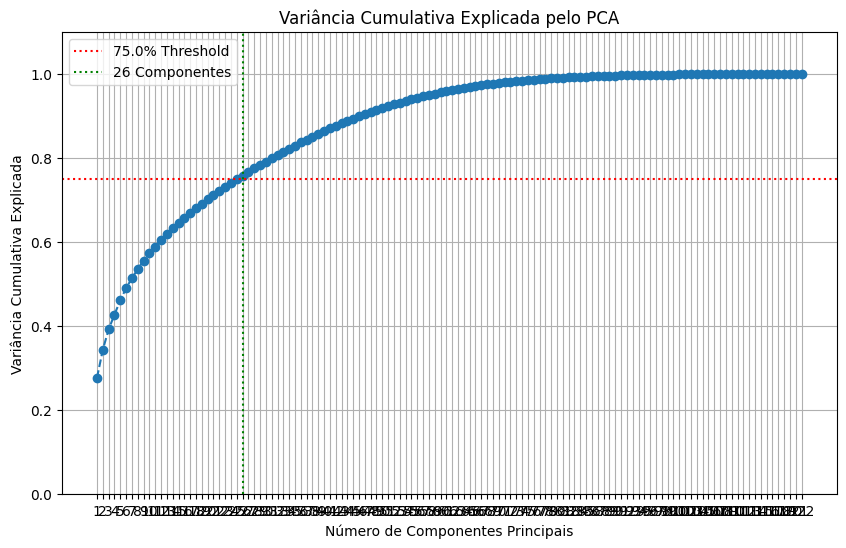

np.int64(26)

In [ ]:
def analyse_pca(pca_object, threshold=0.75):
    explained_variance_ratio = pca_object.explained_variance_ratio_
    n_total_components = len(explained_variance_ratio)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    if np.any(cumulative_variance >= threshold):
        n_components_needed = np.argmax(cumulative_variance >= threshold) + 1
        variance_explained_by_need = cumulative_variance[n_components_needed-1]
        print(f"Para explicar pelo menos {threshold * 100}% da variância, são necessários: {n_components_needed} components")
        print(f"(A variância explicada acumulada é de {variance_explained_by_need*100:.2f}%)")
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, n_total_components + 1), cumulative_variance, marker='o', linestyle='--')
        plt.title('Variância Cumulativa Explicada pelo PCA')
        plt.xlabel('Número de Componentes Principais')
        plt.ylabel('Variância Cumulativa Explicada')
        plt.axhline(y=threshold, color='r', linestyle=':', label=f'{threshold*100}% Threshold')
        plt.axvline(x=n_components_needed, color='g', linestyle=':', label=f'{n_components_needed} Componentes')
        plt.ylim(0, 1.1)
        plt.xticks(range(1, n_total_components + 1))
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()
    return n_components_needed
# Normalizar os dados
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)
trained_pca_object = implement_PCA(features_normalized)
analyse_pca(trained_pca_object)


#### Exercício 4.4.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

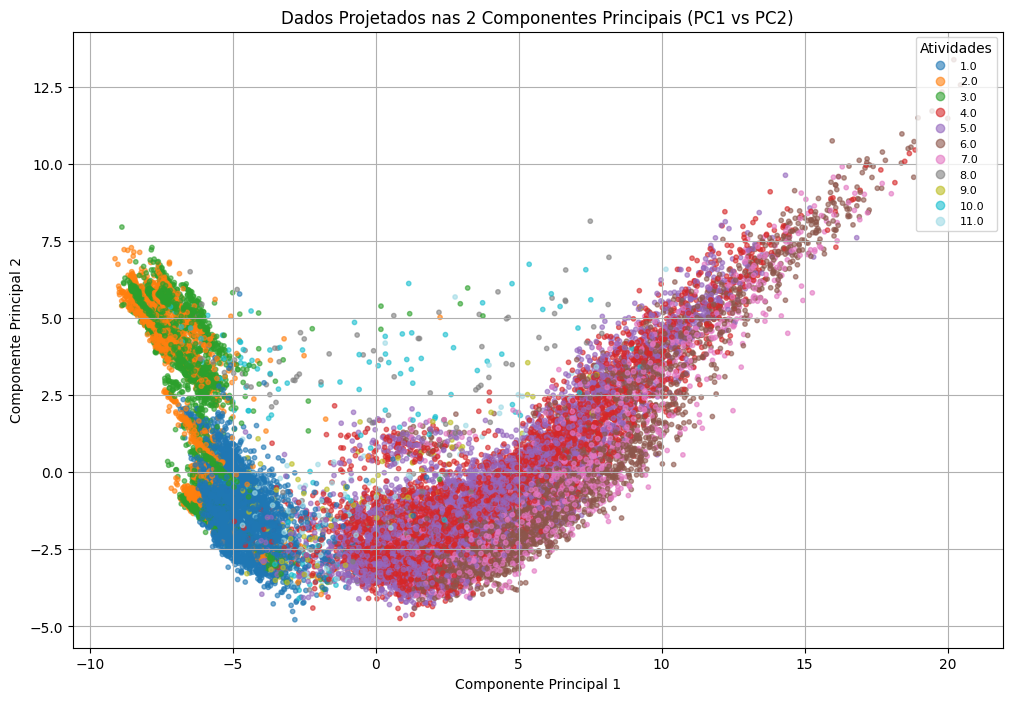

In [10]:
def plot_pca_2d_scatter(pca_object, normalized_feature_set, labels):
    # pca.transform() projeta os dados originais (N dimensões)
    # para o novo espaço de componentes (max_components dimensões)
    X_pca_transformed = pca_object.transform(normalized_feature_set)

    # Usar apenas as duas primeiras componentes para o gráfico 2D
    PC1 = X_pca_transformed[:, 0]
    PC2 = X_pca_transformed[:, 1]
    
    plt.figure(figsize=(12, 8))
    
    scatter = plt.scatter(PC1, PC2, c=labels, cmap='tab20', alpha=0.6, s=10)
    unique_labels_list = list(np.unique(labels))
    plt.title('Dados Projetados nas 2 Componentes Principais (PC1 vs PC2)')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend(handles=scatter.legend_elements()[0], labels=unique_labels_list, 
               title="Atividades", loc="upper right", fontsize=8)
    
    plt.grid(True)
    plt.show()
plot_pca_2d_scatter(trained_pca_object, features_normalized, labels)

#### Exercicio 4.4.2.
Indique as vantagens e as limitações desta abordagem.

#### Vantagens
1. Combate a Maldição da Dimensionalidade:
- O nosso feature set original tinha 126 dimensões. Trabalhar com um número tão elevado de features é computacionalmente "caro" e aumenta muito o risco de overfitting. A nossa análise no 4.4 mostrou que podemos reduzir o dataset em mais de 80% (de 126 para 26 componentes) e ainda assim reter 75% da variância (informação) total. Isto torna o treino de futuros modelos de classificação muito mais rápido.
2. Visualização de Dados Complexos:
- É impossível para um humano visualizar 126 dimensões. O PCA permite-nos "comprimir" os dados para 2D ou 3D para podermos ver a sua estrutura. O nosso gráfico 2D (PC1 vs PC2) é a prova desta vantagem. Ele revelou imediatamente uma estrutura nos dados:
    - As atividades (1-Stand, 2-Sit, 3-Sit and Talk) formam um cluster denso e separado à esquerda.
    - As atividades dinâmicas e transicionais (4-11) formam um cluster maior e mais disperso à direita.
Esta separação visual confirma que as features que o PCA comprimiu são, de facto, úteis para distinguir tipos de movimento.
3. Remoção de Redundância (Multicolinearidade):
- O feature set de 126 colunas é, garantidamente, redundante (ex: média_acc_x e rms_acc_x medem coisas parecidas e estão correlacionadas). O PCA cria novas componentes que são, por definição, ortogonais (não-correlacionadas) entre si.
#### Limitações
1. Perda de Interpretabilidade:
- Esta é a principal desvantagem do PCA e é mencionada nos slides como "Very low interpretability" e "abstract". As nossas 126 features originais tinham um significado físico claro (ex: "média do acelerómetro X"). As nossas 25 novas features são abstrações matemáticas. A "Componente Principal 1" (o eixo X do teu gráfico) é uma mistura ponderada de todas as 126 features originais. Perdemos a capacidade de dizer algo como "a rotação no eixo Z foi a feature mais importante".
2. PCA é Não-Supervisionado:
- O PCA encontra os eixos de máxima variância (o maior spread dos dados), ignorando completamente os labels (as atividades que queremos prever). A direção de maior variância nem sempre é a melhor direção para separar as classes. O gráfico mostra isto. O PCA encontrou que a maior variância (PC1) era a diferença entre "parado" e "a mexer", separando os dados em dois super-grupos. No entanto, ele falhou em separar as atividades dinâmicas (4-11), que continuam todas sobrepostas numa grande nuvem.
3. Assume Relações Lineares:
- O PCA é uma técnica linear. Ele tenta encontrar os melhores eixos para descrever os dados. O gráfico mostra que a estrutura dos dados forma uma curva. Isto é uma estrutura não-linear.
4. Sensibilidade à Escala:
- O PCA é muito sensível à escala das features (uma feature de 0-1000 dominaria uma de 0-1).Esta é uma limitação que evitámos. O enunciado (4.4) exige a normalização Z-Score antes de aplicar o PCA, o que garante que todas as 126 features "começam" com a mesma escala e importância.

### Exercício 4.5 e 4.6
Desenvolva o código necessário para implementar o Fisher feature Score e o ReliefF. Poderá usar implementações existentes.

In [ ]:
def calcular_reliefF(features, labels, n_neighbors):
    relief = ReliefF(n_neighbors=n_neighbors, n_features_to_select=None)
    relief.fit(features, labels)
    scores = relief.feature_importances_
    importancias_ordenadas = np.argsort(scores)[::-1]  
    top10_indices = importancias_ordenadas[:10]                    
    return top10_indices

def calcular_fisher_score(features, labels):
    scores = fisher_score.fisher_score(features, labels)
    indices_ordenados = np.argsort(scores)[::-1]   
    top10_indices = indices_ordenados[:10]                
    return top10_indices

refliF_resul = calcular_reliefF(features_normalized, labels, 5)
fisher_score_resul = calcular_fisher_score(features_normalized, labels)

print(refliF_resul)
print('......................')
print(fisher_score_resul)

[ 70 104 102 100 101  66  67  39 103  68]
......................
[ 95 105  39  64  65 117  90 106  13  49]


In [32]:
print("ReliefF top 10:", [nomes_features[i] for i in refliF_resul])
print("Fisher top 10:", [nomes_features[i] for i in fisher_score_resul])


ReliefF top 10: ['mx_rms', 'Corr_Gyr_YZ', 'Corr_Gyr_XY', 'Corr_Acc_XZ', 'Corr_Acc_YZ', 'mx_mean', 'mx_median', 'gx_skewness', 'Corr_Gyr_XZ', 'mx_std']
Fisher top 10: ['mz_kurtosis', 'Corr_Mag_XY', 'gx_skewness', 'gz_zcr', 'gz_mcr', 'gx_SpecEntropy', 'mz_std', 'Corr_Mag_XZ', 'ay_std', 'gy_mean_derivative']


#### Comparação dos métodos Fisher Score e ReliefF
Após a extração do feature set de 126 dimensões, foram aplicados dois métodos de seleção de features para identificar as 10 características mais relevantes: Fisher Scrore e RelieF (com k = 5 vizinhos).

10 melhores features de acordo com o Fisher Score e o ReliefF 

**ReliefF top 10**: ['mx_rms', 'Corr_Gyr_YZ', 'Corr_Gyr_XY', 'Corr_Acc_XZ', 'Corr_Acc_YZ', 'mx_mean', 'mx_median', 'gx_skewness', 'Corr_Gyr_XZ', 'mx_std']

**Fisher top 10**: ['mz_kurtosis', 'Corr_Mag_XY', 'gx_skewness', 'gz_zcr', 'gz_mcr', 'gx_SpecEntropy', 'mz_std', 'Corr_Mag_XZ', 'ay_std', 'gy_mean_derivative']

##### Análise da comparação:
1. Listas quase totalmente distintas: A observação mais óbvia é que as duas listas são quase totalmente distintas, partilhando apenas uma única feature em comum: `gx_skewness`.
Esta diferência é uma consequência direta da diferente natureza dos dois algoritmos:
- O Fisher Score é um método de filtro univariado. Ele avalia cada feature isoladamente, calculando uma pontuação em quão bem essa única feature consegue separar as médias das classes em relação à sua variância interna. Ele não considera interações entre features.
  
- O ReliefF, por outro lado, é um método multivariado sensível ao contexto. Para cada amostra ele analisa os seus k vizinhos mais próximos da mesma classe (nearHits) e k vizinhos de classes diferentes. Ele dá uma pontuação alta às features que são semelhantes para os nearHits mas diferentes para os nearMisses. Isto significa que o ReliefF é muito bom a encontrar features que, em conjunto, são boas a separar amostras no espaço multidimensional (N dimensões).
  
2. Preferência de cada algoritmo: 
- O ReliefF mostrou uma preferência por features do Magnetómetro (eixo X) (4 das 10 melhores são mx_...) e por correlações entre eixos do Giroscópio (Corr_Gyr_...). Isto sugere que a orientação da mão (Magnetómetro) e a relação entre os eixos de rotação (Giroscópio) são extremamente eficazes para distinguir vizinhanças de atividades diferentes.
  
- O Fisher Score selecionou um conjunto de features muito mais diverso, abrangendo os três sensores (Acelerómetro, Giroscópio, Magnetómetro) e uma variedade de tipos de métricas (kurtosis, taxas de cruzamento, entropia espectral, etc.). Isto significa que, individualmente, estas 10 features são as que têm a melhor estatística de separação "média vs. variância"
  
2. A feature comum: `gx_skewness`: O facto de gx_skewness (índice 39) ser a única feature a aparecer em ambas as listas é um indicador muito forte. Significa que ela não é apenas uma boa feature individual (para o Fisher Score), mas também uma feature robusta quando se olha para o contexto dos vizinhos (para o ReliefF).

### Exercício 4.6.1.
Indique como poderia obter as features relativas a esta compressão e exemplifique para um instante à sua escolha.

#### Como obter as features relativas à compressão
O método utilizado, ao contrário do PCA que transforma 126 features em 25 novas features, é um método de seleção de features, ou seja, filtram as features originiais para ficar apenas com as mais relevantes.
O processo, implementado nas funções calcular_fisher_score e calcular_reliefF, é o seguinte:
1. Cálculo do Score: Cada um dos algoritmos é executado sobre o dataset completo e cada algoritmo atribui um score a cada uma das 126 features.
   
2. Seleção: As pontuações são ordenadas e os indices (as posições das colunas, 0 a 125) das 10 features com maior pontuação são selecionados.
   
3. Filtragem: Para "obter as features relativas a esta seleção", basta filtrar o dataset original, mantendo apenas as 10 colunas cujos índices foram selecionados.
#### Exemplo para um instante à escolha
Para exemplificar, vamos considerar o primeiro instante do nosso feature set e mostrar o antes (vetor original com 126 features) e o depois (vetor com apenas as 10 features selecionadas por cada método).

In [ ]:
instante_original = features_normalized[0]
print(f"ANTES (Feature Set Original Normalizado):")
print(f"  - Dimensionalidade: {len(instante_original)} features")
print(f"  - Primeiros 15 valores: {np.round(instante_original[:15], 3)}...")

instante_selecionado_fisher = instante_original[fisher_score_resul]

print(f"DEPOIS (Seleção com Fisher Score):")
print(f"  - Índices selecionados: {fisher_score_resul}")
print(f"  - Dimensionalidade: {len(instante_selecionado_fisher)} features")
print(f"  - Os 10 valores (das colunas acima): \n{np.round(instante_selecionado_fisher, 3)}")

instante_selecionado_relief = instante_original[refliF_resul]

print(f"DEPOIS (Seleção com ReliefF, k=5):")
print(f"  - Índices selecionados: {refliF_resul}")
print(f"  - Dimensionalidade: {len(instante_selecionado_relief)} features")
print(f"  - Os 10 valores (das colunas acima): \n{np.round(instante_selecionado_relief, 3)}")

#### Vantagens e limitações da abordagem de seleção de features
A abordagem utilizada é uma técnica de seleção de features, que é diferentes do PCA que é uma técnica de extração de features. Nela, algoritmos como o Fisher Score e o ReliefF são usados para calcular uma pontuação de relevância para cada uma das 126 features originais. Com base nesse ranking, selecionamos um subconjunto e descartamos o resto.
##### Vantagens:
1. **Preservação da Interpretabilidade**: Ao contrário do PCA, esta abordagem mantém as features originais. Por exemplo, se o Fisher Score selecionar a feature no índice 50 como a mais importante e essa feature for a média do giroscópio no eixo X, podemos concluir que a rotação média no eixo X é um indicador muito forte para prever a atividade. Esta interpretabilidade é completamente perdida no PCA.
   
2. **Eficiência Computacional**: Métodos de filtro como o Fisher Score são, geralmente, muito rápidos de calcular. Analisam as propriedades estatística das features (ex: variância, correlação) sem a necessidade de treinar modelos. O cálculo destes scores é mais leve do que a decomposição de matrizes usada pelo PCA para um dataset de 126 dimensões. além disso, o modelo final será mais rápido com 10 features do que com 25 componentes principais.
   
3. **Redução de Overfitting**: Tal como o PCA, esta abordagem combate a maldição da dimensionalidade ao reduzir o número de features (126 para 10). Um modelo com 10 features é mais simples, mais rápido e menos propenso a overfitting do que o modelo original com 126 features.
##### Limitações:
1. **Ignora Interações entre features**: A maior limitação dos métodos de filtro é que eles tendem a avaliar cada feature isoladamente. Uma feature A e uma feature B podem ser fracas individualmente (score baixo) e seriam descartadas. No entanto, a combinação delas (ex: A / B) podia ser o melhor classificador de todos. O PCA, ao combinar features para criar as componentes principais, é capaz de capturar estas interações. A seleção de features não é. 
O ReliefF é melhor nisto que o Fisher, pois olha para "vizinhos" e é multivariado, mas ainda é um filtro

2. **Independência do Modelo Final**: Os métodos de filtro selecionam as features antes de sabermos qual será o nosso algoritmo de classificação final. As "10 melhores features" segundo o Fisher Score (que se baseia em variâncias) podem não ser as "10 melhores features" para um classificador não-linear como uma Rede Neuronal. Esta é a principal desvantagem dos métodos "Filtro" em comparação com os métodos "Wrapper" (que testam as features com o próprio modelo).